# 3C Summary — One-shot QC + Plots

This notebook is designed to be **run top-to-bottom** and then shared.

It will:
1) explain the expected input format
2) load all `*_summary.csv` in the 3C folder
3) show quick tables + QC plots (counts + CIS/TRANS composition)
4) (optionally) save plots to `Outputs/3C`

## Data location
This notebook reads from `WILSONTEW_3C_FOLDER` if set; otherwise it falls back to `./ThreeC_Data`.
Current recommended 3C folder (from your setup):
- `C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary`

## Biological context for this assay

This notebook analyzes a dual-DSB yeast system designed to study **NHEJ-driven chromosomal rearrangement** and DSB proximity at sample pull, measured through ligation-dependent PCR products after fixation.

### Important interpretation note
In this workflow, CIS/TRANS readouts are based on **direct ligation products**. The PCR product is observed only when ligation has occurred, so each counted event reflects a ligated junction captured from the crosslinked sample at the pull timepoint.

Accordingly, a "trans" event indicates a ligated junction between distant loci/chromosomes after crosslinking and ligation at collection, while "cis" indicates ligation within the cognate/local context tracked by this assay.

### What the current results are showing
- Cis-like/cognate outcomes still dominate many groups, as expected for NHEJ.
- Non-cognate (TRANS) ligation frequencies are recurrent across many DSB-pair contexts and replicates.
- The relative stability of these non-cognate ligation frequencies across batch/locus contexts supports a model where post-damage nuclear behavior (movement/co-localization) can weaken strict dependence on pre-damage spatial proximity.

These patterns are consistent with the Aim 3 hypothesis that coordinated movement of simultaneous DSBs alters which loci are ligated together during repair-competent windows.

In [42]:
suppressPackageStartupMessages({
  library(tidyverse)
})


## Expected columns (typical)
Most 3C summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `repeat`, `replicate`, `count`

This notebook filters to time points 0 and 120 by default (matches the existing 3C QC report).

In [43]:
# ---- Locate 3C folder ----
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)
dir.create(threec_folder, recursive = TRUE, showWarnings = FALSE)
message('Using threec_folder: ', threec_folder)

files <- list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE)
if (length(files) == 0) {
  stop(paste0(
    'No *_summary.csv files found in threec_folder: ', threec_folder,
    '\n\nFix: set WILSONTEW_3C_FOLDER to the directory that contains your 3C summary CSVs.'
  ))
}
message('Found ', length(files), ' file(s).')
head(files, 10)

Using threec_folder: C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary

Found 8 file(s).



[1] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T0_final_summary.csv"  
[2] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_2_3C_T120_final_summary.csv"
[3] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T0_3C_summary.csv"          
[4] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch4_T120_3C_summary.csv"        
[5] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T0_3C_summary.csv"          
[6] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch6_T120_3C_summary.csv"        
[7] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T0_3C_summary.csv"          
[8] "C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/3C Sequencing Data/3C_summary/batch8_T120_3C_summary.csv"

In [44]:
# ---- Read and combine ----
# Some 3C summary CSVs include extra columns whose types vary across runs (e.g., *_loci).
# To keep binding robust, read everything as character, then parse only the columns we need.
read_one <- function(f) {
  dat <- readr::read_csv(
    f,
    show_col_types = FALSE,
    col_types = readr::cols(.default = readr::col_character())
  )
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  
  # Parse key columns if present
  if ("count" %in% names(dat)) dat$count <- readr::parse_double(dat$count)
  if ("time_point" %in% names(dat)) dat$time_point <- readr::parse_number(dat$time_point)
  if ("replicate" %in% names(dat)) dat$replicate <- as.character(dat$replicate)
  
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))

# Match the 3C report convention: only 0 and 120 (edit if needed)
dat_raw <- dat_raw %>% filter(time_point %in% c(0, 120))

dplyr::glimpse(dat_raw)

Rows: 596
Columns: 13
$ batch          <fct> 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4…
$ DSB2_loci      <chr> "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", "7", …
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", "2", …
$ alignment_name <chr> "CIS_A_to_B_DSB1_Chr12_L01", "CIS_A_to_B_DSB1_Chr12_L05…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ allele         <chr> "Chr12_L01", "Chr12_L05", "Chr12_L07", "Chr12_L12", "Ch…
$ count          <dbl> 17041, 37724, 14131, 17156, 24218, 72, 17820, 20767, 26…
$ `repeat`       <chr> "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL", "ALL",…
$ source_path    <chr> "C:/Users/dunnmk/University of Michigan Dropbox/MED-WIL…
$ source_dir     <

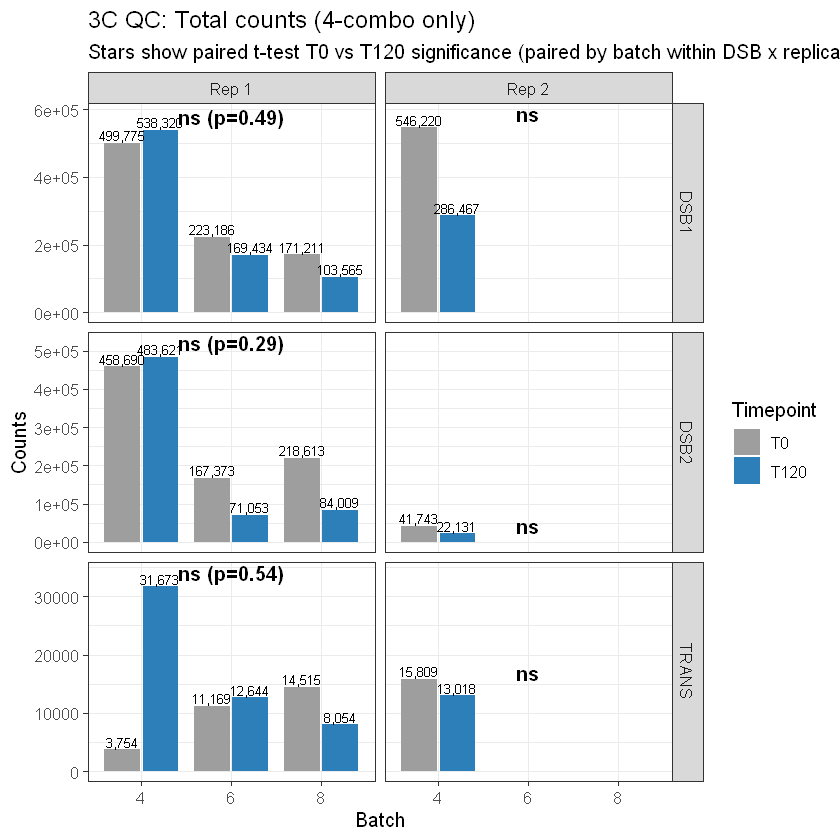

In [65]:
# ---- QC plots ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

# Keep timepoint display consistent across the report (T0/T120)
as_time_label <- function(tp) {
  tp_num <- suppressWarnings(as.numeric(as.character(tp)))
  out <- dplyr::case_when(
    tp_num == 0 ~ 'T0',
    tp_num == 120 ~ 'T120',
    TRUE ~ as.character(tp)
  )
  factor(out, levels = c('T0', 'T120'))
}
TIME_COLORS <- c(T0 = '#9E9E9E', T120 = '#2C7FB8')

sig_stars_qc <- function(p) {
  dplyr::case_when(
    is.na(p) ~ 'ns',
    p < 0.001 ~ '***',
    p < 0.01 ~ '**',
    p < 0.05 ~ '*',
    TRUE ~ 'ns'
  )
}

dat4 <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  mutate(
    replicate = if_else(is.na(replicate) | replicate == '', 'ALL', as.character(replicate)),
    replicate = if_else(str_starts(replicate, 'Rep '), replicate, paste0('Rep ', replicate))
  )

qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB, replicate) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  mutate(label_counts = scales::label_number(accuracy = 1, big.mark = ',')(Total_Counts))

# Paired T0 vs T120 t-test by DSB x replicate (paired on batch)
qc_ttest <- qc_totals %>%
  filter(time_point %in% c(0, 120), is.finite(Total_Counts)) %>%
  mutate(time_point = as.integer(time_point)) %>%
  select(batch, DSB, replicate, time_point, Total_Counts) %>%
  tidyr::pivot_wider(names_from = time_point, values_from = Total_Counts, names_prefix = 't') %>%
  mutate(
    t0 = if ('t0' %in% names(.)) t0 else NA_real_,
    t120 = if ('t120' %in% names(.)) t120 else NA_real_
  ) %>%
  filter(is.finite(t0), is.finite(t120)) %>%
  group_by(DSB, replicate) %>%
  group_modify(~ {
    d <- .x
    n_pairs <- nrow(d)
    p_val <- NA_real_
    if (n_pairs >= 2) {
      tt <- tryCatch(stats::t.test(d$t120, d$t0, paired = TRUE), error = function(e) NULL)
      if (!is.null(tt)) p_val <- as.numeric(tt$p.value)
    }
    tibble::tibble(
      n_pairs = n_pairs,
      p_value = p_val,
      significance = sig_stars_qc(p_val)
    )
  }) %>%
  ungroup()

qc_ymax <- qc_totals %>%
  group_by(DSB, replicate) %>%
  summarise(y_pos = max(Total_Counts, na.rm = TRUE) * 1.08, .groups = 'drop')

batch_levels <- unique(as.character(qc_totals$batch))
batch_mid <- batch_levels[ceiling(length(batch_levels) / 2)]

qc_ttest_annot <- qc_ttest %>%
  left_join(qc_ymax, by = c('DSB', 'replicate')) %>%
  mutate(
    batch = batch_mid,
    label = case_when(
      significance != 'ns' ~ significance,
      is.na(p_value) ~ 'ns',
      TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
    )
  )

p_total <- ggplot(qc_totals, aes(x = batch, y = Total_Counts, fill = as_time_label(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  geom_text(
    aes(label = label_counts),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 2.8
  ) +
  geom_text(
    data = qc_ttest_annot,
    aes(x = batch, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 4.2,
    fontface = 'bold'
  ) +
  facet_grid(DSB ~ replicate, scales = 'free_y') +
  scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
  theme_bw(base_size = 12) +
  labs(
    title = '3C QC: Total counts (4-combo only)',
    subtitle = 'Stars show paired t-test T0 vs T120 significance (paired by batch within DSB x replicate)',
    x = 'Batch',
    y = 'Counts',
    fill = 'Timepoint'
  )
print(p_total)

# Line QC plot removed per request (it was not informative).
# Keep object defined so downstream export logic remains safe.
p_cistrans <- NULL

**Figure 3. QC total counts (4-combo subset) across DSB class and replicate.**

- **Methods/Computation:** Raw counts were restricted to `A_to_B`, `C_to_D`, `A_to_D`, and `C_to_B`, then summarized by batch, time point, DSB class, and replicate. The plotted quantity is $N_{b,t,d,r}=\sum_i c_i$ for each batch $b$, time $t$, DSB class $d$, and replicate $r$.
- **Biological relevance (with sources):** These totals define effective sampling depth per stratum and therefore the confidence of downstream composition/fold-change estimates; uneven depth can inflate variance in inferred DSB partner-choice behavior in NHEJ-focused analyses [1,3].

In [55]:
# ---- Optional: save plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(filename = file.path(out_dir, '3C_QC_total_counts.png'), plot = p_total, width = 14, height = 7, dpi = 200)
if (!is.null(p_cistrans)) {
  ggsave(filename = file.path(out_dir, '3C_QC_cis_trans_percent.png'), plot = p_cistrans, width = 14, height = 8, dpi = 200)
}
message('Saved plots to: ', out_dir)

Saved plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



## Advanced analyses (Sections 4–9 from aggregate workflow)

The blocks below add:

- Group-level CIS/TRANS composition summaries
- Allele frequency and Pearson correlation (T0 vs T120)
- Fold-change and log2 fold-change metrics
- Correlations of log2FC vs allele frequency
- Per-allele contribution plots (CIS/TRANS + combo breakdown)
- Export of advanced plots and diagnostics

## Methods used in this notebook and their biological interpretation

### 1) Pooled ligation-junction quantification across time
- **Method**: Aggregate ligation-supported counts at baseline ($t0$) and post-induction/recovery ($t120$).
- **Interpretation in this biology**: Quantifies how frequently specific DSB loci are ligated together in crosslinked samples.

### 2) Replicate-aware stratification
- **Method**: Analyze by batch, DSB class, time point, and replicate (`Rep 1`, `Rep 2`).
- **Interpretation**: Tests whether ligation patterns are reproducible rather than run-specific.

### 3) Group-level cognate vs non-cognate composition
- **Method**: Compute cognate/non-cognate totals and composition shares.
- **Interpretation**: Measures partner-preference structure in observed ligation outcomes (CIS vs TRANS).

### 4) Allele-frequency correlation ($t0$ vs $t120$)
- **Method**: Pearson correlation of ligation-junction frequencies before/after induction (linear and log-log).
- **Interpretation**: Tests whether the same loci remain dominant or whether ligation structure is reweighted after DSB induction.

### 5) Fold-change and log2FC metrics
- **Method**: Compute $\frac{t120}{t0}$ and log2FC per allele for cognate/non-cognate channels.
- **Interpretation**: Identifies loci with disproportionate post-damage gain/loss in ligation-supported junction counts.

### 6) Correlation of log2FC with allele frequency
- **Method**: Correlate abundance with log2FC behavior.
- **Interpretation**: Distinguishes abundance effects from structured partner-selection behavior in ligation outcomes.

### 7) PCA with clustering of allele signatures
- **Method**: PCA of t120 allele signatures, with explicit cluster assignment in PC space.
- **Interpretation**: Tests whether locus-level ligation profiles organize into reproducible groups rather than a single continuum.

### 8) Clustered heatmap with TAD-like domain detection
- **Method**: Build allele correlation matrix from normalized ligation frequencies, hierarchically reorder loci, then detect contiguous domain-like modules (TAD-like blocks) from clustered structure.
- **Interpretation**: Identifies groups of loci that show similar ligation behavior, consistent with shared nuclear interaction neighborhoods.

### What the results in this notebook indicate
- The data support robust, repeatable non-cognate ligation behavior across many DSB-pair contexts.
- PCA and clustered heatmap/domain analyses test whether these patterns are random collisions or structured modules of DSB co-ligation behavior.
- Together, these outputs are designed to evaluate whether post-damage coordinated movement explains why pre-damage proximity is not the only determinant of observed ligation outcomes.

## Plotting/statistical conventions aligned to 3C/Hi-C literature

The figure styles and tests in this notebook follow practical conventions from foundational 3C/Hi-C studies and follow-up high-resolution analyses.

- **Two-timepoint bars in one panel (T0 vs T120), color-coded and labeled:** paired display improves comparability of condition shifts while preserving batch/replicate stratification.
- **Within-stratum paired testing for T0→T120:** where the same unit is observed at both times (batch, allele, or other matched unit), paired tests are preferred over unpaired tests.
- **Correlation panels report effect size, not only trend:** each scatter includes $R^2$ (and/or $r$), which is the variance-explained summary of linear concordance.
- **Bar labels and readable y-ranges:** values are printed on bars and y-limits are set close to the largest observed bar (with headroom for labels/significance) to avoid compression of differences.
- **Structure-aware interpretation:** heatmap/correlation summaries are interpreted in the context of contact domains, loop enrichment, and local-background-aware signal definitions.

### Why these choices are biologically appropriate for 3C-like data

1. **3C/Hi-C measures ligation-supported proximity frequencies** after crosslinking/ligation, so comparing matched conditions and replicates is central to interpretation (Dekker et al., 2002; Lieberman-Aiden et al., 2009).
2. **Normalization and reproducibility are critical** because contact frequencies are affected by coverage and technical bias; matrix-balancing and replicate concordance are standard quality practices (Rao et al., 2014; Dixon et al., 2012).
3. **Local-background context matters for interaction signal** (especially for loop-like enrichments), so visual/statistical interpretation should avoid over-calling global-average artifacts (Rao et al., 2014).
4. **Stable versus shifted interaction hierarchy** is naturally captured by paired tests, fold-change summaries, and correlation effect sizes across timepoints (Jin et al., 2013; Rao et al., 2014).

### References used for these conventions

- Dekker J, Rippe K, Dekker M, Kleckner N. *Capturing Chromosome Conformation.* Science (2002). DOI: 10.1126/science.1067799
- Lieberman-Aiden E, et al. *Comprehensive mapping of long-range interactions reveals folding principles of the human genome.* Science (2009). DOI: 10.1126/science.1181369
- Dixon JR, et al. *Topological domains in mammalian genomes identified by analysis of chromatin interactions.* Nature (2012). DOI: 10.1038/nature11082
- Jin F, et al. *A high-resolution map of the three-dimensional chromatin interactome in human cells.* Nature (2013). DOI: 10.1038/nature12644
- Rao SSP, et al. *A 3D map of the human genome at kilobase resolution reveals principles of chromatin looping.* Cell (2014). DOI: 10.1016/j.cell.2014.11.021

In [46]:
# ---- Helpers + guardrails ----
combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

required_cols <- c('batch', 'time_point', 'DSB', 'allele', 'combo', 'cis_trans', 'count', 'replicate')
missing_cols <- setdiff(required_cols, names(dat_raw))
if (length(missing_cols) > 0) {
  stop(paste0('Missing required columns: ', paste(missing_cols, collapse = ', ')))
}

fc_ratio <- function(num, den, eps = 1e-6) {
  ifelse(
    is.na(num) | is.na(den),
    NA_real_,
    ifelse(num == 0 & den == 0, NA_real_, (num + eps) / (den + eps))
  )
}

has_ggrepel <- requireNamespace('ggrepel', quietly = TRUE)

dat_focus <- dat_raw %>%
  filter(combo %in% combos_4) %>%
  mutate(
    time_point = as.numeric(as.character(time_point)),
    batch = as.character(batch),
    replicate = if_else(is.na(replicate) | replicate == '', 'ALL', as.character(replicate)),
    # Normalize replicate labels so '1' and 'Rep 1' collapse to the same level
    replicate = if_else(
    	replicate == 'ALL',
    	'REP_ALL_PLACEHOLDER',
    	if_else(str_starts(replicate, 'Rep '), replicate, paste0('Rep ', replicate))
    ),
    replicate = if_else(replicate == 'REP_ALL_PLACEHOLDER', 'Rep ALL', replicate),
    DSB = as.character(DSB),
    allele = as.character(allele),
    combo = as.character(combo)
  )

if (nrow(dat_focus) == 0) {
  stop('No rows remain after filtering to 4-combo set (A_to_B, C_to_D, A_to_D, C_to_B).')
}

message('Rows in dat_focus: ', nrow(dat_focus))
message('Distinct alleles: ', dplyr::n_distinct(dat_focus$allele))
message('Distinct batches: ', dplyr::n_distinct(dat_focus$batch))
message('Distinct replicates: ', paste(sort(unique(dat_focus$replicate)), collapse = ', '))

Rows in dat_focus: 596

Distinct alleles: 29

Distinct batches: 3

Distinct replicates: Rep 1, Rep 2



In [47]:
# ---- Section 4: group-level allele frequency summaries + composition plots + T0 vs T120 t-tests ----
my_summarize_cistrans_by_combo <- function(dat, cis_combos, trans_combos, count_col = 'count') {
  by_allele <- dat %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(
      Cis_Location_Counts = sum(.data[[count_col]][combo %in% cis_combos], na.rm = TRUE),
      Trans_Location_Counts = sum(.data[[count_col]][combo %in% trans_combos], na.rm = TRUE),
      .groups = 'drop'
    )

  totals <- by_allele %>%
    group_by(batch, replicate, time_point, DSB) %>%
    summarise(
      Total_Cis_Location_Counts = sum(Cis_Location_Counts, na.rm = TRUE),
      Total_Trans_Location_Counts = sum(Trans_Location_Counts, na.rm = TRUE),
      .groups = 'drop'
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'replicate', 'time_point', 'DSB')) %>%
    mutate(
      Total_Group_Counts = Total_Cis_Location_Counts + Total_Trans_Location_Counts,
      Percent_Cis_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Cis_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Trans_of_GroupTotal = if_else(Total_Group_Counts > 0, 100 * Trans_Location_Counts / Total_Group_Counts, NA_real_),
      Percent_Location_in_Cis = if_else(Total_Cis_Location_Counts > 0, 100 * Cis_Location_Counts / Total_Cis_Location_Counts, NA_real_),
      Percent_Location_in_Trans = if_else(Total_Trans_Location_Counts > 0, 100 * Trans_Location_Counts / Total_Trans_Location_Counts, NA_real_)
    )
}

dat_norm_combo <- my_summarize_cistrans_by_combo(dat_focus, cis_combos, trans_combos, count_col = 'count')

dat_group4 <- dat_focus %>%
  group_by(batch, replicate, time_point) %>%
  summarise(
    A_to_B = sum(count[combo == 'A_to_B'], na.rm = TRUE),
    C_to_D = sum(count[combo == 'C_to_D'], na.rm = TRUE),
    A_to_D = sum(count[combo == 'A_to_D'], na.rm = TRUE),
    C_to_B = sum(count[combo == 'C_to_B'], na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    Cis_Total = A_to_B + C_to_D,
    Trans_Total = A_to_D + C_to_B,
    Total = Cis_Total + Trans_Total,
    Percent_Cis_of_Total = if_else(Total > 0, 100 * Cis_Total / Total, NA_real_),
    Percent_Trans_of_Total = if_else(Total > 0, 100 * Trans_Total / Total, NA_real_),
    Percent_A_to_B_in_Cis = if_else(Cis_Total > 0, 100 * A_to_B / Cis_Total, NA_real_),
    Percent_C_to_D_in_Cis = if_else(Cis_Total > 0, 100 * C_to_D / Cis_Total, NA_real_),
    Percent_A_to_D_in_Trans = if_else(Trans_Total > 0, 100 * A_to_D / Trans_Total, NA_real_),
    Percent_C_to_B_in_Trans = if_else(Trans_Total > 0, 100 * C_to_B / Trans_Total, NA_real_)
  )

dat_group4_share <- dat_group4 %>%
  group_by(replicate, time_point) %>%
  mutate(
    Total_Cis_AllBatches = sum(Cis_Total, na.rm = TRUE),
    Total_Trans_AllBatches = sum(Trans_Total, na.rm = TRUE),
    Percent_Cis_Share = if_else(Total_Cis_AllBatches > 0, 100 * Cis_Total / Total_Cis_AllBatches, NA_real_),
    Percent_Trans_Share = if_else(Total_Trans_AllBatches > 0, 100 * Trans_Total / Total_Trans_AllBatches, NA_real_)
  ) %>%
  ungroup()

# Build within-channel composition tables used by Figure 4C/4D
cis_comp_long4 <- dat_group4 %>%
  select(batch, replicate, time_point, Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis) %>%
  pivot_longer(
    cols = c(Percent_A_to_B_in_Cis, Percent_C_to_D_in_Cis),
    names_to = 'Combo',
    values_to = 'Percent'
  ) %>%
  mutate(
    Combo = recode(Combo, Percent_A_to_B_in_Cis = 'A_to_B', Percent_C_to_D_in_Cis = 'C_to_D')
  )

trans_comp_long4 <- dat_group4 %>%
  select(batch, replicate, time_point, Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans) %>%
  pivot_longer(
    cols = c(Percent_A_to_D_in_Trans, Percent_C_to_B_in_Trans),
    names_to = 'Combo',
    values_to = 'Percent'
  ) %>%
  mutate(
    Combo = recode(Combo, Percent_A_to_D_in_Trans = 'A_to_D', Percent_C_to_B_in_Trans = 'C_to_B')
  )

# Common timepoint styling for two-timepoint bar charts
as_time_label <- function(tp) factor(tp, levels = c(0, 120), labels = c('T0', 'T120'))
TIME_COLORS <- c('T0' = '#bdbdbd', 'T120' = '#3182bd')

sig_stars <- function(p) {
  dplyr::case_when(
    is.na(p) ~ 'ns',
    p < 0.001 ~ '***',
    p < 0.01 ~ '**',
    p < 0.05 ~ '*',
    TRUE ~ 'ns'
  )
}

# Make the paired T0/T120 test robust to strata that are missing a timepoint
ensure_time_cols <- function(df_wide) {
  if (!('0' %in% names(df_wide)) && ('T0' %in% names(df_wide))) df_wide[['0']] <- df_wide[['T0']]
  if (!('120' %in% names(df_wide)) && ('T120' %in% names(df_wide))) df_wide[['120']] <- df_wide[['T120']]
  if (!('0' %in% names(df_wide))) df_wide[['0']] <- NA_real_
  if (!('120' %in% names(df_wide))) df_wide[['120']] <- NA_real_
  df_wide
}

run_paired_ttest_t0_t120 <- function(df, value_col) {
  df_wide <- df %>%
    select(batch, replicate, time_point, value = all_of(value_col)) %>%
    filter(time_point %in% c(0, 120), is.finite(value)) %>%
    mutate(time_point = as.integer(time_point)) %>%
    pivot_wider(names_from = time_point, values_from = value)

  df_wide <- ensure_time_cols(df_wide) %>%
    filter(is.finite(`0`), is.finite(`120`))

  if (nrow(df_wide) == 0) {
    return(tibble::tibble(
      replicate = character(),
      n_pairs = integer(),
      mean_t0 = numeric(),
      mean_t120 = numeric(),
      mean_diff_t120_minus_t0 = numeric(),
      p_value = numeric(),
      significance = character()
    ))
  }

  out <- df_wide %>%
    group_by(replicate) %>%
    group_modify(~ {
      d <- .x
      n_pairs <- nrow(d)
      p_val <- NA_real_

      if (n_pairs >= 2) {
        tt <- tryCatch(
          t.test(d$`120`, d$`0`, paired = TRUE),
          error = function(e) NULL
        )
        if (!is.null(tt)) p_val <- as.numeric(tt$p.value)
      }

      tibble::tibble(
        n_pairs = n_pairs,
        mean_t0 = mean(d$`0`, na.rm = TRUE),
        mean_t120 = mean(d$`120`, na.rm = TRUE),
        mean_diff_t120_minus_t0 = mean(d$`120` - d$`0`, na.rm = TRUE),
        p_value = p_val
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))

  out
}

run_paired_ttest_t0_t120_grouped <- function(df, group_cols, value_col) {
  df_wide <- df %>%
    select(all_of(group_cols), batch, time_point, value = all_of(value_col)) %>%
    filter(time_point %in% c(0, 120), is.finite(value)) %>%
    mutate(time_point = as.integer(time_point)) %>%
    pivot_wider(names_from = time_point, values_from = value)

  df_wide <- ensure_time_cols(df_wide) %>%
    filter(is.finite(`0`), is.finite(`120`))

  if (nrow(df_wide) == 0) {
    return(tibble::tibble())
  }

  df_wide %>%
    group_by(across(all_of(group_cols))) %>%
    group_modify(~ {
      d <- .x
      n_pairs <- nrow(d)
      p_val <- NA_real_

      if (n_pairs >= 2) {
        tt <- tryCatch(
          t.test(d$`120`, d$`0`, paired = TRUE),
          error = function(e) NULL
        )
        if (!is.null(tt)) p_val <- as.numeric(tt$p.value)
      }

      tibble::tibble(
        n_pairs = n_pairs,
        mean_t0 = mean(d$`0`, na.rm = TRUE),
        mean_t120 = mean(d$`120`, na.rm = TRUE),
        mean_diff_t120_minus_t0 = mean(d$`120` - d$`0`, na.rm = TRUE),
        p_value = p_val
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))
}

ttest_trans_t0_t120 <- run_paired_ttest_t0_t120(dat_group4_share, 'Percent_Trans_Share')
ttest_cis_t0_t120 <- run_paired_ttest_t0_t120(dat_group4_share, 'Percent_Cis_Share')

ttest_cis_comp_t0_t120 <- run_paired_ttest_t0_t120_grouped(cis_comp_long4, c('replicate', 'Combo'), 'Percent')
ttest_trans_comp_t0_t120 <- run_paired_ttest_t0_t120_grouped(trans_comp_long4, c('replicate', 'Combo'), 'Percent')

batch_levels <- unique(as.character(dat_group4_share$batch))
batch_mid <- batch_levels[ceiling(length(batch_levels) / 2)]

max_trans <- suppressWarnings(max(dat_group4_share$Percent_Trans_Share, na.rm = TRUE))
max_cis <- suppressWarnings(max(dat_group4_share$Percent_Cis_Share, na.rm = TRUE))
ymax_trans <- if (is.finite(max_trans)) pmin(110, max_trans + max(4, 0.06 * max_trans) + 2) else 110
ymax_cis <- if (is.finite(max_cis)) pmin(110, max_cis + max(4, 0.06 * max_cis) + 2) else 110

trans_ymax <- dat_group4_share %>%
  group_by(replicate) %>%
  summarise(y_pos = pmin(ymax_trans - 1, max(Percent_Trans_Share, na.rm = TRUE) + 6), .groups = 'drop')

cis_ymax <- dat_group4_share %>%
  group_by(replicate) %>%
  summarise(y_pos = pmin(ymax_cis - 1, max(Percent_Cis_Share, na.rm = TRUE) + 6), .groups = 'drop')

ttest_trans_annot <- ttest_trans_t0_t120 %>%
  left_join(trans_ymax, by = 'replicate') %>%
  mutate(label = case_when(
    significance != 'ns' ~ significance,
    is.na(p_value) ~ 'ns',
    TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
  )) %>%
  mutate(batch = batch_mid)

ttest_cis_annot <- ttest_cis_t0_t120 %>%
  left_join(cis_ymax, by = 'replicate') %>%
  mutate(label = case_when(
    significance != 'ns' ~ significance,
    is.na(p_value) ~ 'ns',
    TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
  )) %>%
  mutate(batch = batch_mid)

p_group4_trans_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Trans_Share, fill = as_time_label(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.75) +
  geom_text(
    aes(label = if_else(is.na(Percent_Trans_Share), NA_character_, paste0(round(Percent_Trans_Share, 1), '%'))),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 3.0
  ) +
  geom_text(
    data = ttest_trans_annot,
    aes(x = batch, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 5,
    fontface = 'bold'
  ) +
  facet_grid(replicate ~ .) +
  scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
  coord_cartesian(ylim = c(0, ymax_trans)) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Share of total TRANS counts by batch and replicate (A_to_D + C_to_B)',
    subtitle = 'Stars show paired t-test T0 vs T120 significance (within replicate; paired by batch)',
    x = 'Batch',
    y = '% of total TRANS',
    fill = 'Time'
  )

p_group4_cis_total <- ggplot(dat_group4_share, aes(x = batch, y = Percent_Cis_Share, fill = as_time_label(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.75) +
  geom_text(
    aes(label = if_else(is.na(Percent_Cis_Share), NA_character_, paste0(round(Percent_Cis_Share, 1), '%'))),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 3.0
  ) +
  geom_text(
    data = ttest_cis_annot,
    aes(x = batch, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 5,
    fontface = 'bold'
  ) +
  facet_grid(replicate ~ .) +
  scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
  coord_cartesian(ylim = c(0, ymax_cis)) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Share of total CIS counts by batch and replicate (A_to_B + C_to_D)',
    subtitle = 'Stars show paired t-test T0 vs T120 significance (within replicate; paired by batch)',
    x = 'Batch',
    y = '% of total CIS',
    fill = 'Time'
  )

# Composition plots: show timepoint as color and component as facet (avoids double-encoding fill)
p_cis_comp_2only <- ggplot(cis_comp_long4, aes(x = batch, y = Percent, fill = as_time_label(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.75) +
  geom_text(
    aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 2.6
  ) +
  facet_grid(replicate ~ Combo) +
  scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
  scale_y_continuous(limits = c(0, 100), expand = expansion(mult = c(0, 0.08))) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Within-CIS composition by batch and replicate (A_to_B + C_to_D = 100%)',
    x = 'Batch',
    y = '% of CIS',
    fill = 'Time'
  )

p_trans_comp_2only <- ggplot(trans_comp_long4, aes(x = batch, y = Percent, fill = as_time_label(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.75) +
  geom_text(
    aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))),
    position = position_dodge(width = 0.85),
    vjust = -0.25,
    size = 2.6
  ) +
  facet_grid(replicate ~ Combo) +
  scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
  scale_y_continuous(limits = c(0, 100), expand = expansion(mult = c(0, 0.08))) +
  theme_bw(base_size = 12) +
  labs(
    title = 'Within-TRANS composition by batch and replicate (A_to_D + C_to_B = 100%)',
    x = 'Batch',
    y = '% of TRANS',
    fill = 'Time'
  )

message('Section 4 plot objects + t-tests prepared.')
message('TRANS t-test table (T0 vs T120):')
print(ttest_trans_t0_t120)
message('CIS t-test table (T0 vs T120):')
print(ttest_cis_t0_t120)
message('Within-CIS composition t-tests (T0 vs T120):')
print(ttest_cis_comp_t0_t120)
message('Within-TRANS composition t-tests (T0 vs T120):')
print(ttest_trans_comp_t0_t120)


Section 4 plot objects + t-tests prepared.

TRANS t-test table (T0 vs T120):



# A tibble: 2 × 7
  replicate n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>       <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1           3    33.3      33.3                       0       1
2 Rep 2           1   100       100                         0      NA
# ℹ 1 more variable: significance <chr>


CIS t-test table (T0 vs T120):



# A tibble: 2 × 7
  replicate n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>       <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1           3    33.3      33.3               -5.92e-16       1
2 Rep 2           1   100       100                  0             NA
# ℹ 1 more variable: significance <chr>


Within-CIS composition t-tests (T0 vs T120):



# A tibble: 4 × 8
  replicate Combo  n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>     <chr>    <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1     A_to_B       3   51.1      59.4                   8.38     0.169
2 Rep 1     C_to_D       3   48.9      40.6                  -8.38     0.169
3 Rep 2     A_to_B       1   92.9      92.8                  -0.0719  NA    
4 Rep 2     C_to_D       1    7.10      7.17                  0.0719  NA    
# ℹ 1 more variable: significance <chr>


Within-TRANS composition t-tests (T0 vs T120):



# A tibble: 4 × 8
  replicate Combo  n_pairs mean_t0 mean_t120 mean_diff_t120_minus_t0 p_value
  <chr>     <chr>    <int>   <dbl>     <dbl>                   <dbl>   <dbl>
1 Rep 1     A_to_D       3   92.0      68.5                   -23.5   0.0428
2 Rep 1     C_to_B       3    8.04     31.5                    23.5   0.0428
3 Rep 2     A_to_D       1   92.3      95.3                     2.98 NA     
4 Rep 2     C_to_B       1    7.65      4.68                   -2.98 NA     
# ℹ 1 more variable: significance <chr>


In [66]:
# ---- Section 4 patch: enforce t-test annotations + dynamic y-limits on two-timepoint composition bars ----
if (exists('cis_comp_long4') && exists('trans_comp_long4') &&
    exists('ttest_cis_comp_t0_t120') && exists('ttest_trans_comp_t0_t120')) {

  batch_levels_comp <- unique(as.character(c(cis_comp_long4$batch, trans_comp_long4$batch)))
  batch_mid_comp <- batch_levels_comp[ceiling(length(batch_levels_comp) / 2)]

  max_cis_comp <- suppressWarnings(max(cis_comp_long4$Percent, na.rm = TRUE))
  max_trans_comp <- suppressWarnings(max(trans_comp_long4$Percent, na.rm = TRUE))

  ymax_cis_comp <- if (is.finite(max_cis_comp)) pmin(100, max_cis_comp + max(4, 0.06 * max_cis_comp) + 2) else 100
  ymax_trans_comp <- if (is.finite(max_trans_comp)) pmin(100, max_trans_comp + max(4, 0.06 * max_trans_comp) + 2) else 100

  cis_ymax_by_facet <- cis_comp_long4 %>%
    group_by(replicate, Combo) %>%
    summarise(y_pos = pmin(ymax_cis_comp - 1, max(Percent, na.rm = TRUE) + 5), .groups = 'drop')

  trans_ymax_by_facet <- trans_comp_long4 %>%
    group_by(replicate, Combo) %>%
    summarise(y_pos = pmin(ymax_trans_comp - 1, max(Percent, na.rm = TRUE) + 5), .groups = 'drop')

  ttest_cis_comp_annot <- ttest_cis_comp_t0_t120 %>%
    left_join(cis_ymax_by_facet, by = c('replicate', 'Combo')) %>%
    mutate(
      batch = batch_mid_comp,
      label = case_when(
        significance != 'ns' ~ significance,
        is.na(p_value) ~ 'ns',
        TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
      )
    )

  ttest_trans_comp_annot <- ttest_trans_comp_t0_t120 %>%
    left_join(trans_ymax_by_facet, by = c('replicate', 'Combo')) %>%
    mutate(
      batch = batch_mid_comp,
      label = case_when(
        significance != 'ns' ~ significance,
        is.na(p_value) ~ 'ns',
        TRUE ~ paste0('ns (p=', signif(p_value, 2), ')')
      )
    )

  p_cis_comp_2only <- ggplot(cis_comp_long4, aes(x = batch, y = Percent, fill = as_time_label(time_point))) +
    geom_col(position = position_dodge(width = 0.85), width = 0.75) +
    geom_text(
      aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))),
      position = position_dodge(width = 0.85),
      vjust = -0.25,
      size = 2.6
    ) +
    geom_text(
      data = ttest_cis_comp_annot,
      aes(x = batch, y = y_pos, label = label),
      inherit.aes = FALSE,
      size = 3.8,
      fontface = 'bold'
    ) +
    facet_grid(replicate ~ Combo) +
    scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
    coord_cartesian(ylim = c(0, ymax_cis_comp)) +
    theme_bw(base_size = 12) +
    labs(
      title = 'Within-CIS composition by batch and replicate (A_to_B + C_to_D = 100%)',
      subtitle = 'Stars show paired t-test T0 vs T120 significance (paired by batch within each facet)',
      x = 'Batch',
      y = '% of CIS',
      fill = 'Time'
    )

  p_trans_comp_2only <- ggplot(trans_comp_long4, aes(x = batch, y = Percent, fill = as_time_label(time_point))) +
    geom_col(position = position_dodge(width = 0.85), width = 0.75) +
    geom_text(
      aes(label = if_else(is.na(Percent) | Percent <= 0, NA_character_, paste0(round(Percent, 1), '%'))),
      position = position_dodge(width = 0.85),
      vjust = -0.25,
      size = 2.6
    ) +
    geom_text(
      data = ttest_trans_comp_annot,
      aes(x = batch, y = y_pos, label = label),
      inherit.aes = FALSE,
      size = 3.8,
      fontface = 'bold'
    ) +
    facet_grid(replicate ~ Combo) +
    scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
    coord_cartesian(ylim = c(0, ymax_trans_comp)) +
    theme_bw(base_size = 12) +
    labs(
      title = 'Within-TRANS composition by batch and replicate (A_to_D + C_to_B = 100%)',
      subtitle = 'Stars show paired t-test T0 vs T120 significance (paired by batch within each facet)',
      x = 'Batch',
      y = '% of TRANS',
      fill = 'Time'
    )

  message('Patched composition bar charts with facet-level t-test labels and dynamic y-limits.')
} else {
  message('Section 4 patch skipped: required objects not present yet. Run the main Section 4 cell first.')
}

Patched composition bar charts with facet-level t-test labels and dynamic y-limits.



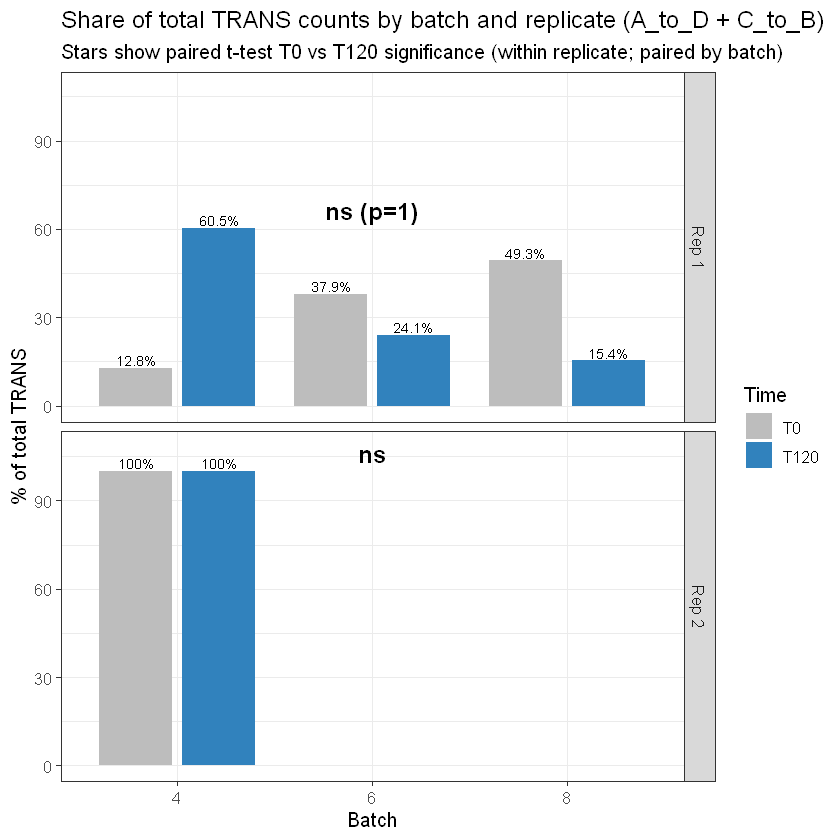

In [37]:
print(p_group4_trans_total)

**Figure 4A. Share of total TRANS counts by batch and replicate.**

- **Methods/Computation:** For each replicate-time stratum, TRANS totals were aggregated by batch and converted to percent share: $$\text{TRANS share}_{b} = 100\times\frac{T_b}{\sum_{b'} T_{b'}}$$ where $T_b$ is total TRANS count for batch $b$.
- **Biological relevance (with sources):** This quantifies how strongly non-cognate association activity is concentrated in specific contexts, which is relevant when interpreting DSB mobility/co-localization effects after damage induction [1,2].

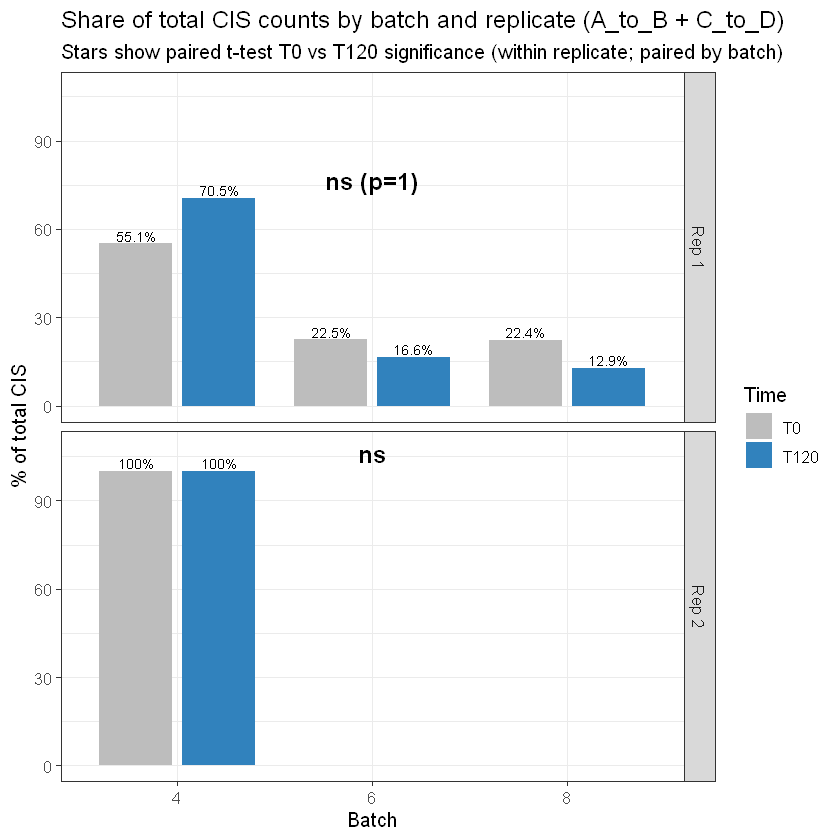

In [38]:
print(p_group4_cis_total)

**Figure 4B. Share of total CIS counts by batch and replicate.**

- **Methods/Computation:** CIS counts were converted to within-stratum batch shares: $$\text{CIS share}_{b} = 100\times\frac{C_b}{\sum_{b'} C_{b'}}$$ where $C_b$ is total CIS count for batch $b$.
- **Biological relevance (with sources):** CIS dominance is expected under canonical end joining; comparing CIS-share stability across batches helps separate robust repair-channel behavior from run-specific artifacts [1,3].

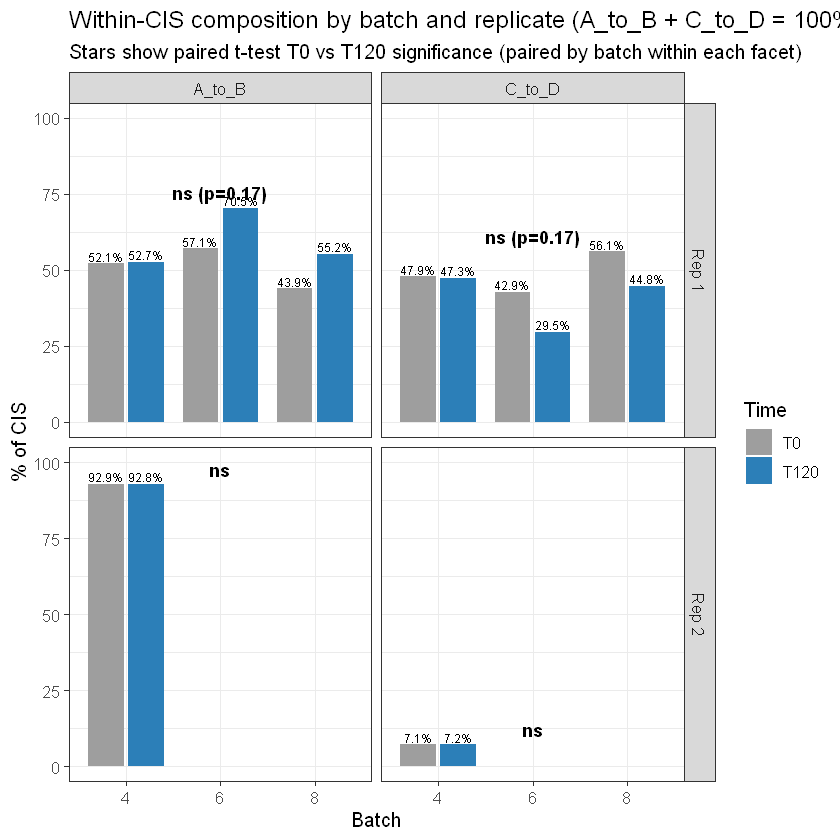

In [67]:
print(p_cis_comp_2only)

**Figure 4C. Within-CIS composition by batch and replicate.**

- **Methods/Computation:** CIS reads were normalized so components sum to 100%: $$p_{A\to B}=100\times\frac{N_{A\to B}}{N_{A\to B}+N_{C\to D}},\quad p_{C\to D}=100-p_{A\to B}.$$
- **Biological relevance (with sources):** Relative weighting of cognate channels reflects locus-specific partner preference under NHEJ and can reveal condition-dependent shifts in repair-associated pairing [1,2].

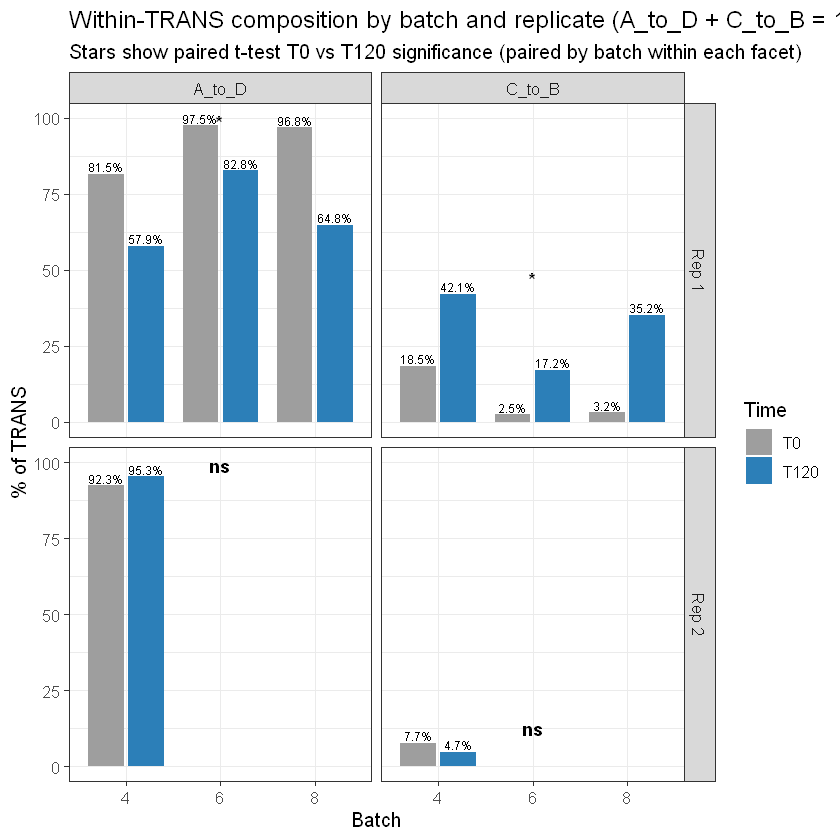

In [68]:
print(p_trans_comp_2only)

**Figure 4D. Within-TRANS composition by batch and replicate.**

- **Methods/Computation:** TRANS reads were normalized within channel: $$p_{A\to D}=100\times\frac{N_{A\to D}}{N_{A\to D}+N_{C\to B}},\quad p_{C\to B}=100-p_{A\to D}.$$
- **Biological relevance (with sources):** This compares non-cognate partner preference across conditions, consistent with hypotheses that post-damage motion and encounter dynamics can reshape DSB partner choice [2,7].

In [54]:
dat_norm_combo %>% head(10)

batch,replicate,time_point,DSB,allele,Cis_Location_Counts,Trans_Location_Counts,Total_Cis_Location_Counts,Total_Trans_Location_Counts,Total_Group_Counts,Percent_Cis_of_GroupTotal,Percent_Trans_of_GroupTotal,Percent_Location_in_Cis,Percent_Location_in_Trans
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,Rep 1,0,DSB1,Chr12_L01,23365,0,499775,0,499775,4.67510380,0,4.67510380,NA
4,Rep 1,0,DSB1,Chr12_L05,15119,0,499775,0,499775,3.02516132,0,3.02516132,NA
4,Rep 1,0,DSB1,Chr12_L07,19481,0,499775,0,499775,3.89795408,0,3.89795408,NA
4,Rep 1,0,DSB1,Chr12_L12,22779,0,499775,0,499775,4.55785103,0,4.55785103,NA
4,Rep 1,0,DSB1,Chr15_L01,27868,0,499775,0,499775,5.57610925,0,5.57610925,NA
4,Rep 1,0,DSB1,Chr15_L04,54,0,499775,0,499775,0.01080486,0,0.01080486,NA
4,Rep 1,0,DSB1,Chr15_L15,14456,0,499775,0,499775,2.89250163,0,2.89250163,NA
4,Rep 1,0,DSB1,Chr15_L17_2,28338,0,499775,0,499775,5.67015157,0,5.67015157,NA
4,Rep 1,0,DSB1,Chr15_L18,4689,0,499775,0,499775,0.93822220,0,0.93822220,NA


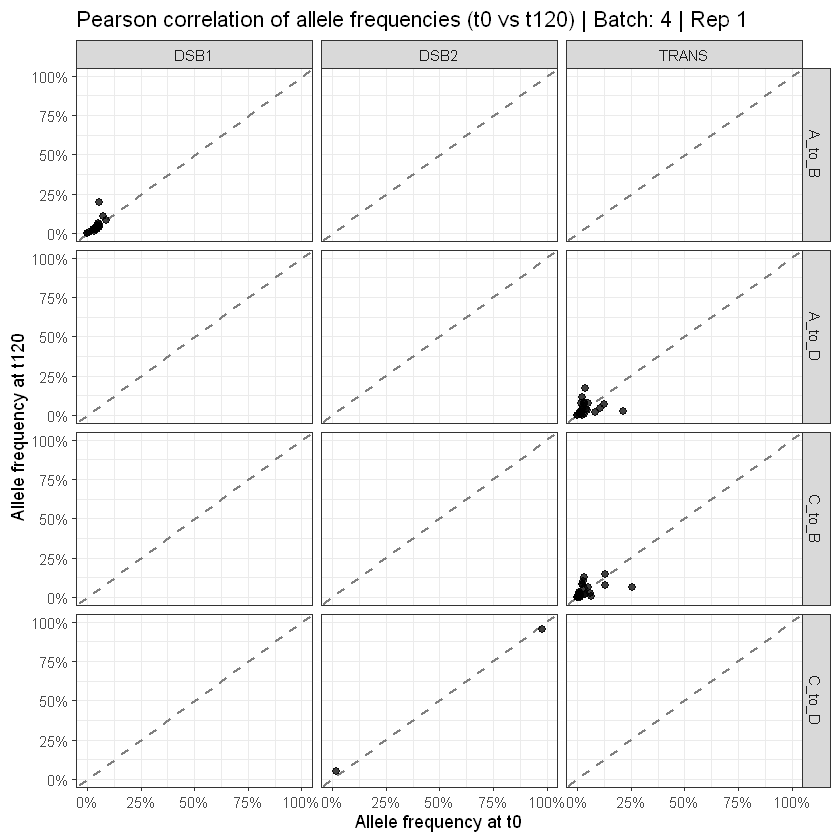

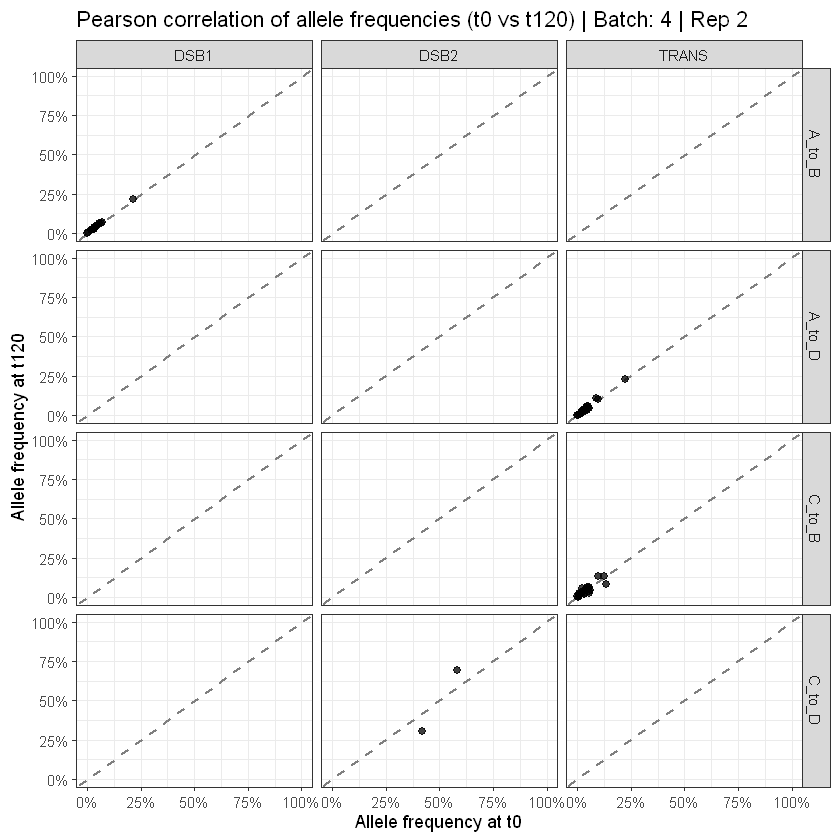

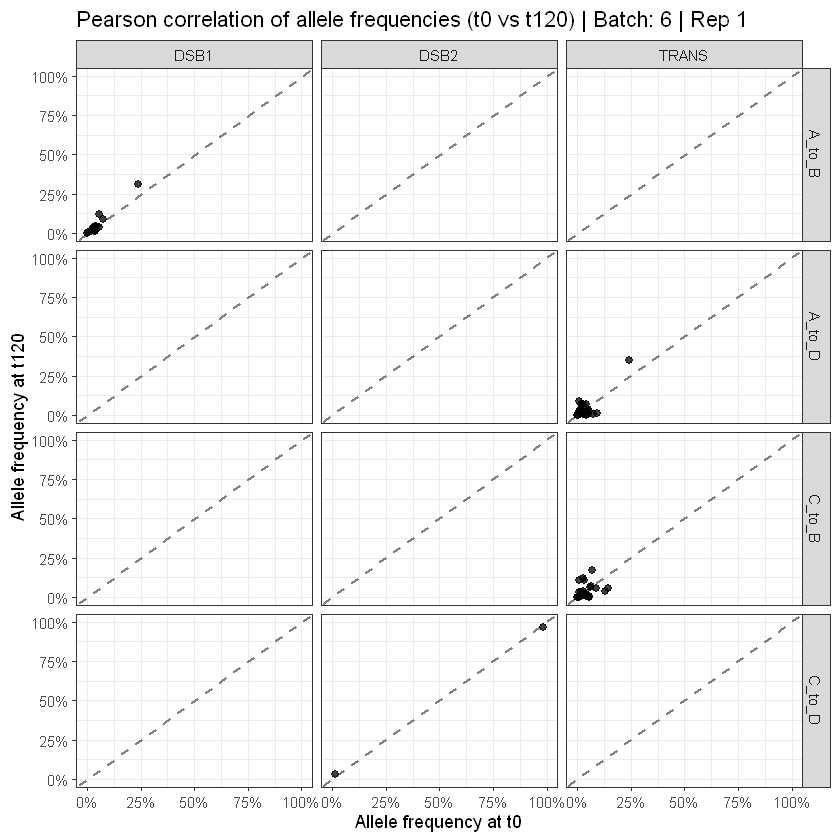

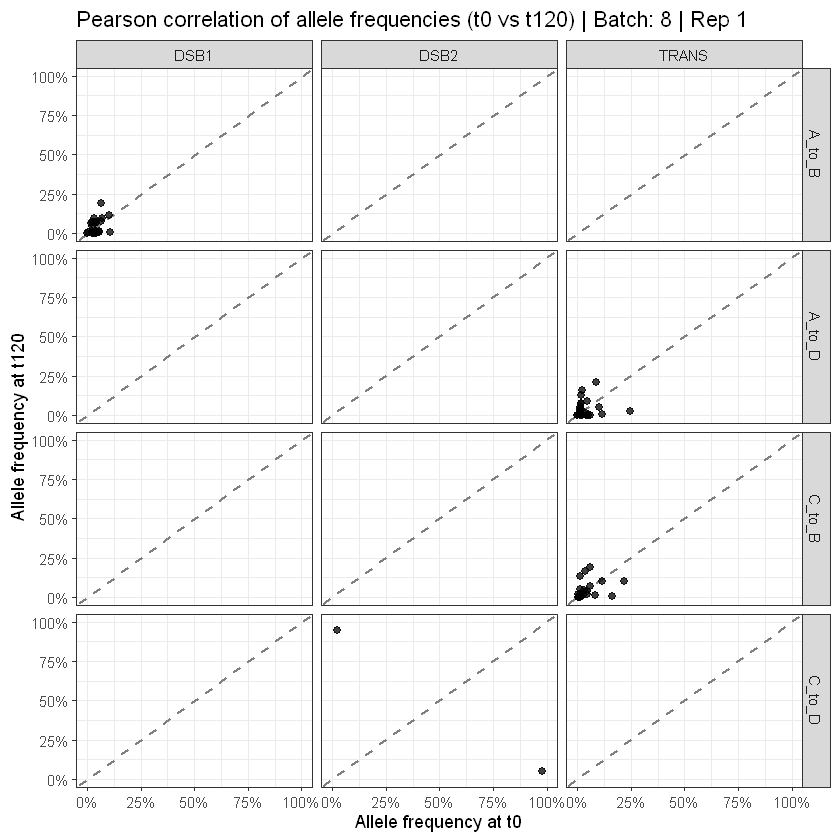

batch,replicate,DSB,cor_CIS_AF,cor_TRANS_AF,n_obs
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
4,Rep 1,DSB1,0.7330286,NA,24
4,Rep 1,DSB2,-1.0000000,NA,2
4,Rep 1,TRANS,NA,0.5593380,26
4,Rep 2,DSB1,0.2097350,NA,24
4,Rep 2,DSB2,1.0000000,NA,2
4,Rep 2,TRANS,NA,0.3655712,24
6,Rep 1,DSB1,0.4087059,NA,24
6,Rep 1,DSB2,-1.0000000,NA,2
6,Rep 1,TRANS,NA,0.4852722,24


Allele-frequency paired t-test (T0 vs T120, paired by allele, within batch x replicate x DSB):



# A tibble: 12 × 8
   batch replicate DSB   n_pairs mean_af_t0 mean_af_t120 p_value significance
   <chr> <chr>     <chr>   <int>      <dbl>        <dbl>   <dbl> <chr>       
 1 4     Rep 1     DSB1       24     0.0417       0.0417   1     ns          
 2 4     Rep 1     DSB2        2     0.5          0.5      1     ns          
 3 4     Rep 1     TRANS      26     0.0390       0.0401   0.883 ns          
 4 4     Rep 2     DSB1       24     0.0417       0.0417   1     ns          
 5 4     Rep 2     DSB2        2     0.5          0.5      1     ns          
 6 4     Rep 2     TRANS      24     0.0417       0.0417   1     ns          
 7 6     Rep 1     DSB1       24     0.0417       0.0417   1     ns          
 8 6     Rep 1     DSB2        2     0.5          0.5      1     ns          
 9 6     Rep 1     TRANS      24     0.0417       0.0417   1     ns          
10 8     Rep 1     DSB1       24     0.0417       0.0417   1     ns          
11 8     Rep 1     DSB2        2     0.5     

Log2FC CIS one-sample t-test (H0: mean log2FC = 0):



# A tibble: 8 × 7
  batch replicate DSB   n_obs mean_log2fc  p_value significance
  <chr> <chr>     <chr> <int>       <dbl>    <dbl> <chr>       
1 4     Rep 1     DSB1     24     -0.0952 4.48e- 1 ns          
2 4     Rep 1     DSB2      2      0.721  4.85e- 1 ns          
3 4     Rep 2     DSB1     24     -0.963  7.53e-19 ***         
4 4     Rep 2     DSB2      2     -1.02   2.16e- 1 ns          
5 6     Rep 1     DSB1     24     -0.689  8.20e- 5 ***         
6 6     Rep 1     DSB2      2     -0.703  4.27e- 1 ns          
7 8     Rep 1     DSB1     24     -1.77   1.25e- 3 **          
8 8     Rep 1     DSB2      2     -0.823  8.93e- 1 ns          


Log2FC TRANS one-sample t-test (H0: mean log2FC = 0):



# A tibble: 4 × 7
  batch replicate DSB   n_obs mean_log2fc      p_value significance
  <chr> <chr>     <chr> <int>       <dbl>        <dbl> <chr>       
1 4     Rep 1     TRANS    26       2.77  0.0000000349 ***         
2 4     Rep 2     TRANS    24      -0.384 0.00000796   ***         
3 6     Rep 1     TRANS    24      -0.364 0.344        ns          
4 8     Rep 1     TRANS    24      -1.55  0.0125       *           


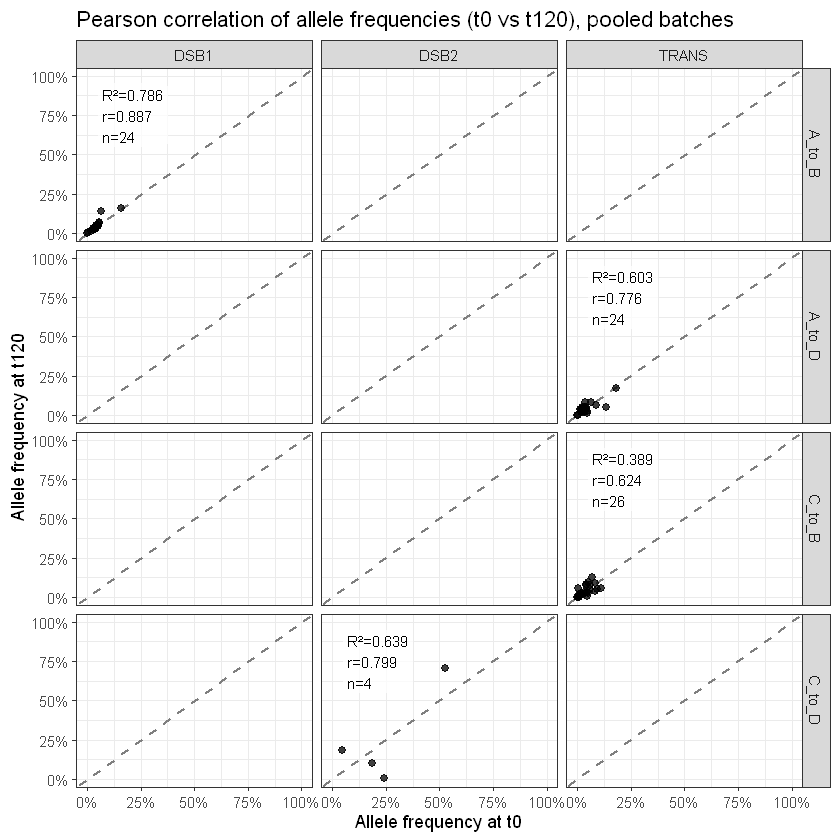

In [49]:
# ---- Sections 4.1, 5, 6: AF correlations + fold-change + summary correlation table ----
# Allele frequency (CIS + TRANS) per group
my_summarize_allelefreq <- function(dat) {
  by_allele <- dat %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(
      Cis_Counts = sum(count[combo %in% cis_combos], na.rm = TRUE),
      Trans_Counts = sum(count[combo %in% trans_combos], na.rm = TRUE),
      Allele_Total = Cis_Counts + Trans_Counts,
      .groups = 'drop',
    )

  totals <- by_allele %>%
    group_by(batch, replicate, time_point, DSB) %>%
    summarise(
      Total_Cis = sum(Cis_Counts, na.rm = TRUE),
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Total_All = Total_Cis + Total_Trans,
      .groups = 'drop',
    )

  by_allele %>%
    left_join(totals, by = c('batch', 'replicate', 'time_point', 'DSB')) %>%
    mutate(Allele_Frequency = if_else(Total_All > 0, Allele_Total / Total_All, NA_real_))
}

safe_cor <- function(x, y) {
  idx <- is.finite(x) & is.finite(y)
  if (sum(idx) < 2) return(NA_real_)
  suppressWarnings(cor(x[idx], y[idx], method = 'pearson'))
}

dat_allele_freq <- my_summarize_allelefreq(dat_focus)

# 4.1 Pearson correlation of allele frequencies t0 vs t120
timepoints_compare <- c(0, 120)

dat_allele_freq_combo <- dat_focus %>%
  group_by(batch, replicate, DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(batch, replicate, DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_),
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_af <- dat_allele_freq_combo %>%
  select(batch, replicate, DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats <- dat_wide_af %>%
  group_by(batch, replicate, DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop',
  ) %>%
  mutate(
    r2 = if_else(is.na(r), NA_real_, r^2),
    label = if_else(
      is.na(r),
      paste0('n=', n_pairs),
      paste0('R²=', round(r2, 3), '\n', 'r=', round(r, 3), '\n', 'n=', n_pairs),
    ),
  )

plot_cor_by_batch <- function(df_wide, df_stats) {
  keys <- df_wide %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    dfb <- df_wide %>% filter(batch == b, replicate == r)
    if (nrow(dfb) == 0) next

    statsb <- df_stats %>% filter(batch == b, replicate == r)

    p <- ggplot(dfb, aes(x = t0, y = t120)) +
      geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
      geom_point(alpha = 0.75, size = 1.8) +
      facet_grid(combo ~ DSB) +
      geom_label(
        data = statsb,
        aes(x = 0.05, y = 0.95, label = label),
        inherit.aes = FALSE,
        hjust = 0,
        vjust = 1,
        size = 3.1,
        linewidth = 0,
        fill = scales::alpha('white', 0.75),
      ) +
      scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
      theme_bw(base_size = 11) +
      labs(
        title = paste0('Pearson correlation of allele frequencies (t0 vs t120) | Batch: ', b, ' | ', r),
        x = 'Allele frequency at t0',
        y = 'Allele frequency at t120',
      )
    print(p)
  }
}

if (nrow(dat_wide_af) > 0) plot_cor_by_batch(dat_wide_af, cor_stats)

# Pooled across batches
dat_allele_freq_combo_overall <- dat_focus %>%
  group_by(DSB, combo, time_point, allele) %>%
  summarise(Allele_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, combo, time_point) %>%
  mutate(
    Total_Counts = sum(Allele_Counts, na.rm = TRUE),
    Allele_Frequency = if_else(Total_Counts > 0, Allele_Counts / Total_Counts, NA_real_),
  ) %>%
  ungroup() %>%
  filter(time_point %in% timepoints_compare)

dat_wide_overall <- dat_allele_freq_combo_overall %>%
  select(DSB, combo, allele, time_point, Allele_Frequency) %>%
  mutate(tp = paste0('t', time_point)) %>%
  select(-time_point) %>%
  pivot_wider(names_from = tp, values_from = Allele_Frequency)

cor_stats_overall <- dat_wide_overall %>%
  group_by(DSB, combo) %>%
  summarise(
    n_pairs = sum(is.finite(t0) & is.finite(t120)),
    r = safe_cor(t0, t120),
    .groups = 'drop',
  ) %>%
  mutate(
    r2 = if_else(is.na(r), NA_real_, r^2),
    label = if_else(
      is.na(r),
      paste0('n=', n_pairs),
      paste0('R²=', round(r2, 3), '\n', 'r=', round(r, 3), '\n', 'n=', n_pairs),
    ),
  )

if (nrow(dat_wide_overall) > 0) {
  p_overall_af_corr <- ggplot(dat_wide_overall, aes(x = t0, y = t120)) +
    geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
    geom_point(alpha = 0.75, size = 1.8) +
    facet_grid(combo ~ DSB) +
    geom_label(
      data = cor_stats_overall,
      aes(x = 0.05, y = 0.95, label = label),
      inherit.aes = FALSE,
      hjust = 0,
      vjust = 1,
      size = 3.1,
      linewidth = 0,
      fill = scales::alpha('white', 0.75),
    ) +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    theme_bw(base_size = 11) +
    labs(
      title = 'Pearson correlation of allele frequencies (t0 vs t120), pooled batches',
      x = 'Allele frequency at t0',
      y = 'Allele frequency at t120',
    )
  print(p_overall_af_corr)
}

# Section 5: Fold-change calculations (120 / 0)
eps <- 1e-6

dat_fc_cis <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Cis_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Cis_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Cis_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Cis_120_vs_0 = log2(FoldChange_Cis_120_vs_0),
  )

dat_fc_trans <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = Trans_Location_Counts, values_fill = 0) %>%
  mutate(
    FoldChange_Trans_120_vs_0 = fc_ratio(`120`, `0`, eps = eps),
    Log2FC_Trans_120_vs_0 = log2(FoldChange_Trans_120_vs_0),
  )

# Section 6: Correlation of log2FC vs AF
dat_wide <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, DSB, allele, time_point, Cis_Location_Counts, Trans_Location_Counts) %>%
  pivot_wider(names_from = time_point, values_from = c(Cis_Location_Counts, Trans_Location_Counts), values_fill = 0) %>%
  mutate(
    log2FC_CIS = log2(fc_ratio(Cis_Location_Counts_120, Cis_Location_Counts_0, eps = eps)),
    log2FC_TRANS = log2(fc_ratio(Trans_Location_Counts_120, Trans_Location_Counts_0, eps = eps)),
  )

dat_fc_af <- dat_wide %>%
  inner_join(
    dat_allele_freq %>% filter(time_point == 120) %>% select(batch, replicate, DSB, allele, Allele_Frequency),
    by = c('batch', 'replicate', 'DSB', 'allele'),
  ) %>%
  filter(!is.na(Allele_Frequency) & Allele_Frequency > 0)

cor_summary <- dat_fc_af %>%
  group_by(batch, replicate, DSB) %>%
  summarise(
    cor_CIS_AF = safe_cor(log2FC_CIS, Allele_Frequency),
    cor_TRANS_AF = safe_cor(log2FC_TRANS, Allele_Frequency),
    n_obs = n(),
    .groups = 'drop',
  )

cor_summary

# ---- T-tests for fold changes and allele frequency (T0 vs T120) ----

# (1) Paired t-test: AF at T0 vs T120 paired by allele, within batch x replicate x DSB
run_af_paired_ttest <- function(df_af) {
  # Note: some upstream summaries can leave duplicate rows per allele x timepoint.
  # We collapse those duplicates to a single numeric value (mean AF) before widening.
  df_af %>%
    filter(time_point %in% c(0, 120), is.finite(Allele_Frequency)) %>%
    select(batch, replicate, DSB, allele, time_point, Allele_Frequency) %>%
    group_by(batch, replicate, DSB, allele, time_point) %>%
    summarise(Allele_Frequency = mean(Allele_Frequency, na.rm = TRUE), .groups = 'drop') %>%
    pivot_wider(names_from = time_point, values_from = Allele_Frequency, names_prefix = 't') %>%
    filter(is.finite(t0), is.finite(t120)) %>%
    group_by(batch, replicate, DSB) %>%
    group_modify(~ {
      d <- .x
      n <- nrow(d)
      p <- NA_real_
      if (n >= 2) {
        tt <- tryCatch(t.test(d$t120, d$t0, paired = TRUE), error = function(e) NULL)
        if (!is.null(tt)) p <- as.numeric(tt$p.value)
      }
      tibble::tibble(
        n_pairs = n,
        mean_af_t0 = mean(d$t0, na.rm = TRUE),
        mean_af_t120 = mean(d$t120, na.rm = TRUE),
        p_value = p,
      )
    }) %>%
    ungroup() %>%
    mutate(significance = sig_stars(p_value))
}

# (2) One-sample t-test: mean log2FC vs 0 (per batch x replicate x DSB, across alleles)
run_log2fc_onesample_ttest <- function(df_fc, log2fc_col) {
  # NOTE: implemented later in this section
  df_fc %>%
    filter(is.finite(.data[[log2fc_col]])) %>%
    group_by(batch, replicate, DSB) %>%
    summarise(
      n_obs = n(),
      mean_log2fc = mean(.data[[log2fc_col]], na.rm = TRUE),
      p_value = if_else(n_obs >= 2, tryCatch(t.test(.data[[log2fc_col]], mu = 0)$p.value, error = function(e) NA_real_), NA_real_),
      .groups = 'drop',
    ) %>%
    mutate(significance = sig_stars(p_value))
}

message('Allele-frequency paired t-test (T0 vs T120, paired by allele, within batch x replicate x DSB):')
af_ttest <- run_af_paired_ttest(dat_allele_freq_combo)
print(af_ttest)

message('Log2FC CIS one-sample t-test (H0: mean log2FC = 0):')
ttest_log2fc_cis <- run_log2fc_onesample_ttest(dat_fc_cis, 'Log2FC_Cis_120_vs_0')
print(ttest_log2fc_cis)

message('Log2FC TRANS one-sample t-test (H0: mean log2FC = 0):')
ttest_log2fc_trans <- run_log2fc_onesample_ttest(dat_fc_trans, 'Log2FC_Trans_120_vs_0')
print(ttest_log2fc_trans)

**Figure set (Sections 4.1–6). AF correlations, fold-change metrics, and abundance-shift summaries.**

- **Methods/Computation:** Allele-frequency concordance uses Pearson correlation $$r=\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\sqrt{\sum_i (y_i-\bar{y})^2}},$$ with $x_i=f_i(t0)$ and $y_i=f_i(t120)$. Fold-change and stabilized log-ratio are $$\mathrm{FC}_i=\frac{n_i(t120)+\epsilon}{n_i(t0)+\epsilon},\quad \log_2\mathrm{FC}_i=\log_2\!\left(\frac{n_i(t120)+\epsilon}{n_i(t0)+\epsilon}\right).$$
- **Biological relevance (with sources):** High $r$ suggests preserved ligation-junction hierarchy; large $|\log_2\mathrm{FC}|$ indicates selective post-induction redistribution of ligation-supported junction frequencies, informative for DSB-end-joining partner choice [1,2,4].

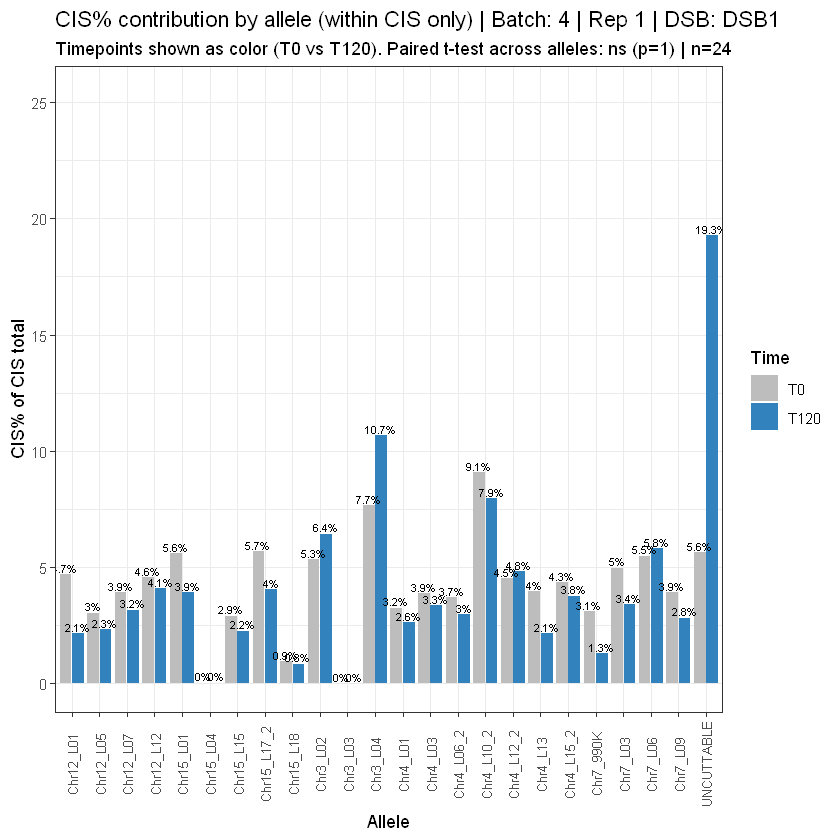

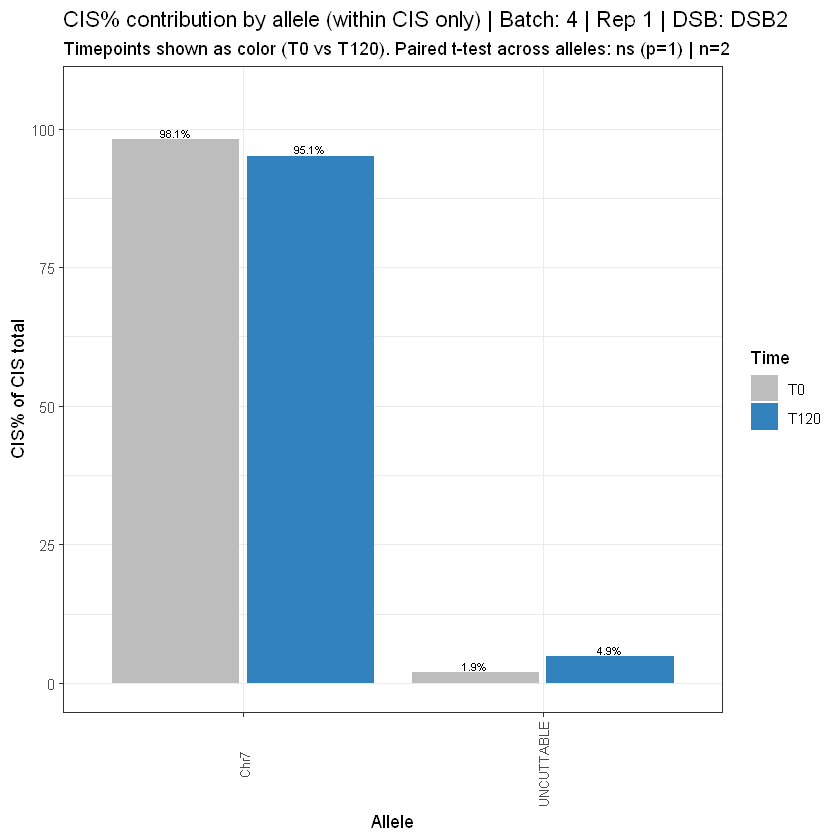

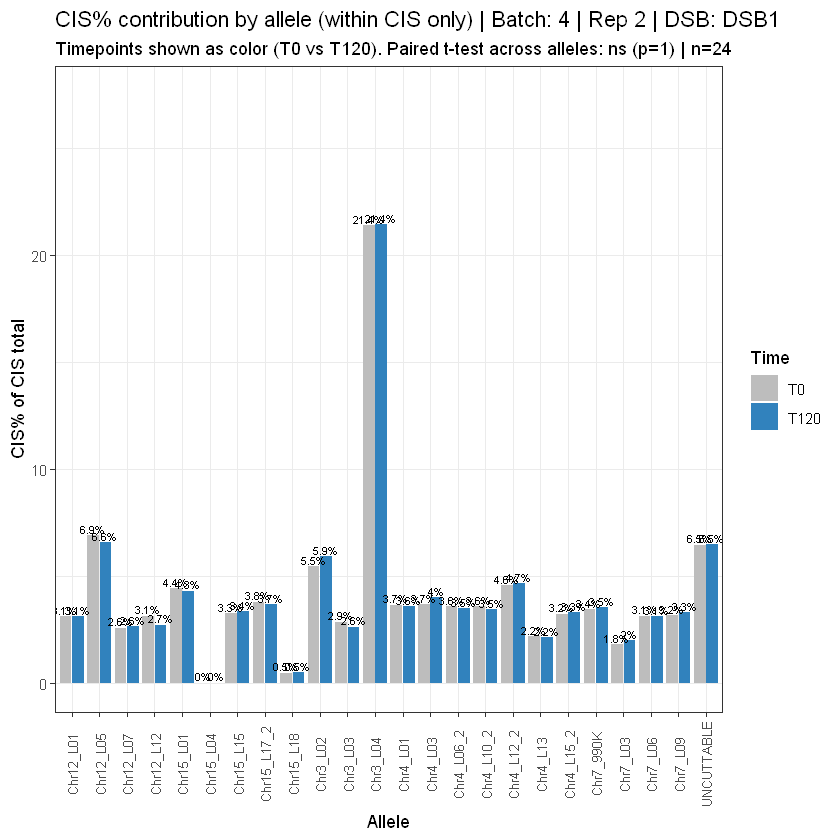

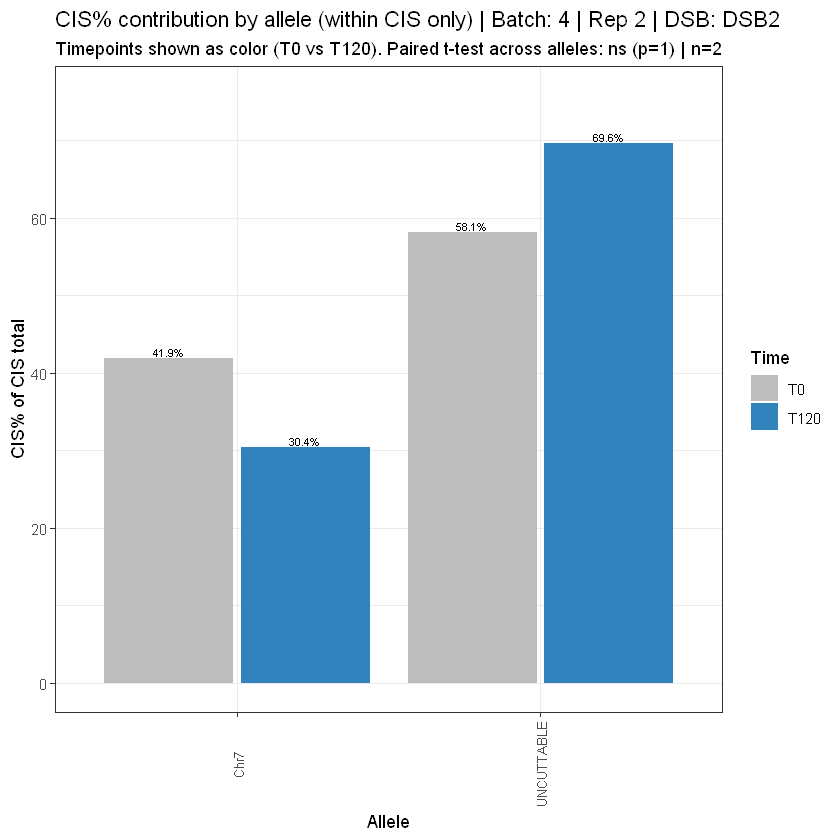

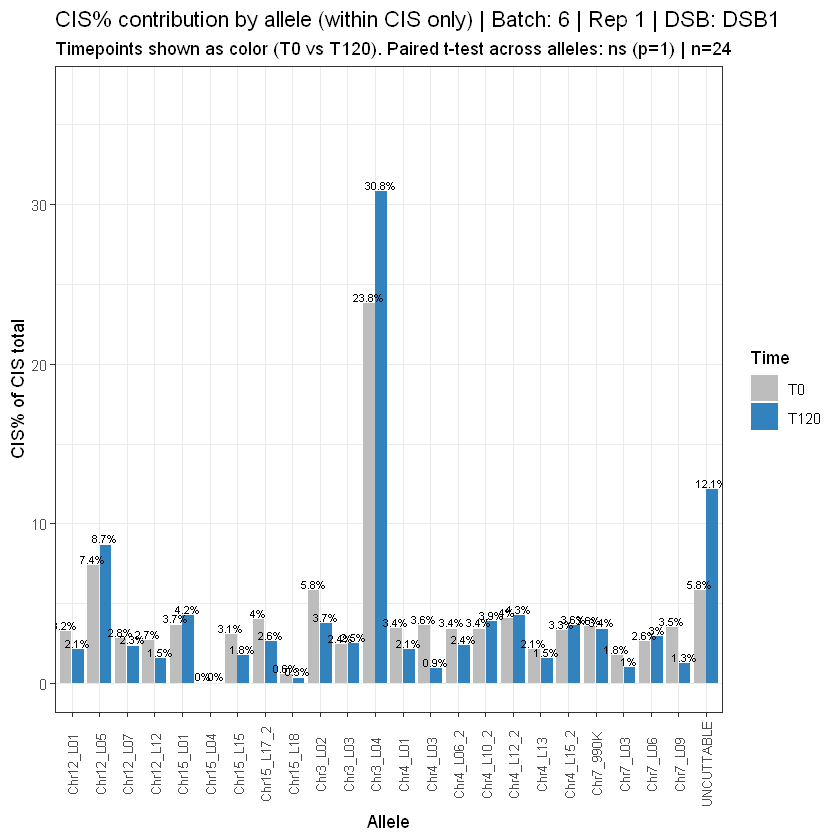

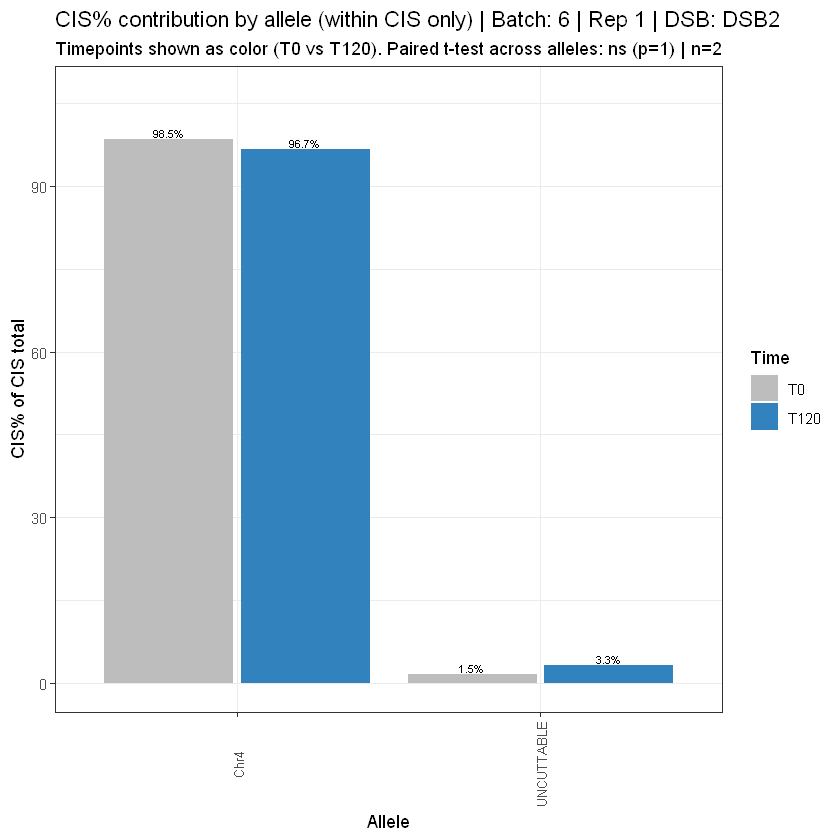

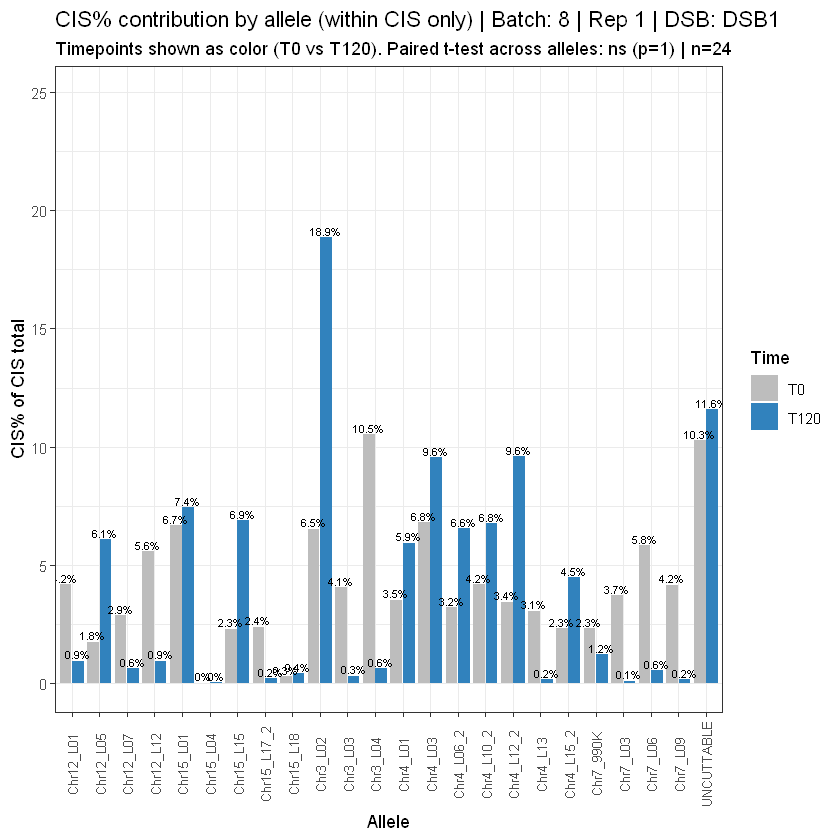

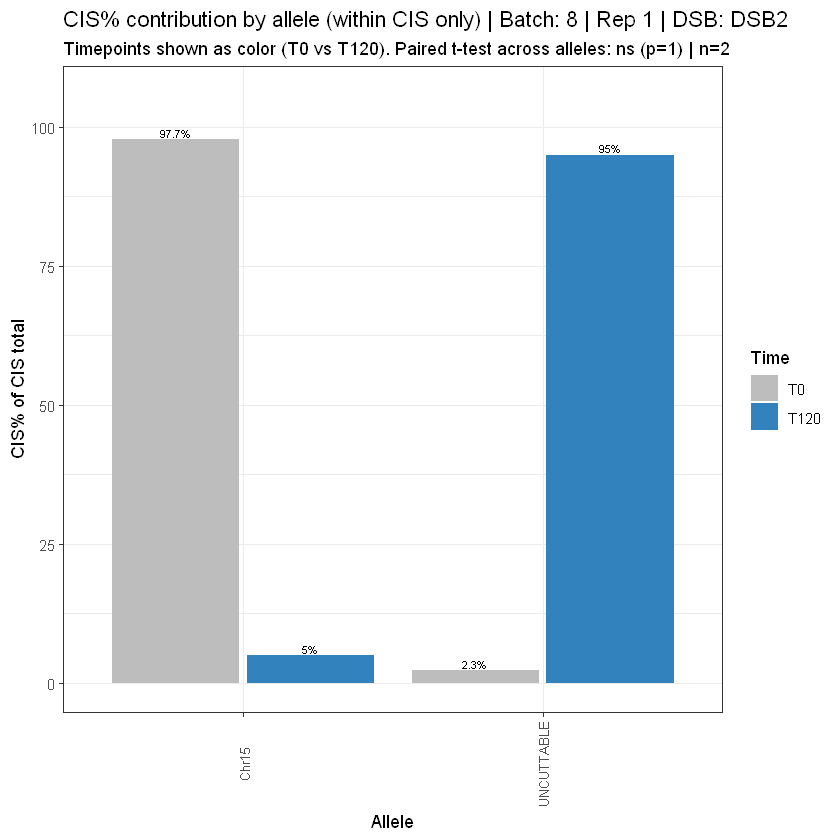

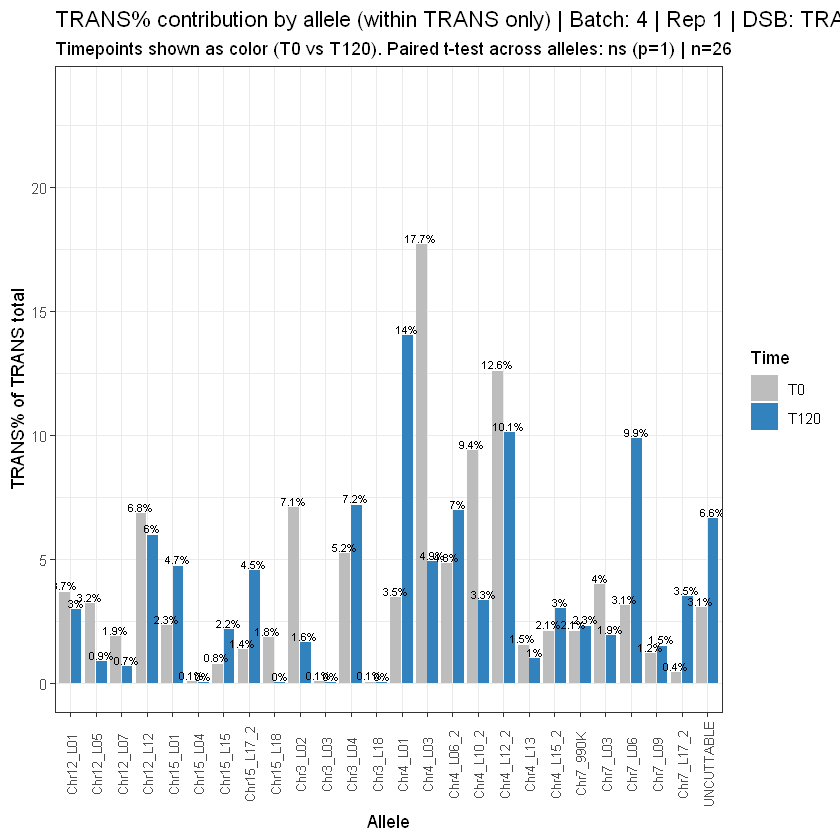

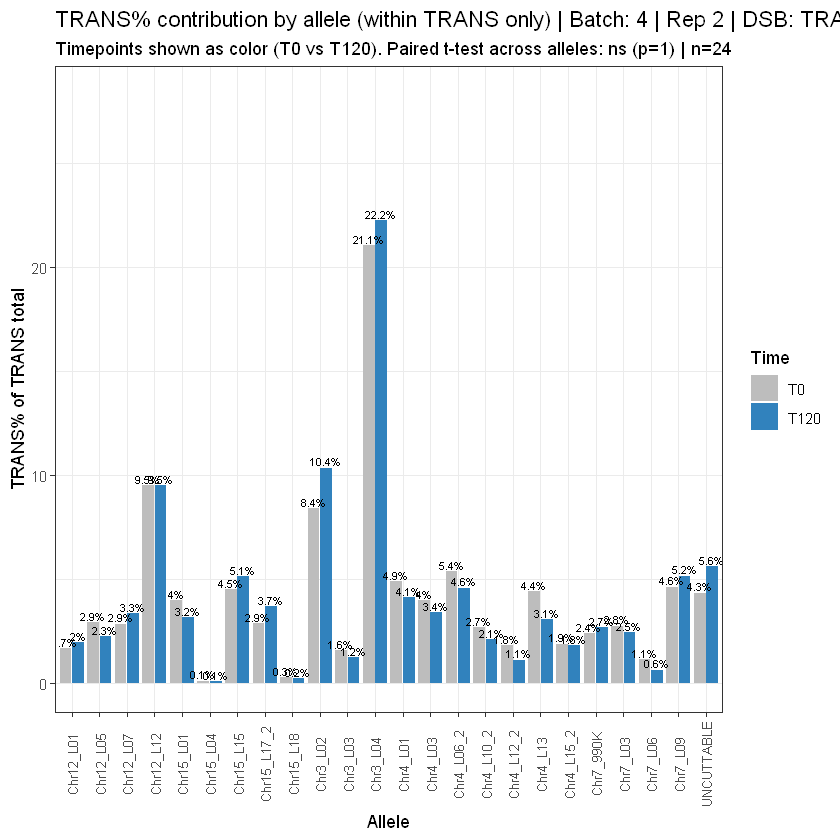

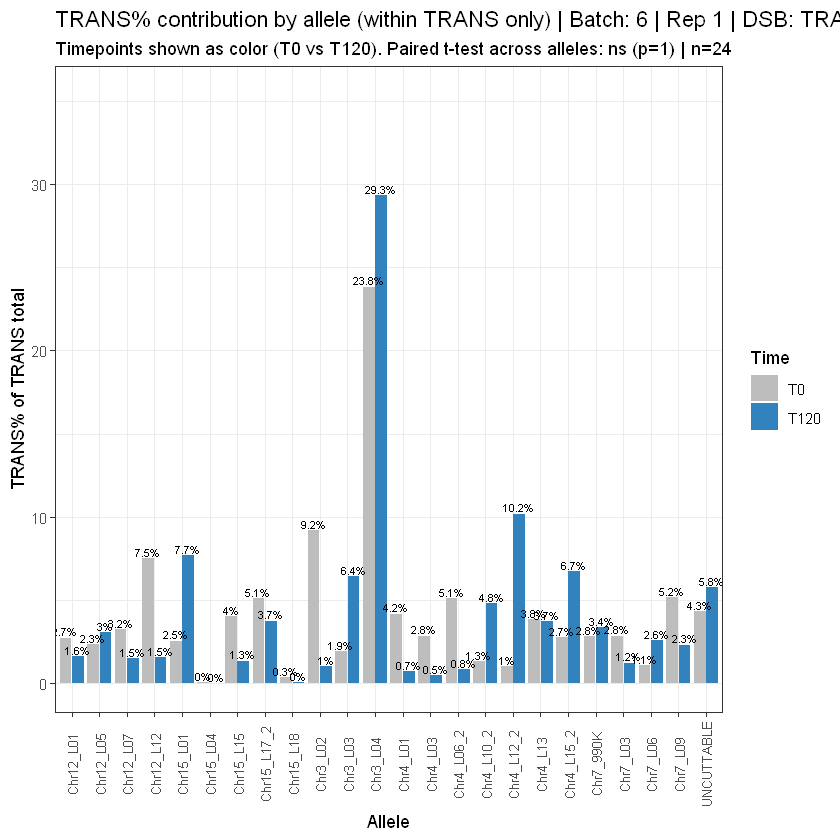

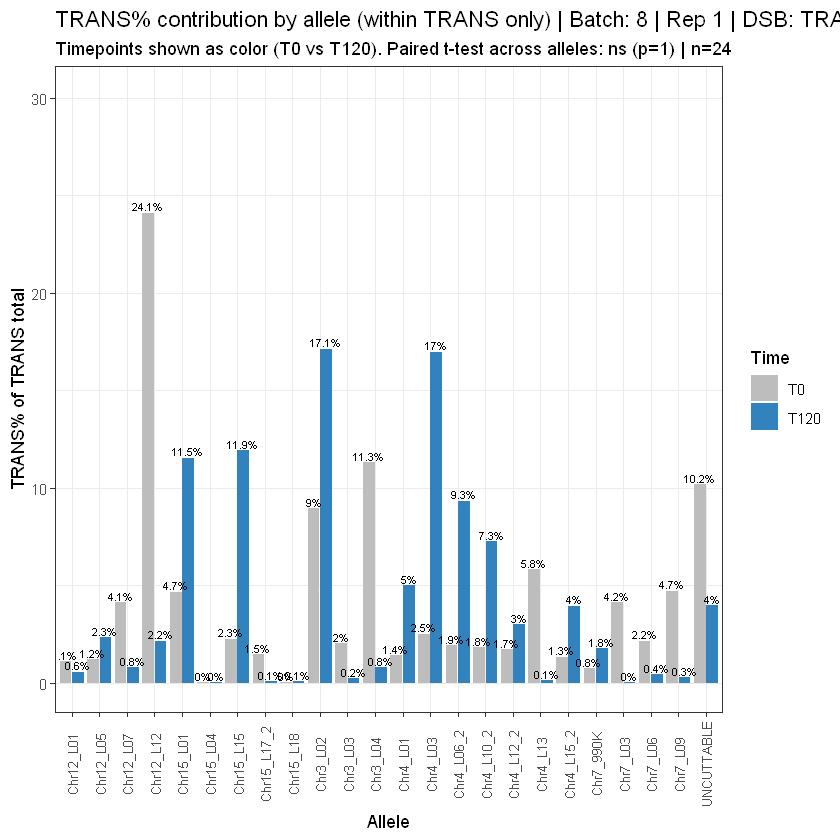

Warning message:
"Removed 10 rows containing missing values or values outside the scale range
(`geom_text()`)."


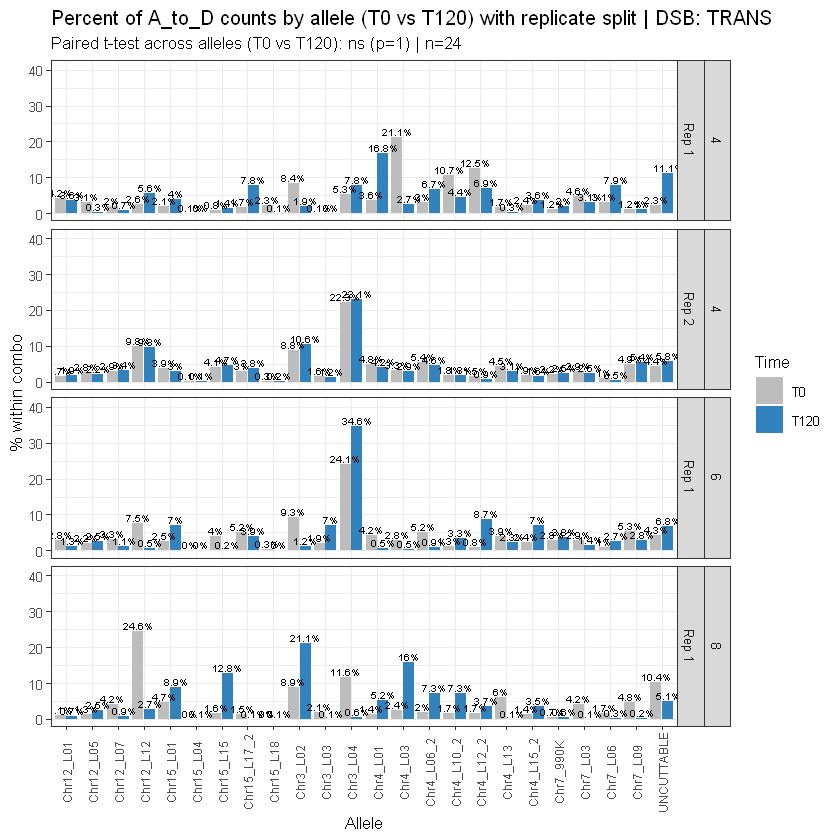

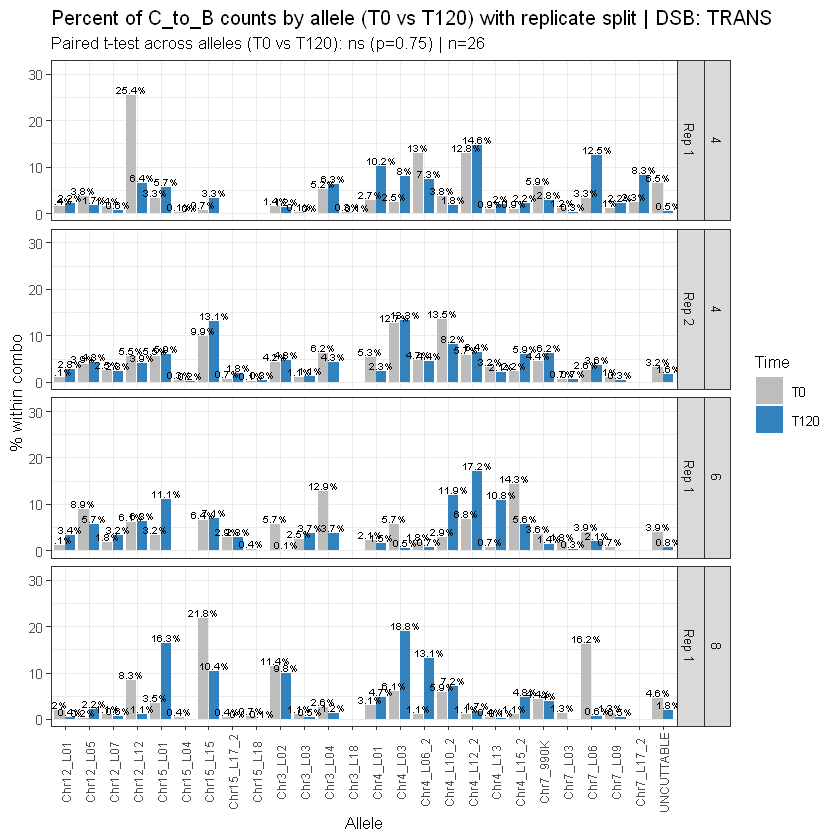

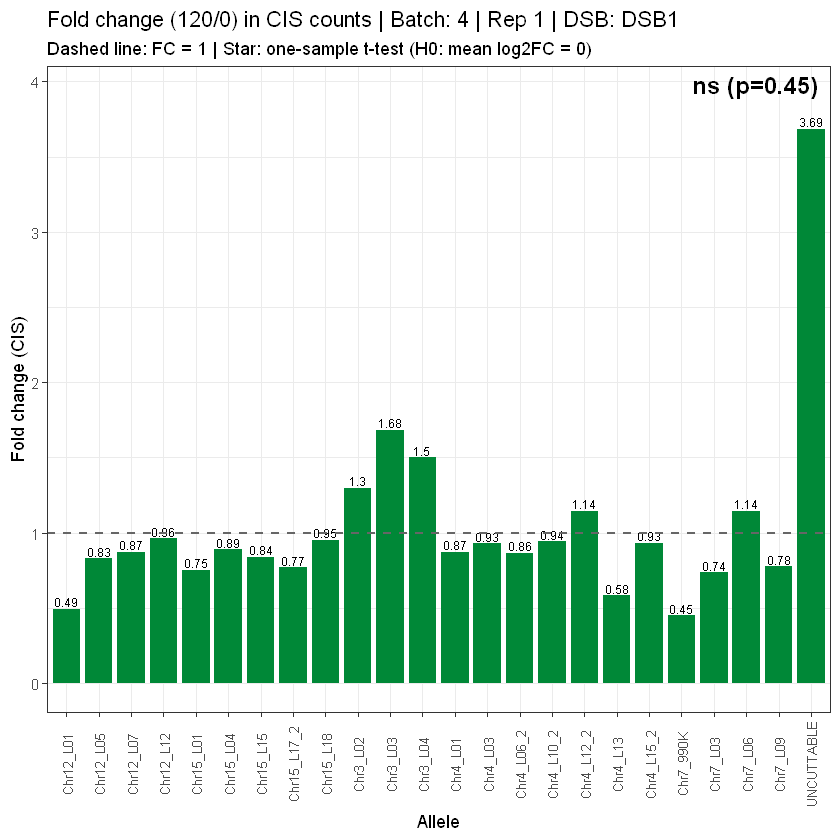

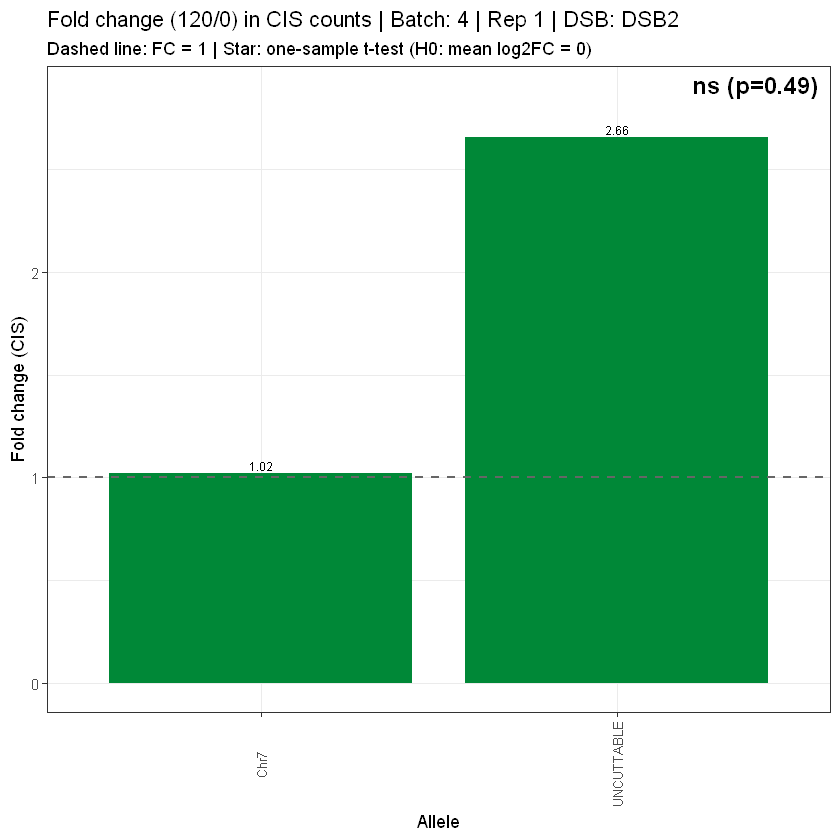

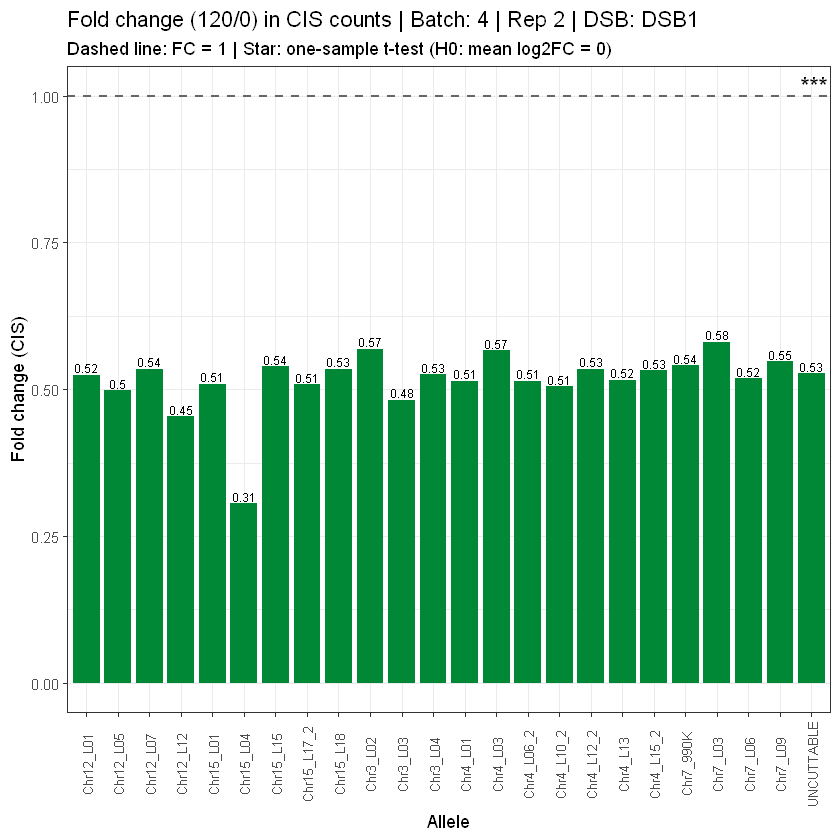

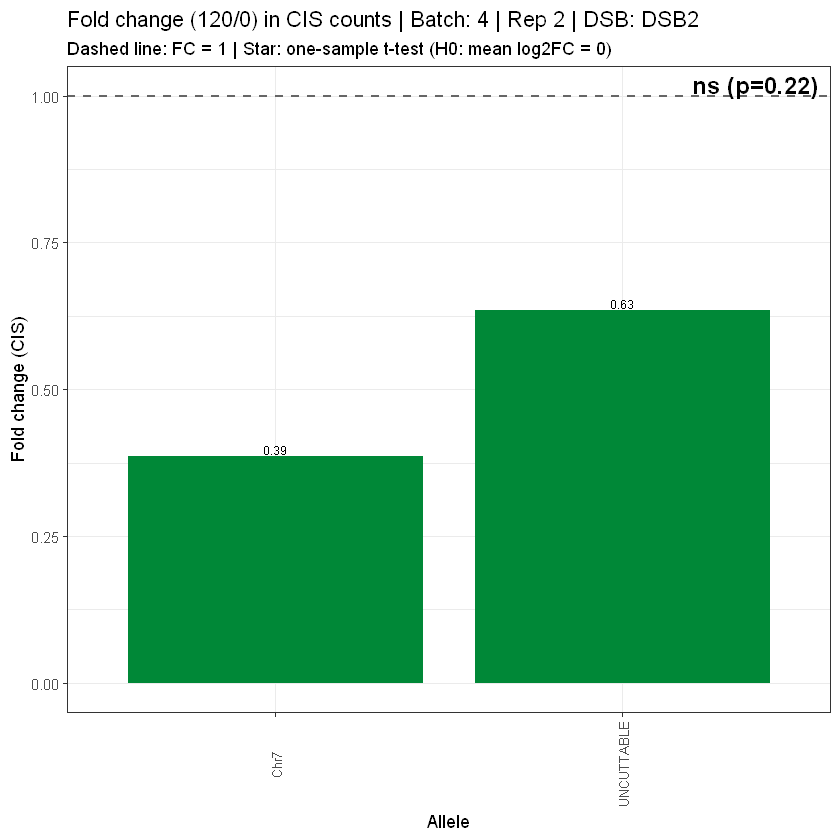

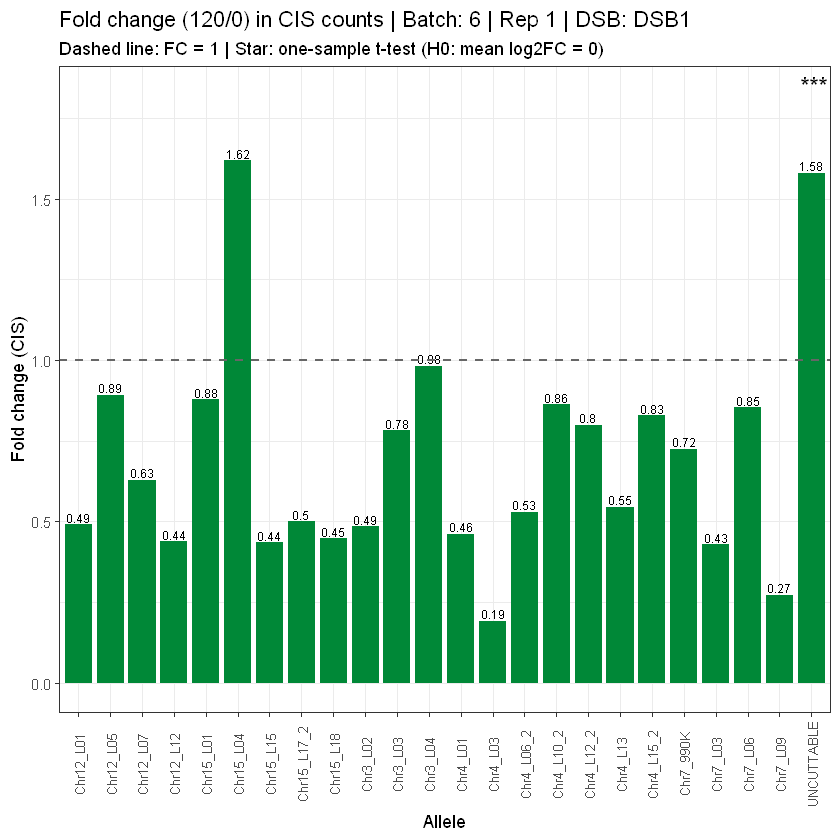

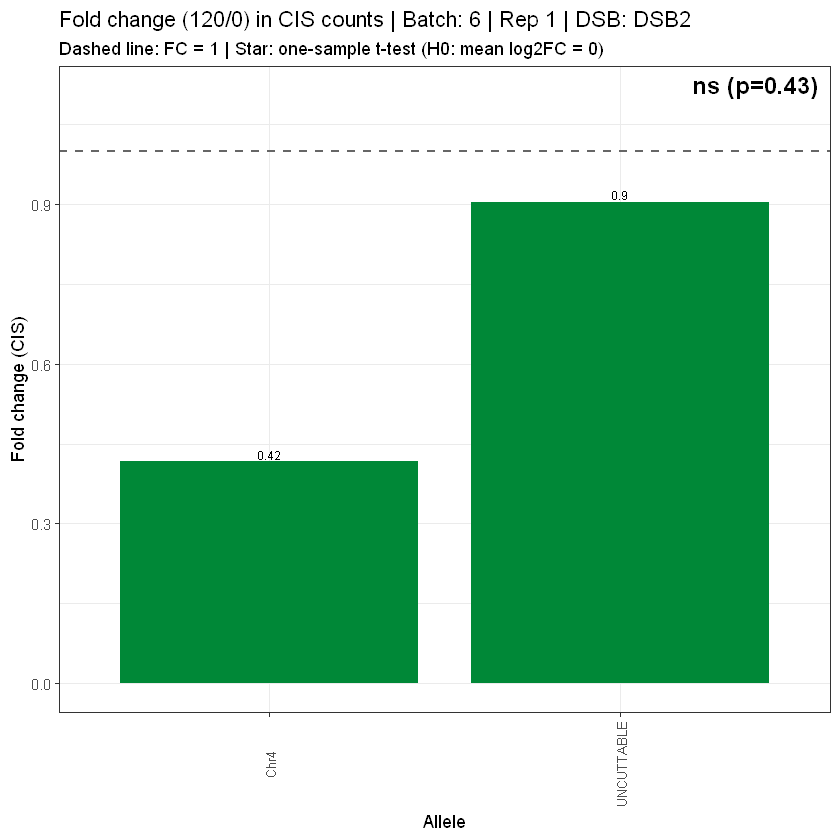

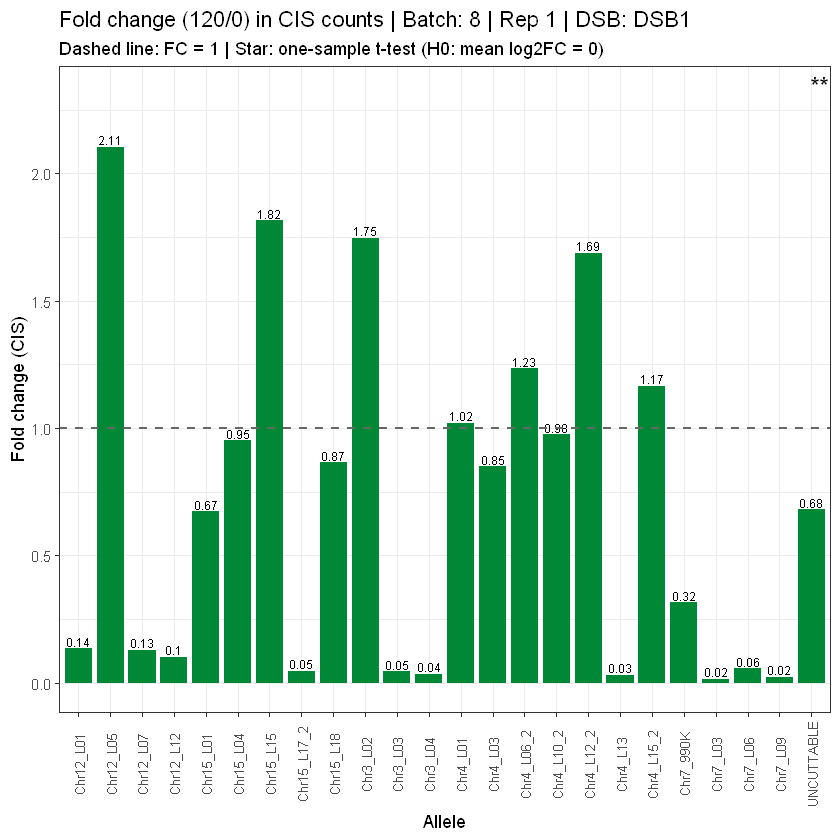

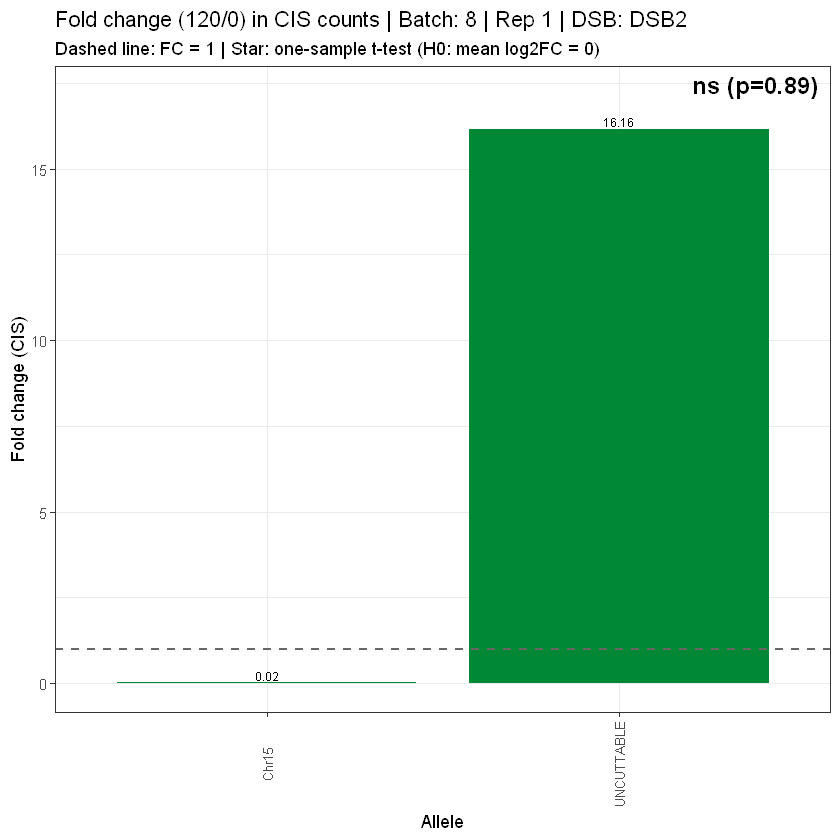

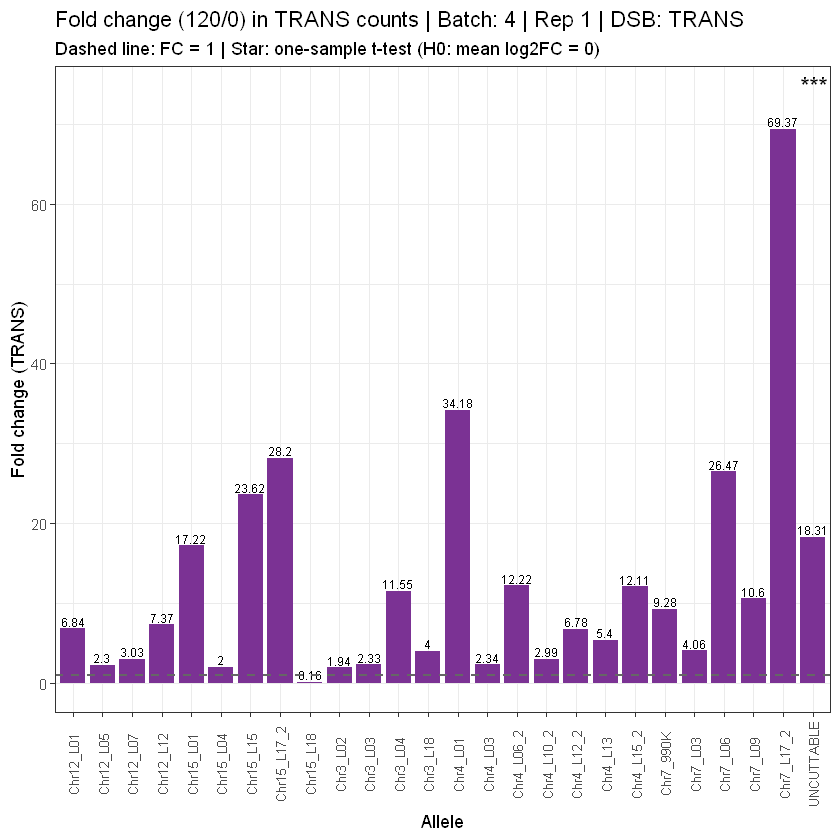

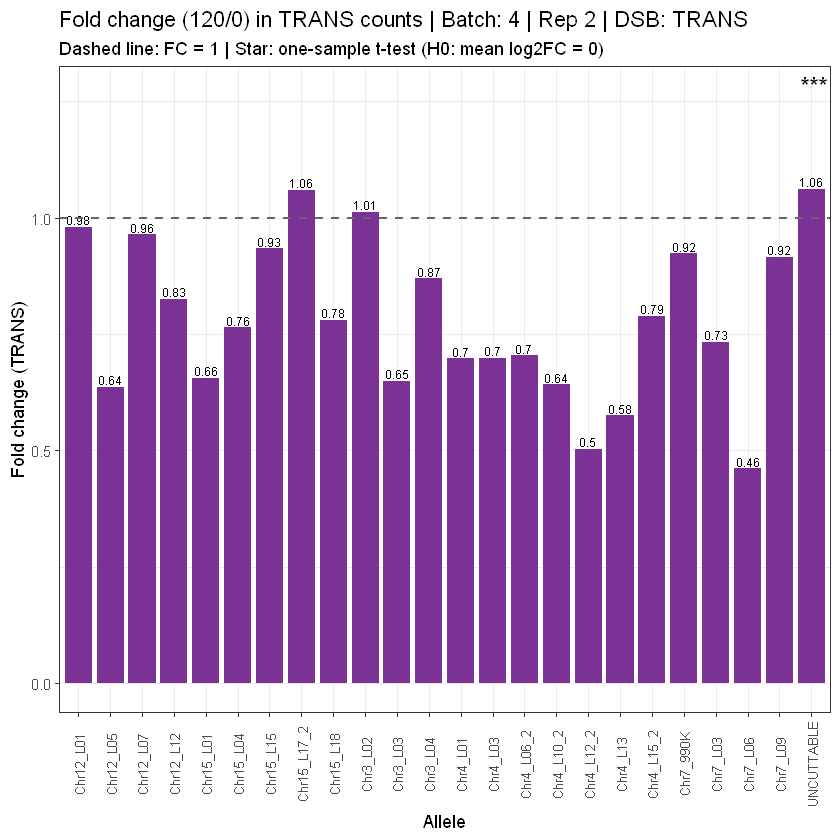

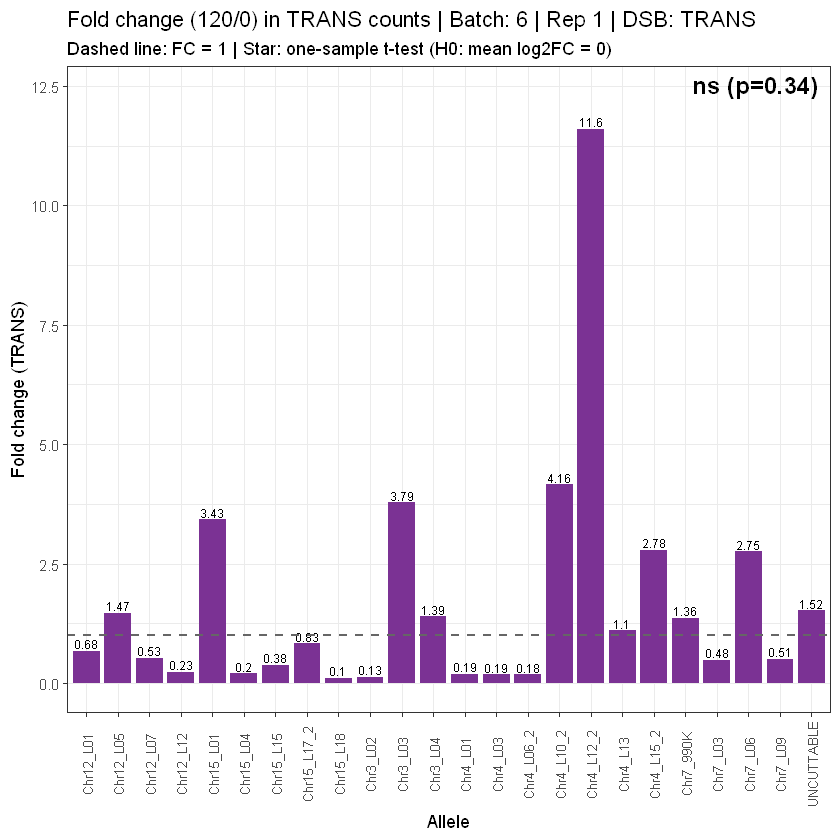

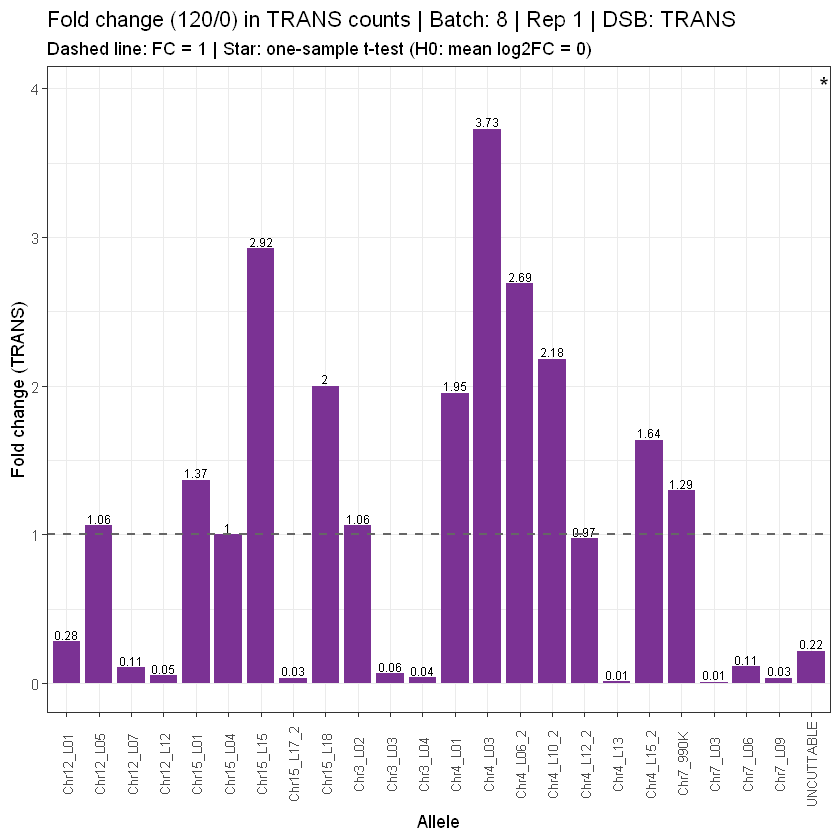

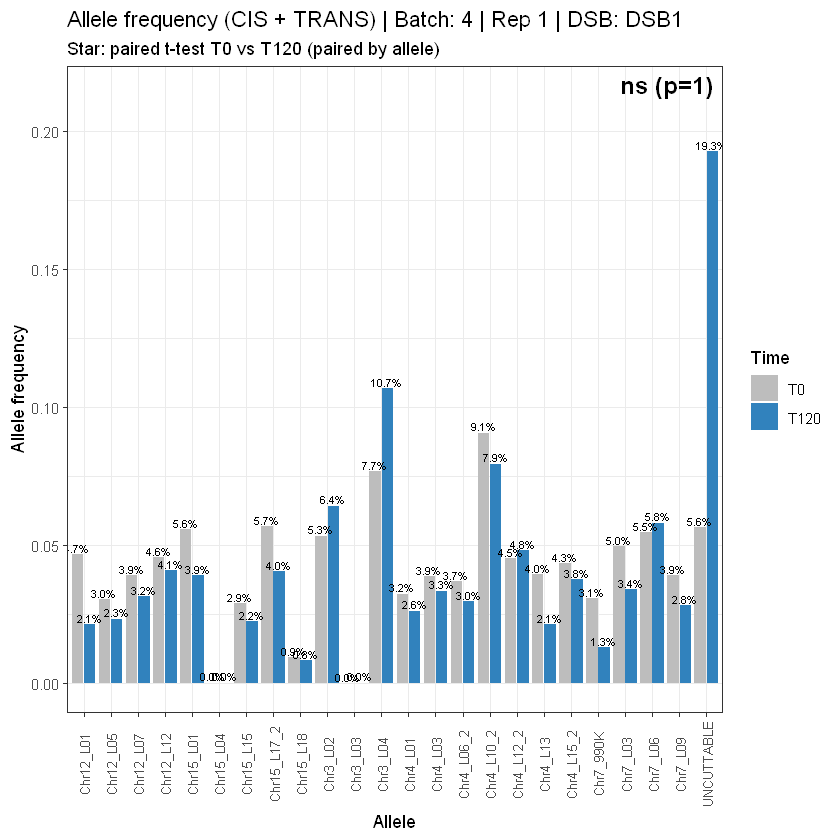

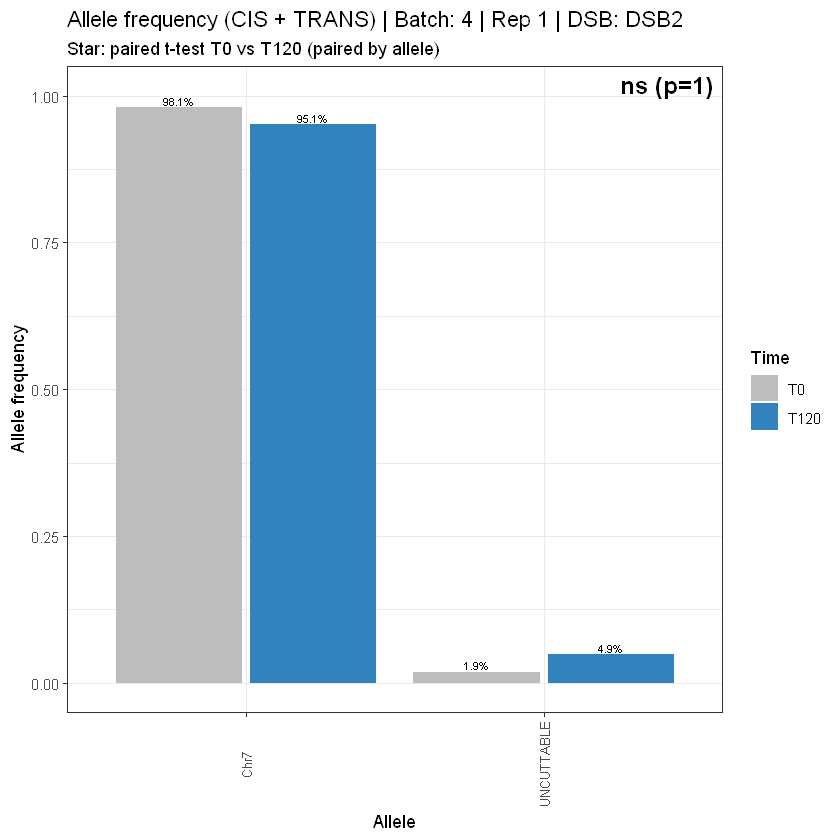

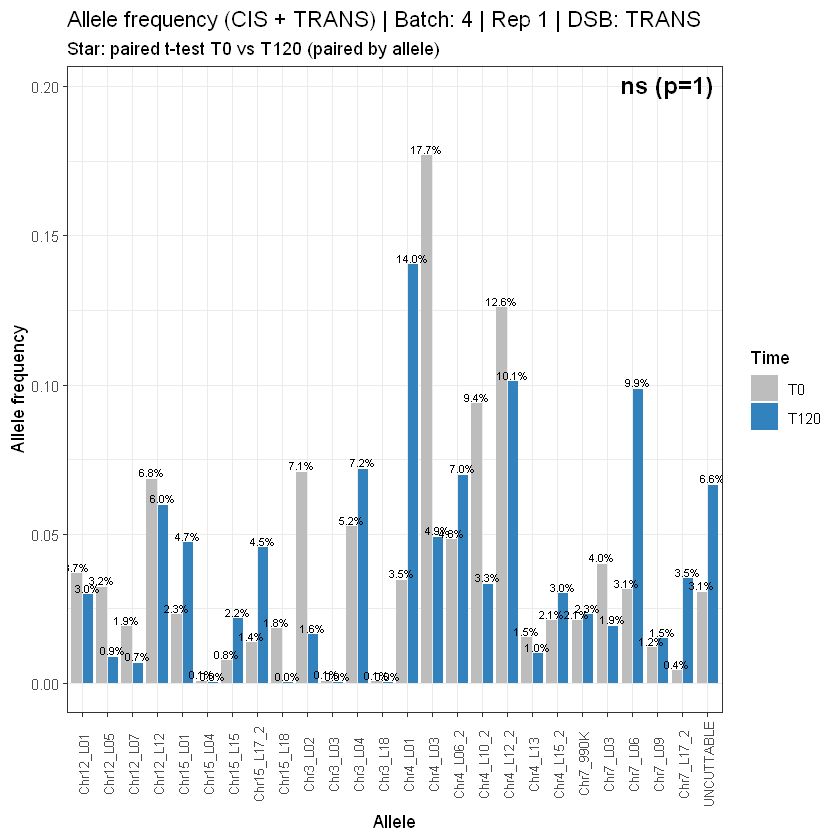

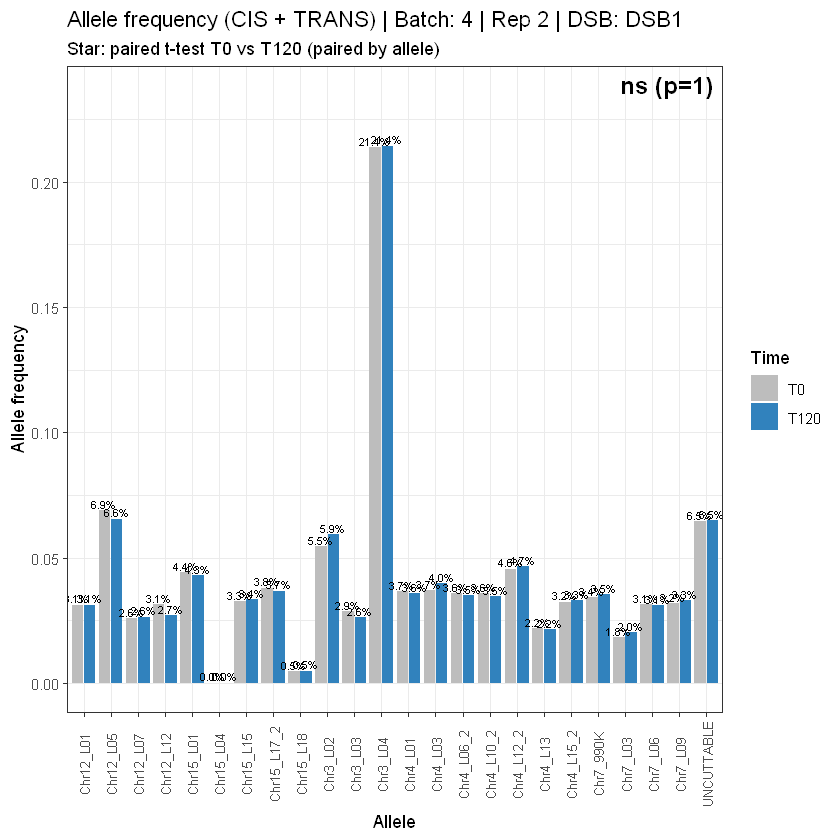

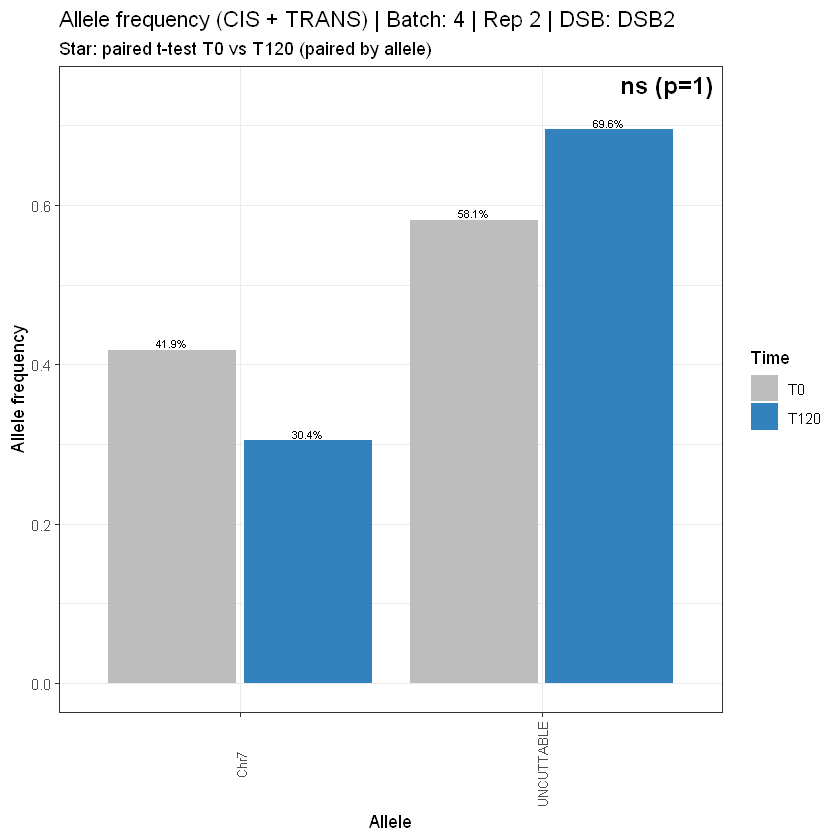

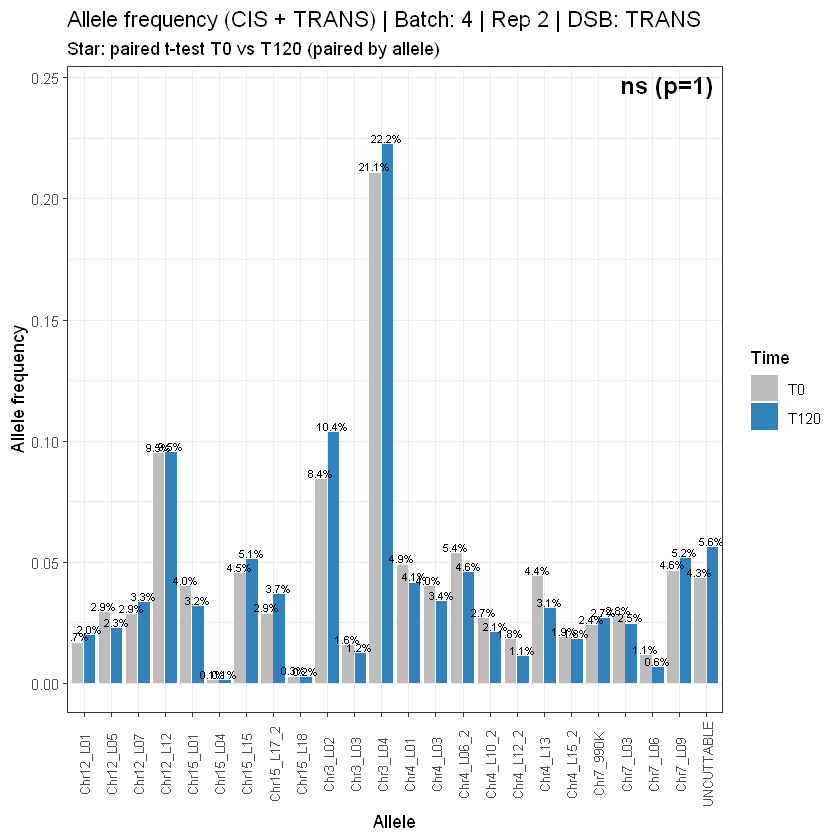

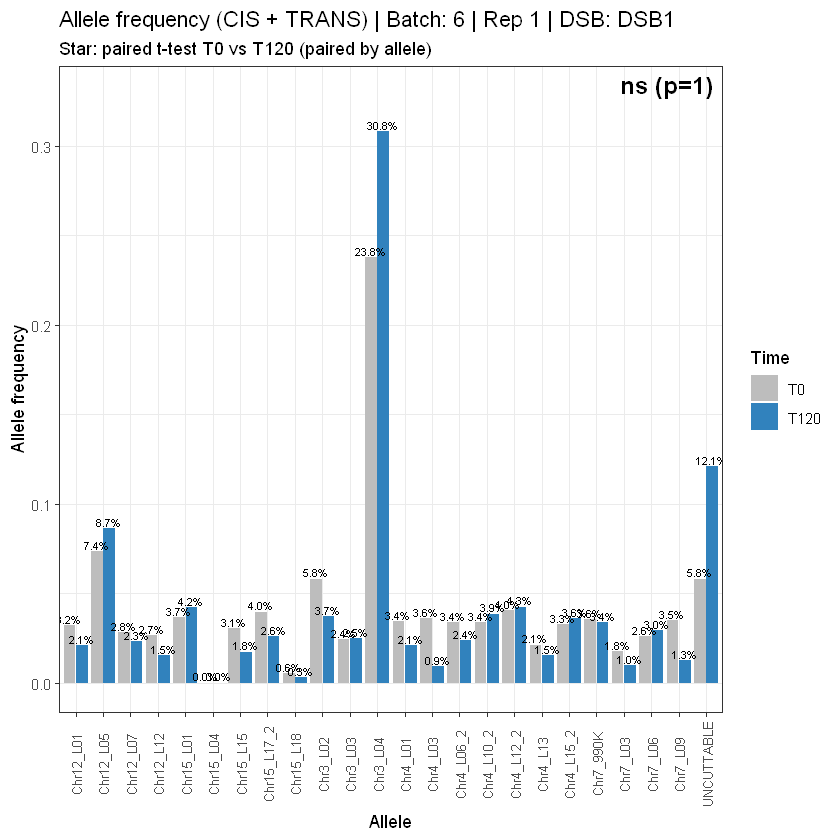

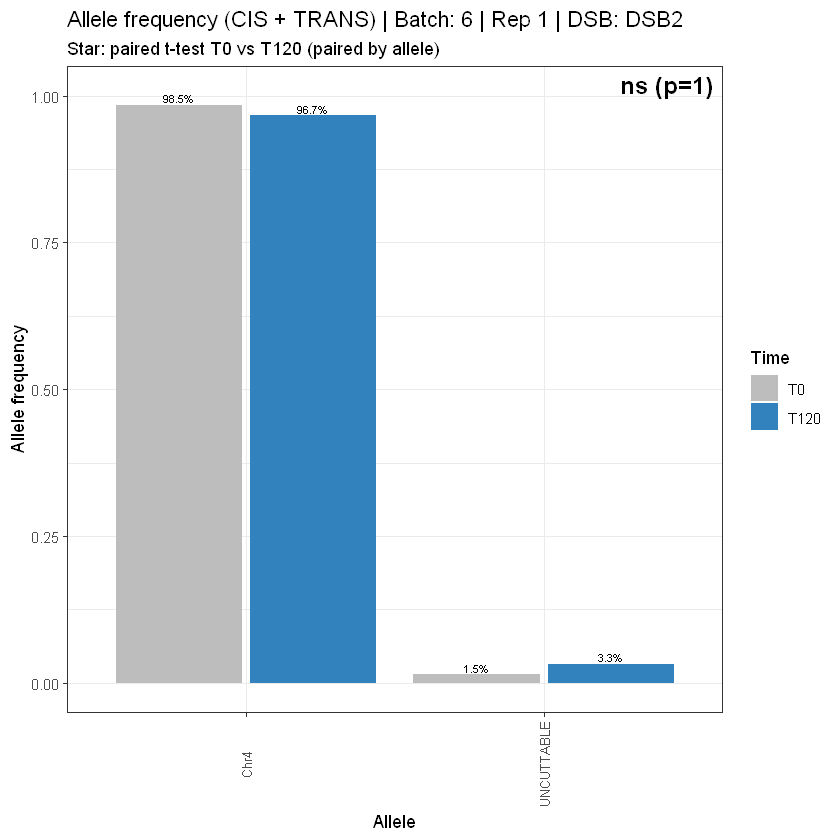

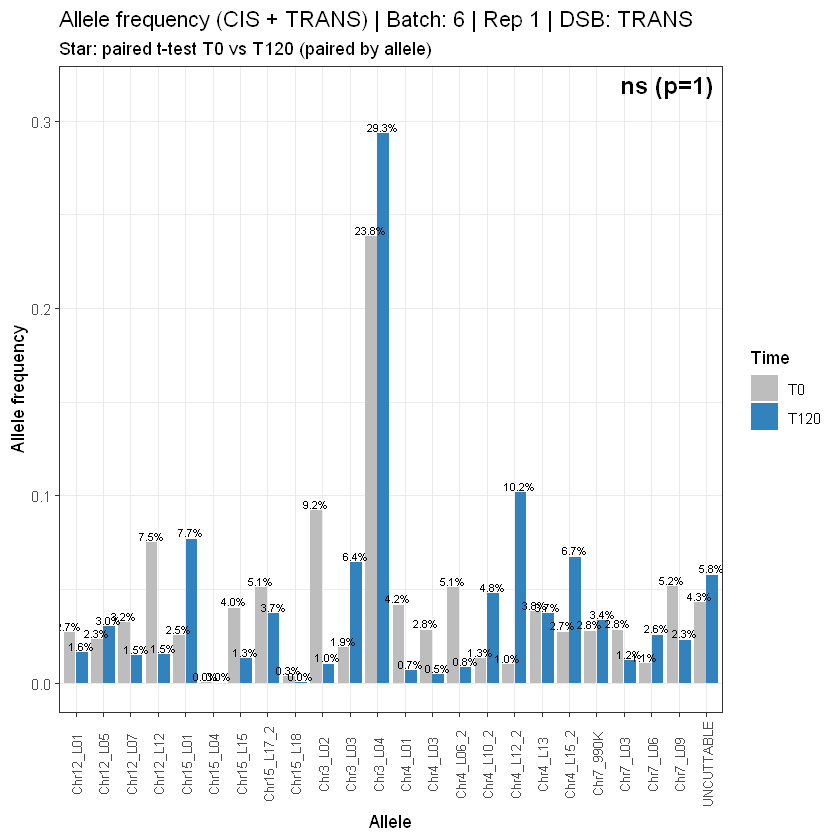

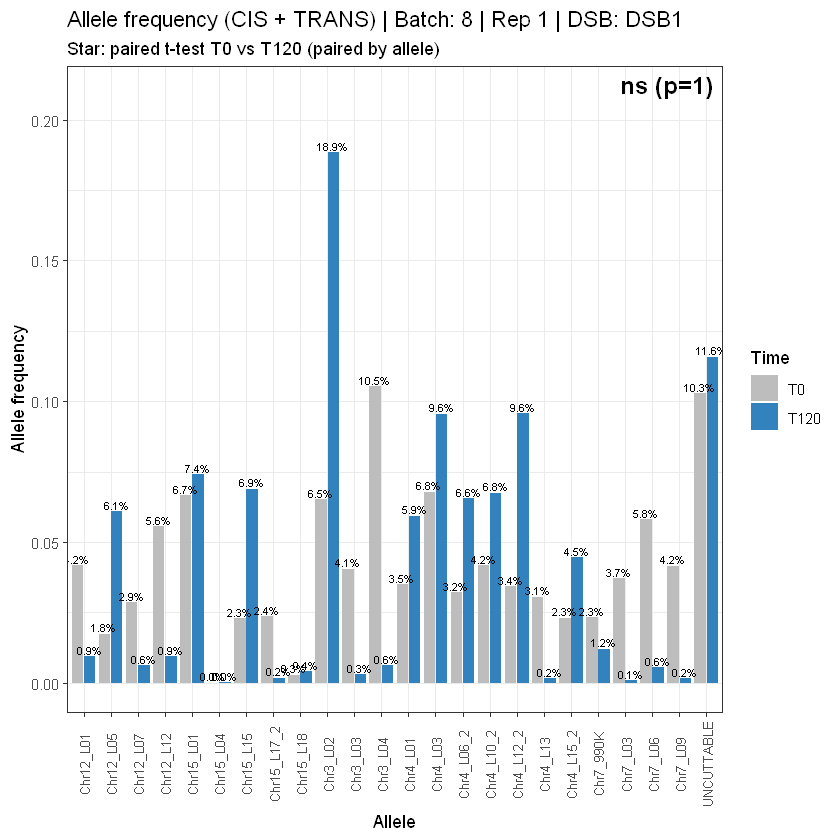

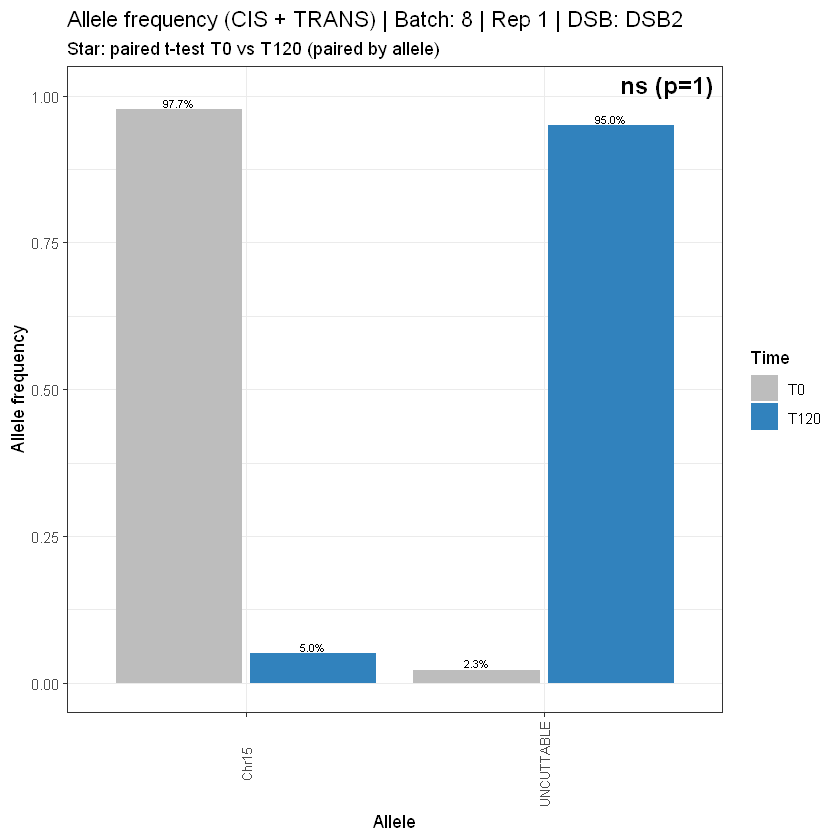

`geom_smooth()` using formula = 'y ~ x'


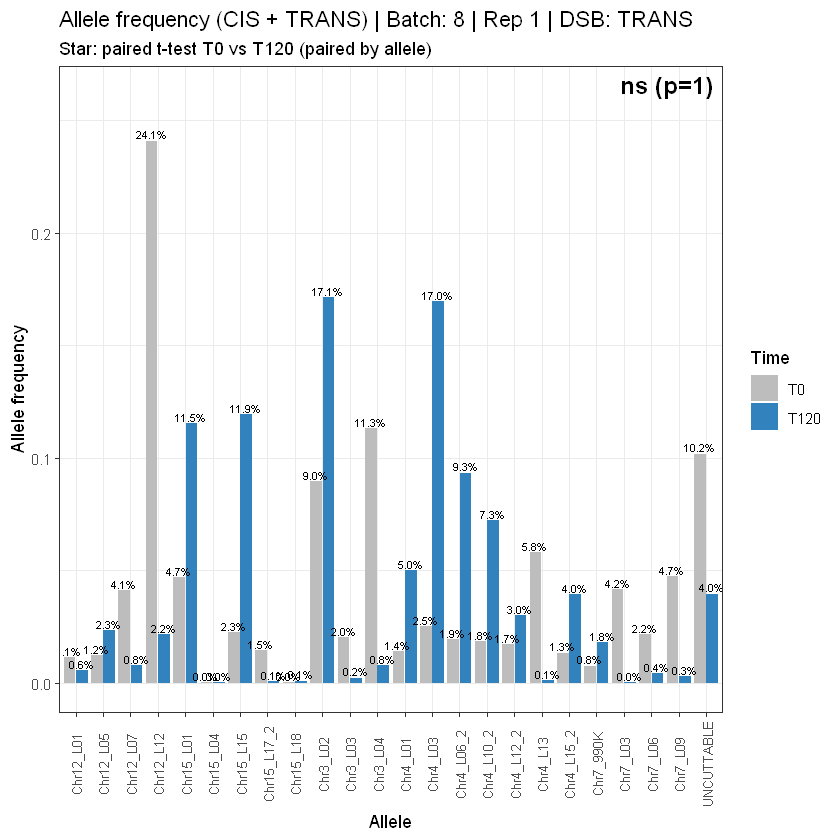

`geom_smooth()` using formula = 'y ~ x'


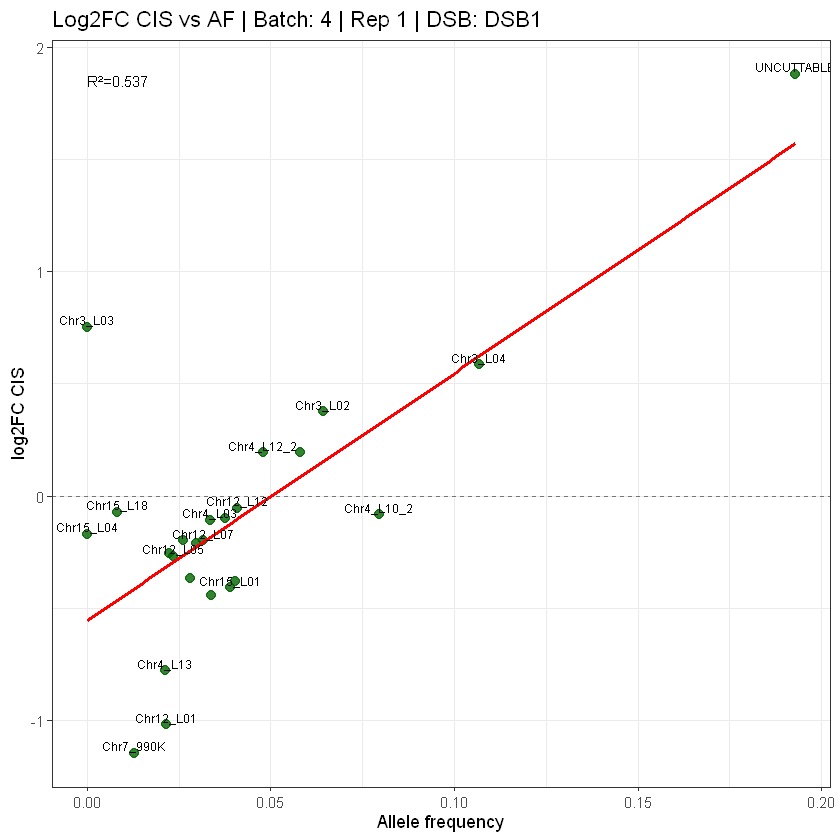

`geom_smooth()` using formula = 'y ~ x'


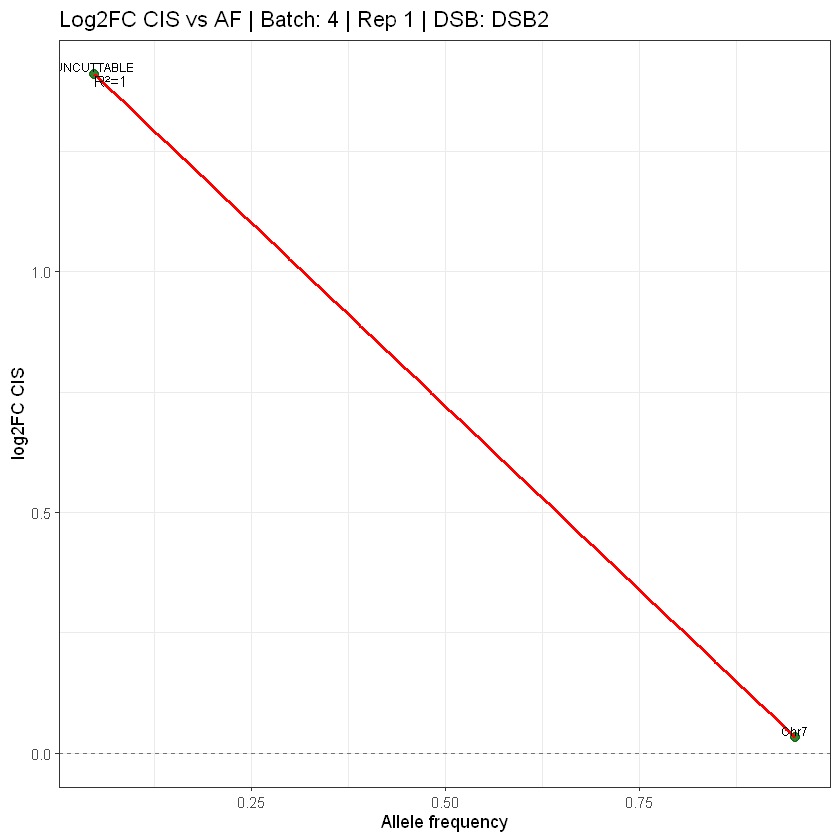

`geom_smooth()` using formula = 'y ~ x'


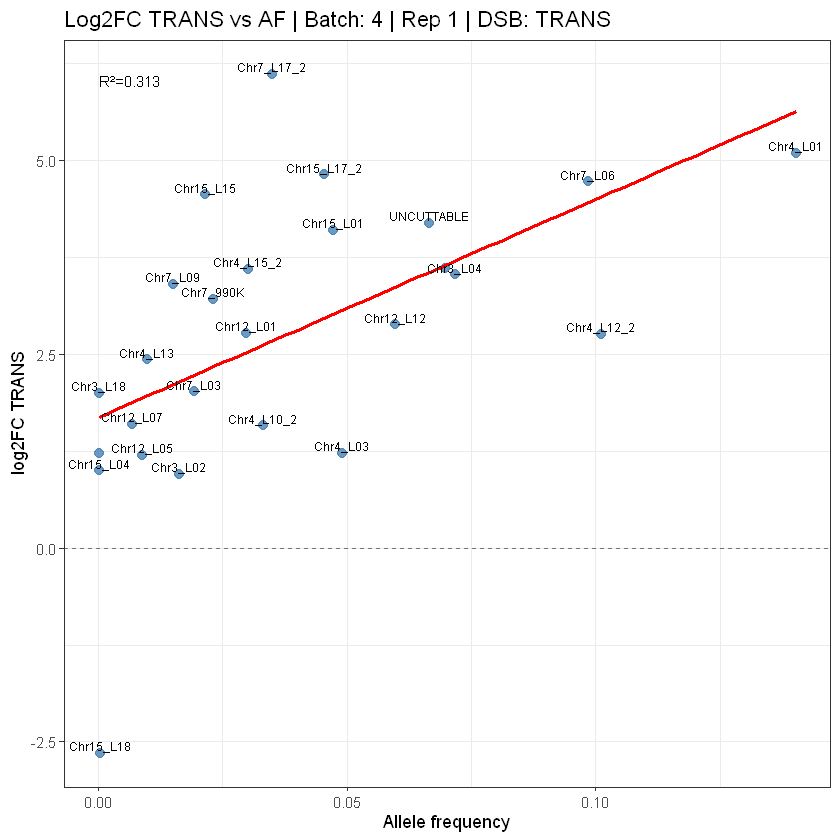

`geom_smooth()` using formula = 'y ~ x'


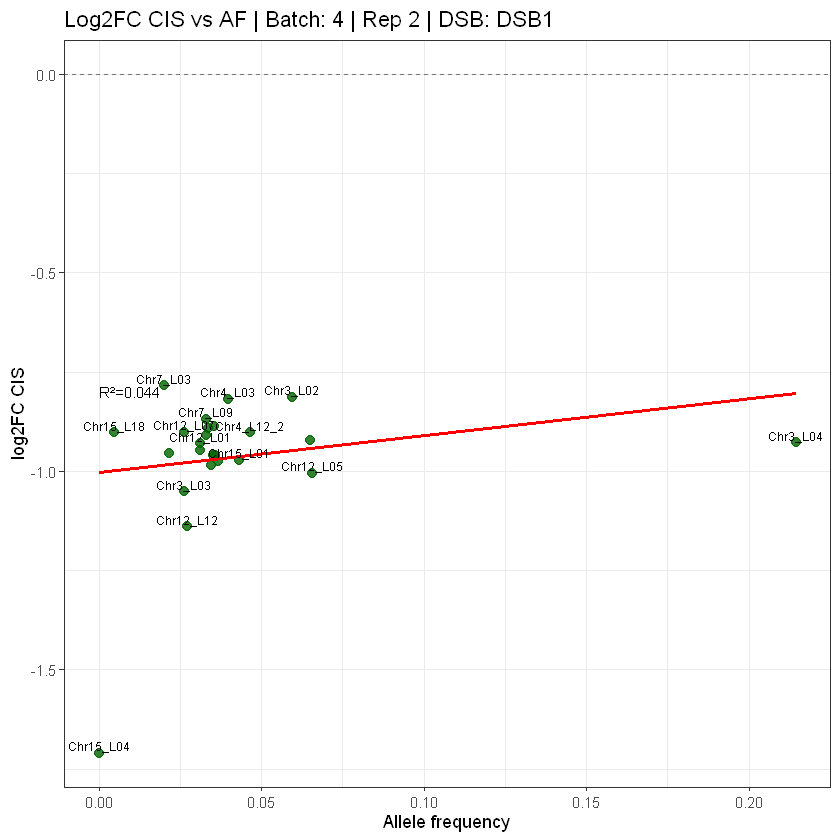

`geom_smooth()` using formula = 'y ~ x'


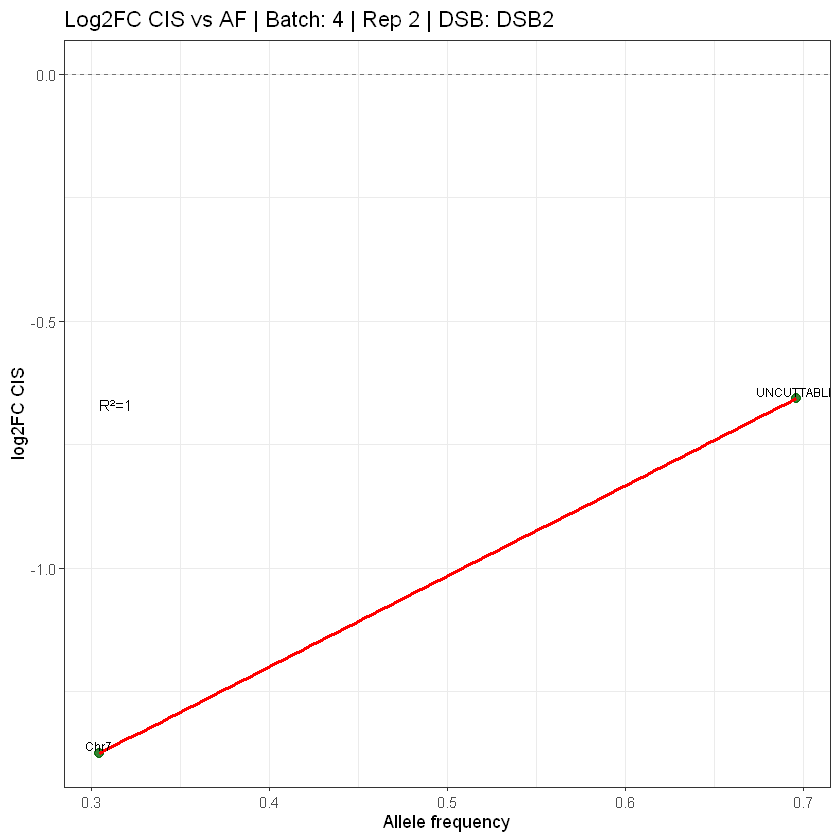

`geom_smooth()` using formula = 'y ~ x'


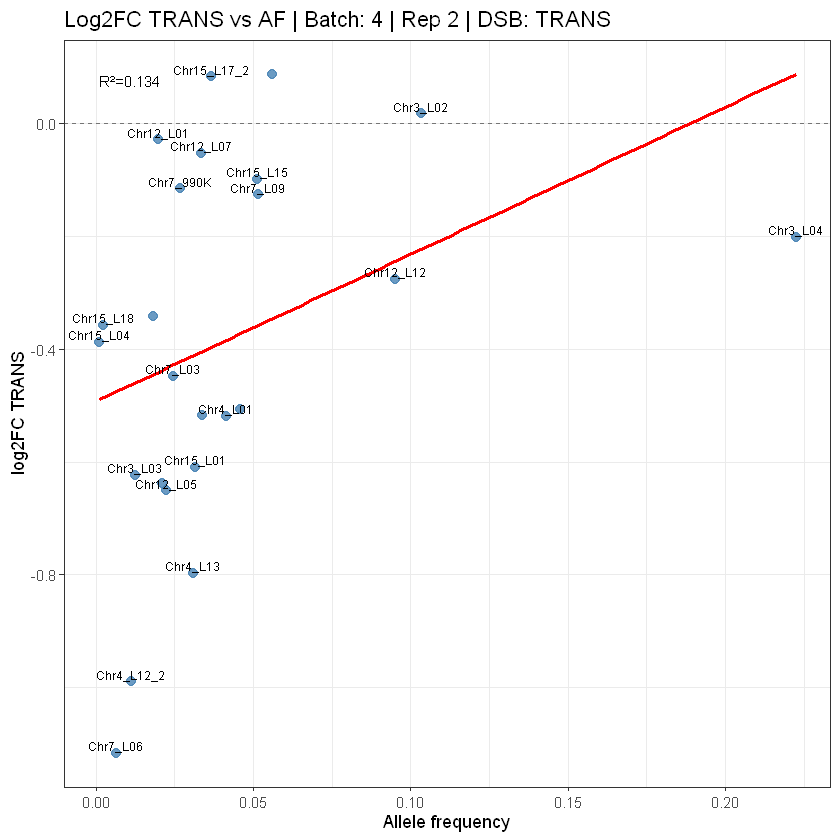

`geom_smooth()` using formula = 'y ~ x'


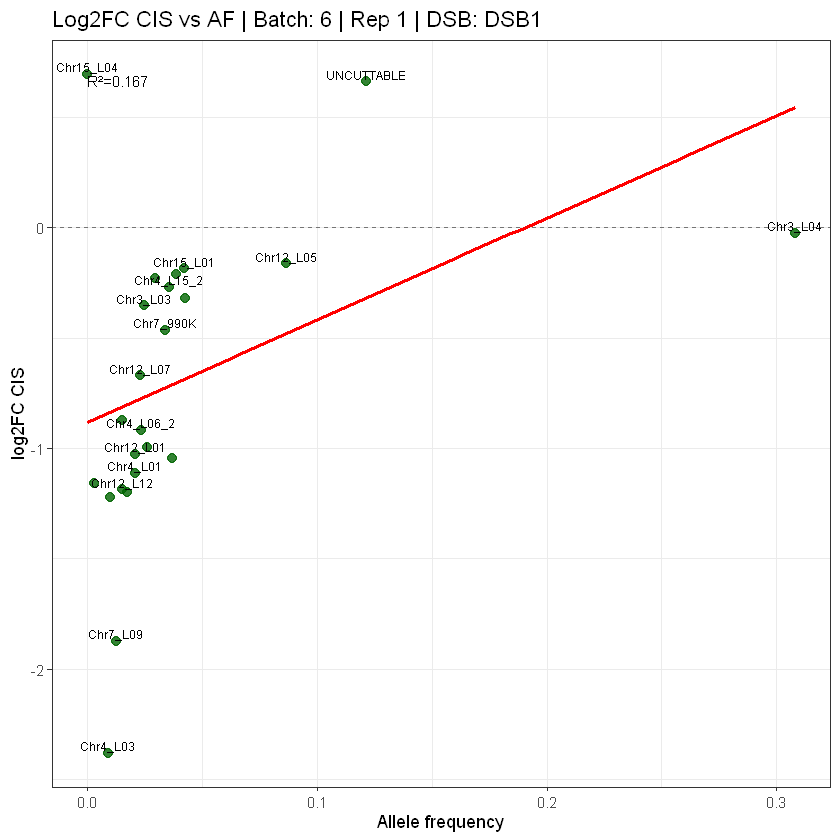

`geom_smooth()` using formula = 'y ~ x'


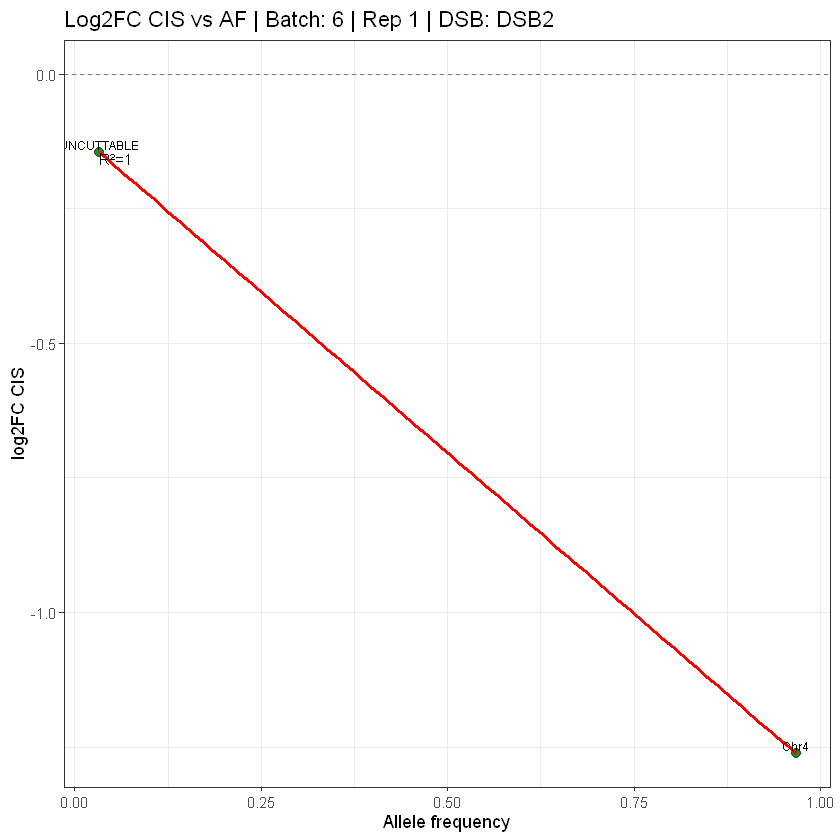

`geom_smooth()` using formula = 'y ~ x'


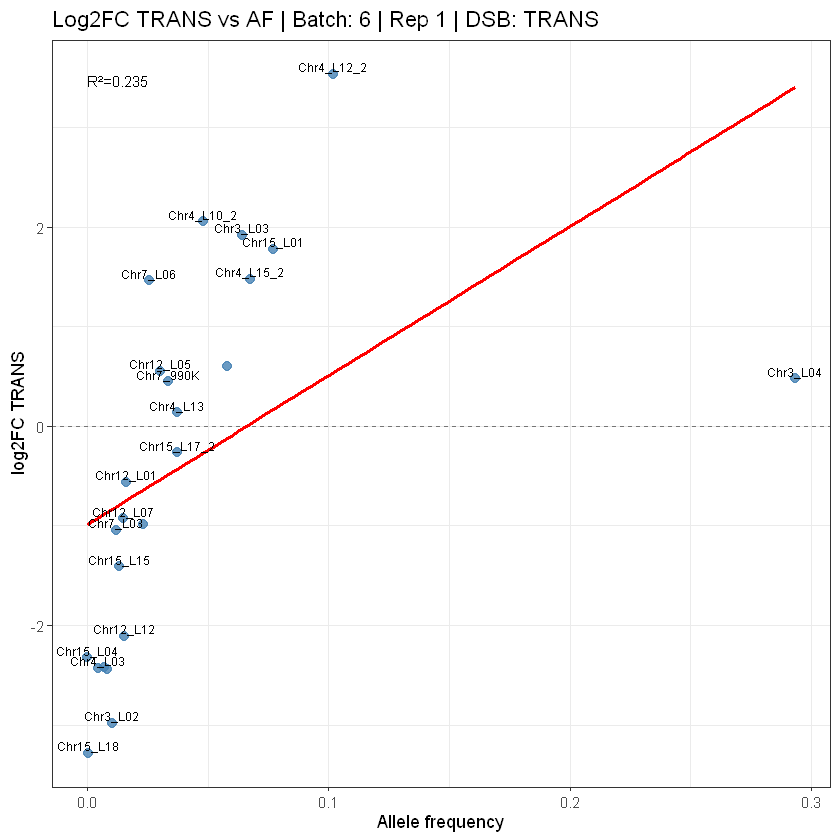

`geom_smooth()` using formula = 'y ~ x'


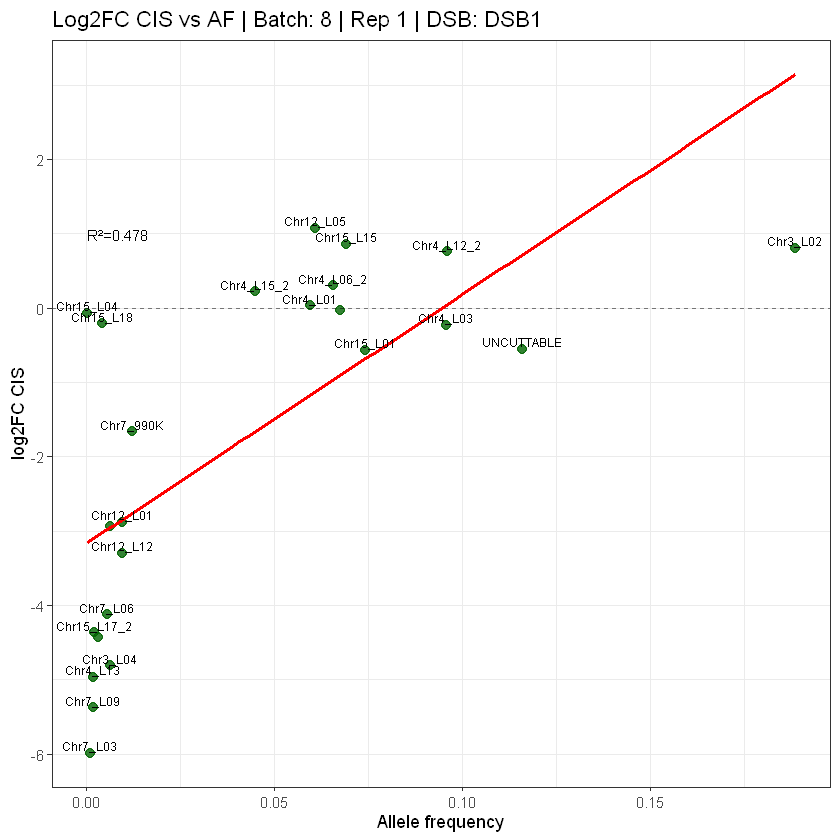

`geom_smooth()` using formula = 'y ~ x'


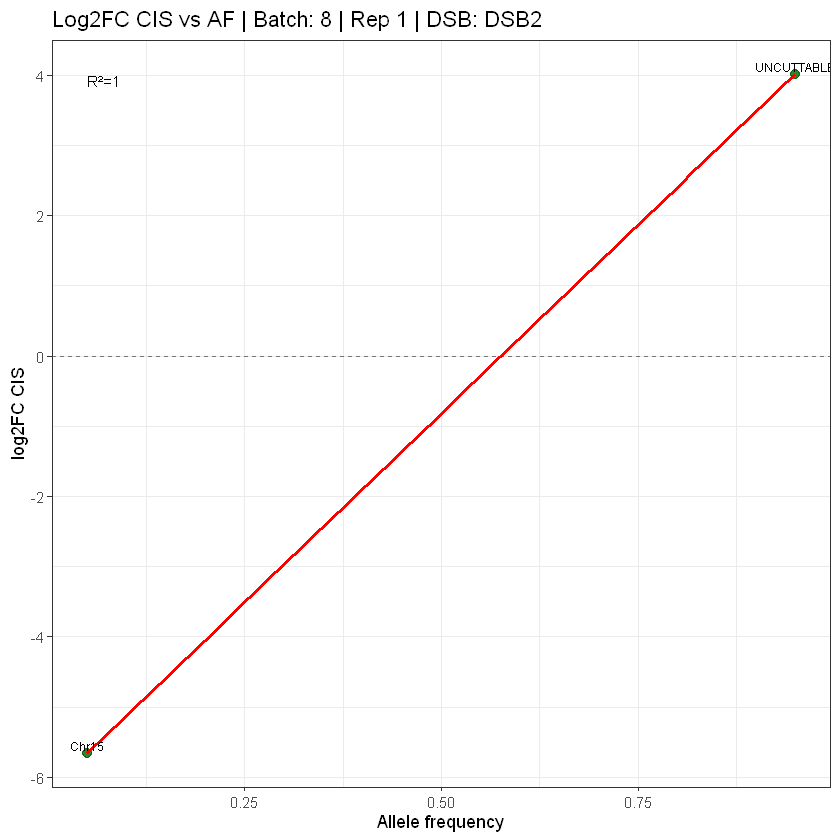

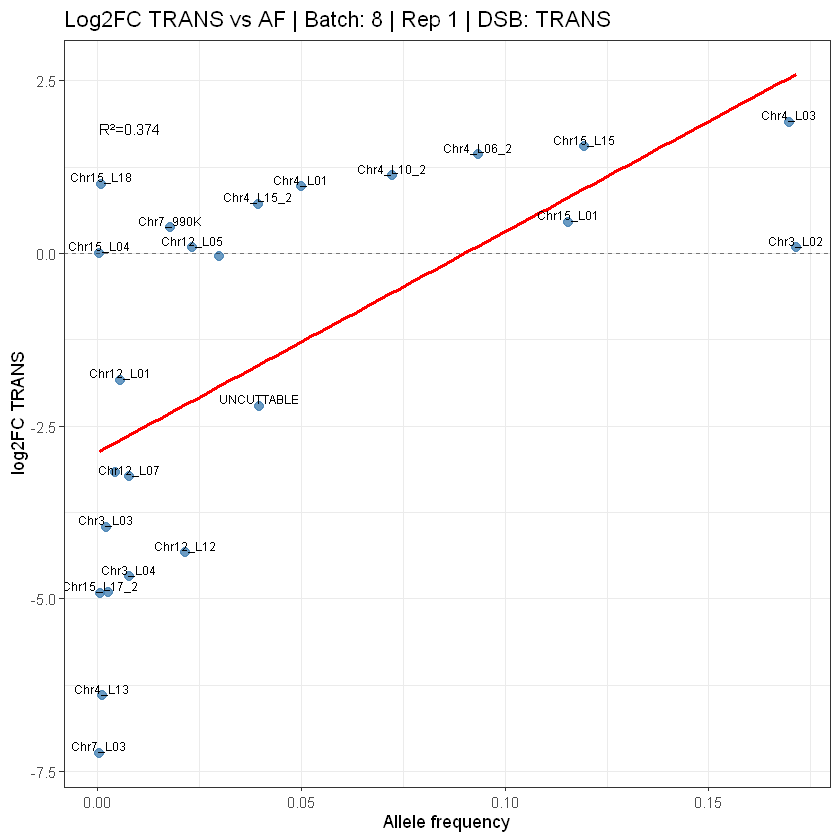

In [52]:
# ---- Sections 7, 8, 9: contribution bars, FC bars, and log2FC-vs-AF scatters (cleaned) ----
# (Keep these helpers local so the section is robust if run out-of-order.)
if (!exists('sig_stars')) {
  sig_stars <- function(p) {
    dplyr::case_when(
      is.na(p) ~ 'ns',
      p < 0.001 ~ '***',
      p < 0.01 ~ '**',
      p < 0.05 ~ '*',
      TRUE ~ 'ns'
    )
  }
}

as_time_label <- function(tp) factor(tp, levels = c(0, 120), labels = c('T0', 'T120'))
if (!exists('TIME_COLORS')) TIME_COLORS <- c('T0' = '#bdbdbd', 'T120' = '#3182bd')

# Helper: make a significance label string
.make_sig_label <- function(sig, pval) {
  if (sig != 'ns') return(sig)
  if (is.na(pval)) return('ns')
  paste0('ns (p=', signif(pval, 2), ')')
}

paired_ttest_across_alleles <- function(df, value_col) {
  # Some plots facet by batch/replicate but show a single shared subtitle;
  # in those cases, the same allele x time_point can appear multiple times.
  # Collapse duplicates to a single numeric value before widening.
  df_wide <- df %>%
    select(allele, time_point, value = all_of(value_col)) %>%
    filter(time_point %in% c(0, 120), is.finite(value)) %>%
    mutate(time_point = as.integer(time_point)) %>%
    group_by(allele, time_point) %>%
    summarise(value = mean(value, na.rm = TRUE), .groups = 'drop') %>%
    tidyr::pivot_wider(names_from = time_point, values_from = value)

  if (nrow(df_wide) == 0 || !all(c('0', '120') %in% names(df_wide))) {
    return(list(n_pairs = 0L, p_value = NA_real_, significance = 'ns'))
  }

  df_wide <- df_wide %>% filter(is.finite(`0`), is.finite(`120`))
  n_pairs <- nrow(df_wide)
  p_val <- NA_real_

  if (n_pairs >= 2) {
    tt <- tryCatch(t.test(df_wide$`120`, df_wide$`0`, paired = TRUE), error = function(e) NULL)
    if (!is.null(tt)) p_val <- as.numeric(tt$p.value)
  }

  list(n_pairs = n_pairs, p_value = p_val, significance = sig_stars(p_val))
}

dsb_plot_levels <- function(x) {
  x <- unique(as.character(x))
  preferred <- c('DSB1', 'DSB2', 'TRANS')
  c(intersect(preferred, x), setdiff(sort(x), preferred))
}

plot_cis_contrib_by_batch <- function(df_cis_dist) {
  keys <- df_cis_dist %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_cis_dist %>%
      filter(batch == b, replicate == r, is.finite(Percent_Location_in_Cis))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      ymax <- suppressWarnings(max(df_d$Percent_Location_in_Cis, na.rm = TRUE))
      y_upper <- if (is.finite(ymax)) pmin(110, ymax + max(4, 0.06 * ymax) + 2) else 110

      tt <- paired_ttest_across_alleles(df_d, 'Percent_Location_in_Cis')
      sub_txt <- paste0(
        'Timepoints shown as color (T0 vs T120). Paired t-test across alleles: ',
        .make_sig_label(tt$significance, tt$p_value),
        ' | n=', tt$n_pairs
      )

      p <- ggplot(df_d, aes(x = allele, y = Percent_Location_in_Cis, fill = as_time_label(time_point))) +
        geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
        geom_text(
          aes(label = if_else(is.na(Percent_Location_in_Cis), NA_character_, paste0(round(Percent_Location_in_Cis, 1), '%'))),
          position = position_dodge(width = 0.9),
          vjust = -0.25,
          size = 2.4
        ) +
        scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
        coord_cartesian(ylim = c(0, y_upper)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('CIS% contribution by allele (within CIS only) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = sub_txt,
          x = 'Allele', y = 'CIS% of CIS total',
          fill = 'Time'
        )
      print(p)
    }
  }
}

plot_trans_contrib_by_batch <- function(df_trans_dist) {
  keys <- df_trans_dist %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_trans_dist %>%
      filter(batch == b, replicate == r, is.finite(Percent_Location_in_Trans))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      ymax <- suppressWarnings(max(df_d$Percent_Location_in_Trans, na.rm = TRUE))
      y_upper <- if (is.finite(ymax)) pmin(110, ymax + max(4, 0.06 * ymax) + 2) else 110

      tt <- paired_ttest_across_alleles(df_d, 'Percent_Location_in_Trans')
      sub_txt <- paste0(
        'Timepoints shown as color (T0 vs T120). Paired t-test across alleles: ',
        .make_sig_label(tt$significance, tt$p_value),
        ' | n=', tt$n_pairs
      )

      p <- ggplot(df_d, aes(x = allele, y = Percent_Location_in_Trans, fill = as_time_label(time_point))) +
        geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
        geom_text(
          aes(label = if_else(is.na(Percent_Location_in_Trans), NA_character_, paste0(round(Percent_Location_in_Trans, 1), '%'))),
          position = position_dodge(width = 0.9),
          vjust = -0.25,
          size = 2.4
        ) +
        scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
        coord_cartesian(ylim = c(0, y_upper)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('TRANS% contribution by allele (within TRANS only) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = sub_txt,
          x = 'Allele', y = 'TRANS% of TRANS total',
          fill = 'Time'
        )
      print(p)
    }
  }
}

plot_trans_percent_by_combo <- function(dat, combo_name) {
  df_plot <- dat %>%
    filter(combo == combo_name, time_point %in% c(0, 120)) %>%
    group_by(batch, replicate, time_point, DSB, allele) %>%
    summarise(Trans_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(batch, replicate, time_point, DSB) %>%
    mutate(
      Total_Trans = sum(Trans_Counts, na.rm = TRUE),
      Percent_Trans = if_else(Total_Trans > 0, 100 * Trans_Counts / Total_Trans, NA_real_)
    ) %>%
    ungroup() %>%
    filter(is.finite(Percent_Trans))

  if (nrow(df_plot) == 0) return(list())

  out <- list()
  for (d in dsb_plot_levels(df_plot$DSB)) {
    df_d <- df_plot %>% filter(DSB == d)
    if (nrow(df_d) == 0) next

    ymax <- suppressWarnings(max(df_d$Percent_Trans, na.rm = TRUE))
    y_upper <- if (is.finite(ymax)) pmin(110, ymax + max(4, 0.06 * ymax) + 2) else 110

    tt <- paired_ttest_across_alleles(df_d, 'Percent_Trans')
    sub_txt <- paste0(
      'Paired t-test across alleles (T0 vs T120): ',
      .make_sig_label(tt$significance, tt$p_value),
      ' | n=', tt$n_pairs
    )

    p <- ggplot(df_d, aes(x = allele, y = Percent_Trans, fill = as_time_label(time_point))) +
      geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
      geom_text(
        aes(label = if_else(is.na(Percent_Trans) | Percent_Trans <= 0, NA_character_, paste0(round(Percent_Trans, 1), '%'))),
        position = position_dodge(width = 0.9),
        vjust = -0.25,
        size = 2.2
      ) +
      facet_grid(batch + replicate ~ ., scales = 'free_x') +
      scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
      coord_cartesian(ylim = c(0, y_upper)) +
      theme_bw(base_size = 10) +
      theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 7)) +
      labs(
        title = paste('Percent of', combo_name, 'counts by allele (T0 vs T120) with replicate split | DSB:', d),
        subtitle = sub_txt,
        x = 'Allele', y = '% within combo', fill = 'Time'
      )

    out[[d]] <- p
  }

  out
}

plot_foldchange_cis_by_batch <- function(df_fc, ttest_fc = NULL) {
  out <- list()
  keys <- df_fc %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_fc %>% filter(batch == b, replicate == r, is.finite(FoldChange_Cis_120_vs_0))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      ymax <- suppressWarnings(max(df_d$FoldChange_Cis_120_vs_0, na.rm = TRUE))
      y_upper <- if (is.finite(ymax)) max(1, ymax + max(0.2, 0.06 * ymax)) else 1.5

      p <- ggplot(df_d, aes(x = allele, y = FoldChange_Cis_120_vs_0)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#008837') +
        geom_text(
          aes(label = if_else(is.na(FoldChange_Cis_120_vs_0), NA_character_, as.character(round(FoldChange_Cis_120_vs_0, 2)))),
          vjust = -0.25,
          size = 2.6
        ) +
        geom_hline(yintercept = 1, linetype = 'dashed', color = 'grey40', linewidth = 0.7) +
        coord_cartesian(ylim = c(0, y_upper)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('Fold change (120/0) in CIS counts | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Dashed line: FC = 1 | Star: one-sample t-test (H0: mean log2FC = 0)',
          x = 'Allele', y = 'Fold change (CIS)'
        )

      if (!is.null(ttest_fc)) {
        ann <- ttest_fc %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      nm <- gsub('[^A-Za-z0-9_]+', '_', paste0('batch_', b, '_', r, '_DSB_', d))
      out[[nm]] <- p
      print(p)
    }
  }
  out
}

plot_foldchange_trans_by_batch <- function(df_fc, ttest_fc = NULL) {
  out <- list()
  keys <- df_fc %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_fc %>% filter(batch == b, replicate == r, is.finite(FoldChange_Trans_120_vs_0))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      ymax <- suppressWarnings(max(df_d$FoldChange_Trans_120_vs_0, na.rm = TRUE))
      y_upper <- if (is.finite(ymax)) max(1, ymax + max(0.2, 0.06 * ymax)) else 1.5

      p <- ggplot(df_d, aes(x = allele, y = FoldChange_Trans_120_vs_0)) +
        geom_col(width = 0.85, na.rm = TRUE, fill = '#7b3294') +
        geom_text(
          aes(label = if_else(is.na(FoldChange_Trans_120_vs_0), NA_character_, as.character(round(FoldChange_Trans_120_vs_0, 2)))),
          vjust = -0.25,
          size = 2.6
        ) +
        geom_hline(yintercept = 1, linetype = 'dashed', color = 'grey40', linewidth = 0.7) +
        coord_cartesian(ylim = c(0, y_upper)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('Fold change (120/0) in TRANS counts | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Dashed line: FC = 1 | Star: one-sample t-test (H0: mean log2FC = 0)',
          x = 'Allele', y = 'Fold change (TRANS)'
        )

      if (!is.null(ttest_fc)) {
        ann <- ttest_fc %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      nm <- gsub('[^A-Za-z0-9_]+', '_', paste0('batch_', b, '_', r, '_DSB_', d))
      out[[nm]] <- p
      print(p)
    }
  }
  out
}

plot_allele_frequency_by_batch <- function(df_af, ttest_af = NULL) {
  keys <- df_af %>% distinct(batch, replicate) %>% arrange(batch, replicate)
  for (i in seq_len(nrow(keys))) {
    b <- keys$batch[[i]]
    r <- keys$replicate[[i]]

    df_plot <- df_af %>% filter(batch == b, replicate == r, is.finite(Allele_Frequency))
    if (nrow(df_plot) == 0) next

    for (d in dsb_plot_levels(df_plot$DSB)) {
      df_d <- df_plot %>% filter(DSB == d)
      if (nrow(df_d) == 0) next

      ymax <- suppressWarnings(max(df_d$Allele_Frequency, na.rm = TRUE))
      y_upper <- if (is.finite(ymax)) pmin(1, ymax + max(0.02, 0.06 * ymax)) else 1

      p <- ggplot(df_d, aes(x = allele, y = Allele_Frequency, fill = as_time_label(time_point))) +
        geom_col(position = position_dodge(width = 0.9), width = 0.85, na.rm = TRUE) +
        geom_text(
          aes(label = if_else(is.na(Allele_Frequency), NA_character_, scales::percent(Allele_Frequency, accuracy = 0.1))),
          position = position_dodge(width = 0.9),
          vjust = -0.25,
          size = 2.4
        ) +
        scale_fill_manual(values = TIME_COLORS, drop = FALSE) +
        coord_cartesian(ylim = c(0, y_upper)) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0.5, vjust = 0.5, size = 8)) +
        labs(
          title = paste0('Allele frequency (CIS + TRANS) | Batch: ', b, ' | ', r, ' | DSB: ', d),
          subtitle = 'Star: paired t-test T0 vs T120 (paired by allele)',
          x = 'Allele', y = 'Allele frequency', fill = 'Time'
        )

      if (!is.null(ttest_af)) {
        ann <- ttest_af %>% filter(batch == b, replicate == r, DSB == d)
        if (nrow(ann) > 0) {
          lbl <- .make_sig_label(ann$significance[[1]], ann$p_value[[1]])
          p <- p + annotate('text', x = Inf, y = Inf, label = lbl,
                            hjust = 1.1, vjust = 1.5, size = 5, fontface = 'bold')
        }
      }
      print(p)
    }
  }
}

safe_lm_r2 <- function(df, x_col, y_col) {
  df2 <- df %>% filter(is.finite(.data[[x_col]]), is.finite(.data[[y_col]]))
  if (nrow(df2) < 2) return(NA_real_)
  fit <- tryCatch(stats::lm(stats::as.formula(paste0(y_col, ' ~ ', x_col)), data = df2), error = function(e) NULL)
  if (is.null(fit)) return(NA_real_)
  tryCatch(summary(fit)$r.squared, error = function(e) NA_real_)
}

plot_correlation_cis <- function(df, batch_name, replicate_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, replicate == replicate_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_CIS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  r2 <- safe_lm_r2(df_plot, 'Allele_Frequency', 'log2FC_CIS')
  ann <- tibble::tibble(
    x = min(df_plot$Allele_Frequency, na.rm = TRUE),
    y = max(df_plot$log2FC_CIS, na.rm = TRUE),
    label = if_else(is.finite(r2), paste0('R²=', round(r2, 3)), 'R²=NA')
  )

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_CIS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'darkgreen') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_CIS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    geom_text(data = ann, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3.1) +
    theme_bw(base_size = 11) +
    labs(
      title = paste0('Log2FC CIS vs AF | Batch: ', batch_name, ' | ', replicate_name, ' | DSB: ', dsb_name),
      x = 'Allele frequency',
      y = 'log2FC CIS'
    )

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

plot_correlation_trans <- function(df, batch_name, replicate_name, dsb_name) {
  df_plot <- df %>%
    filter(batch == batch_name, replicate == replicate_name, DSB == dsb_name) %>%
    mutate(valid = is.finite(Allele_Frequency) & is.finite(log2FC_TRANS)) %>%
    filter(valid)

  if (nrow(df_plot) < 2) return(NULL)

  r2 <- safe_lm_r2(df_plot, 'Allele_Frequency', 'log2FC_TRANS')
  ann <- tibble::tibble(
    x = min(df_plot$Allele_Frequency, na.rm = TRUE),
    y = max(df_plot$log2FC_TRANS, na.rm = TRUE),
    label = if_else(is.finite(r2), paste0('R²=', round(r2, 3)), 'R²=NA')
  )

  p <- ggplot(df_plot, aes(x = Allele_Frequency, y = log2FC_TRANS)) +
    geom_point(size = 2.4, alpha = 0.8, color = 'steelblue') +
    geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
    geom_smooth(aes(x = Allele_Frequency, y = log2FC_TRANS), method = 'lm', se = FALSE, color = 'red', inherit.aes = FALSE) +
    geom_text(data = ann, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 0, vjust = 1, size = 3.1) +
    theme_bw(base_size = 11) +
    labs(
      title = paste0('Log2FC TRANS vs AF | Batch: ', batch_name, ' | ', replicate_name, ' | DSB: ', dsb_name),
      x = 'Allele frequency',
      y = 'log2FC TRANS'
    )

  if (has_ggrepel) {
    p <- p + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
  } else {
    p <- p + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
  }
  p
}

# Run section 7 plots

df_cis_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Percent_Location_in_Cis)

df_trans_dist <- dat_norm_combo %>%
  filter(time_point %in% c(0, 120)) %>%
  select(batch, replicate, time_point, DSB, allele, Percent_Location_in_Trans)

plot_cis_contrib_by_batch(df_cis_dist)
plot_trans_contrib_by_batch(df_trans_dist)

p_trans_ad_list <- plot_trans_percent_by_combo(dat_focus, 'A_to_D')
if (length(p_trans_ad_list) > 0) purrr::walk(p_trans_ad_list, print)

p_trans_cb_list <- plot_trans_percent_by_combo(dat_focus, 'C_to_B')
if (length(p_trans_cb_list) > 0) purrr::walk(p_trans_cb_list, print)

# Backward-compatible single objects for downstream references
p_trans_ad <- if (length(p_trans_ad_list) > 0) p_trans_ad_list[[1]] else NULL
p_trans_cb <- if (length(p_trans_cb_list) > 0) p_trans_cb_list[[1]] else NULL

# Run section 8 plots — pass t-test tables for significance annotations
p_fc_cis_list <- plot_foldchange_cis_by_batch(dat_fc_cis, ttest_fc = ttest_log2fc_cis)
p_fc_trans_list <- plot_foldchange_trans_by_batch(dat_fc_trans, ttest_fc = ttest_log2fc_trans)
ttest_af_for_plot <- if (exists('ttest_af_t0_t120')) ttest_af_t0_t120 else if (exists('af_ttest')) af_ttest else NULL
plot_allele_frequency_by_batch(dat_allele_freq, ttest_af = ttest_af_for_plot)

# Run section 9 plots
plot_keys <- dat_fc_af %>% distinct(batch, replicate, DSB) %>% arrange(batch, replicate, DSB)

for (i in seq_len(nrow(plot_keys))) {
  b <- plot_keys$batch[[i]]
  r <- plot_keys$replicate[[i]]
  d <- plot_keys$DSB[[i]]
  p_cis_scatter <- plot_correlation_cis(dat_fc_af, b, r, d)
  p_trans_scatter <- plot_correlation_trans(dat_fc_af, b, r, d)
  if (!is.null(p_cis_scatter)) print(p_cis_scatter)
  if (!is.null(p_trans_scatter)) print(p_trans_scatter)
}


**Figure set (Sections 7–9). Allele contribution, fold-change bars, and log2FC-vs-AF diagnostics.**

- **Methods/Computation:** Per-allele contribution bars report normalized channel fractions, and abundance-shift diagnostics model trend lines via linear fit $\hat{y}=\beta_0+\beta_1 x$ with $x=\mathrm{AF}$ and $y=\log_2\mathrm{FC}$.
- **Biological relevance (with sources):** A strong positive $\beta_1$ implies abundance-linked shifts, while weak slope with outlier loci supports selective, structure-dependent partner-choice effects in damaged nuclei [1,2,7].

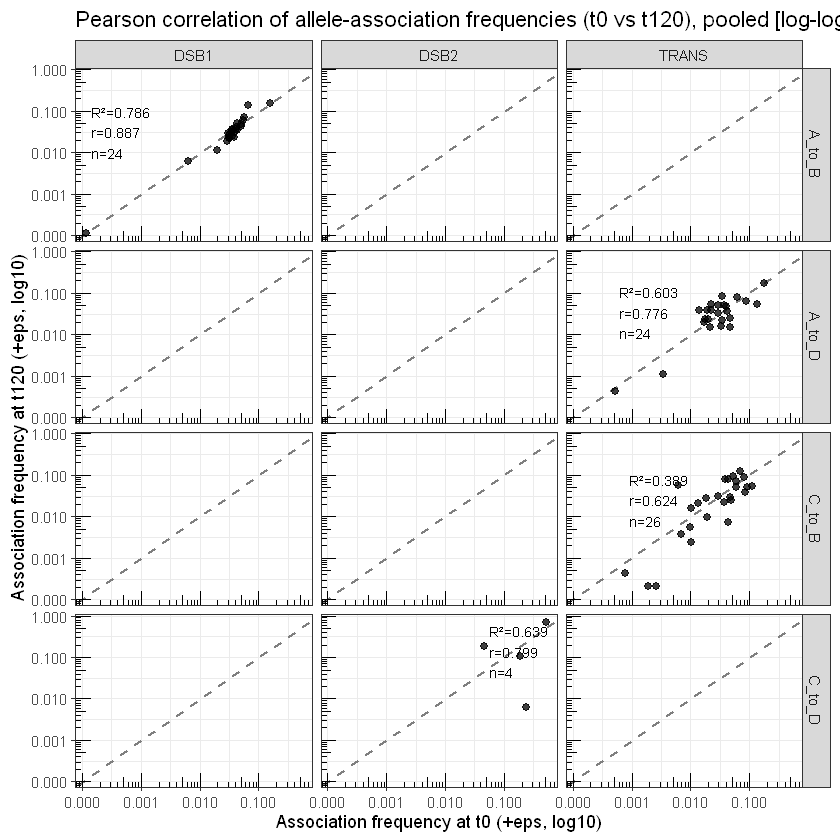

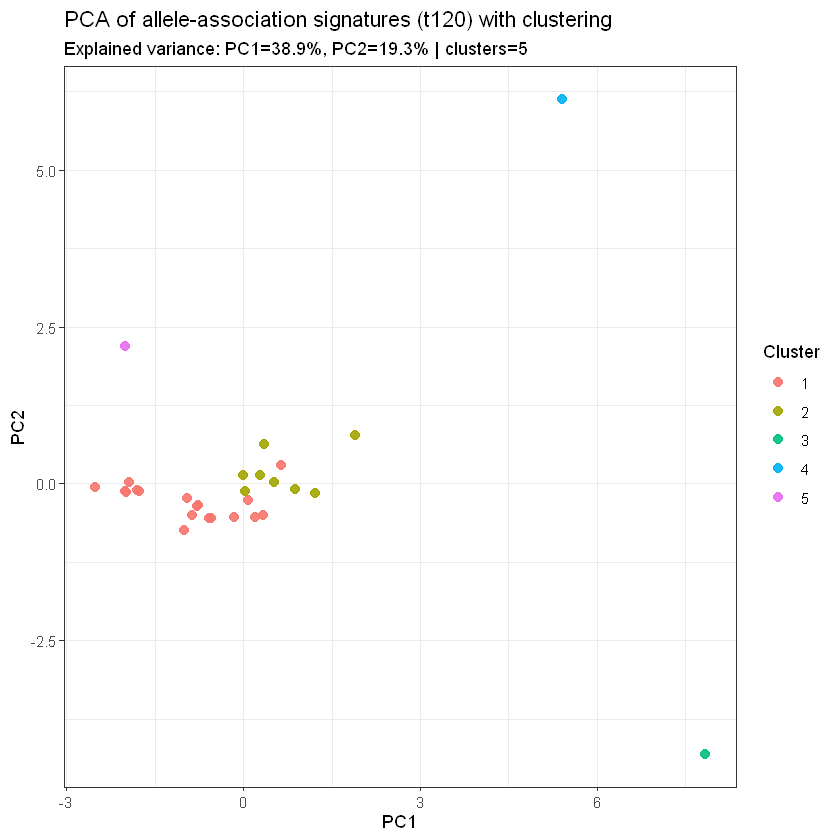

Exporting 13 plots: 3C_QC_total_counts, 3C_group4_trans_share, 3C_group4_cis_share, 3C_group4_within_cis, 3C_group4_within_trans, 3C_af_corr_pooled_t0_t120, 3C_af_corr_pooled_t0_t120_loglog, 3C_pca_allele_signatures, 3C_allele_association_heatmap, 3C_trans_combo_A_to_D, 3C_trans_combo_C_to_B, 3C_trans_combo_A_to_D_TRANS, 3C_trans_combo_C_to_B_TRANS

Warning message:
"Removed 10 rows containing missing values or values outside the scale range
(`geom_text()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range
(`geom_text()`)."
Saved advanced plots to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



object,n_rows
<chr>,<int>
dat_raw,596
dat_focus,596
dat_norm_combo,404
dat_group4,8
dat_allele_freq,404
dat_fc_cis,202
dat_fc_trans,202
dat_fc_af,202
cor_summary,12


PCA cluster sizes:



  cluster n_alleles
1       1        18
2       2         8
3       3         1
4       4         1
5       5         1


Detected TAD-like domains (top 15 rows):



# A tibble: 15 × 2
   allele     tad_like_domain
   <chr>      <chr>          
 1 UNCUTTABLE Domain_3       
 2 Chr7       Domain_4       
 3 Chr4       Domain_5       
 4 Chr3_L04   Domain_2       
 5 Chr3_L02   Domain_1       
 6 Chr4_L03   Domain_1       
 7 Chr15_L15  Domain_1       
 8 Chr4_L06_2 Domain_1       
 9 Chr4_L12_2 Domain_1       
10 Chr12_L05  Domain_1       
11 Chr15_L01  Domain_1       
12 Chr4_L10_2 Domain_1       
13 Chr4_L15_2 Domain_1       
14 Chr4_L01   Domain_1       
15 Chr7_L06   Domain_1       


metric,na_fraction
<chr>,<dbl>
Log2FC_Cis_120_vs_0,0.4851485
Log2FC_Trans_120_vs_0,0.5148515
dat_fc_af$log2FC_CIS,0.4851485
dat_fc_af$log2FC_TRANS,0.5148515
dat_fc_af$Allele_Frequency,0.0000000


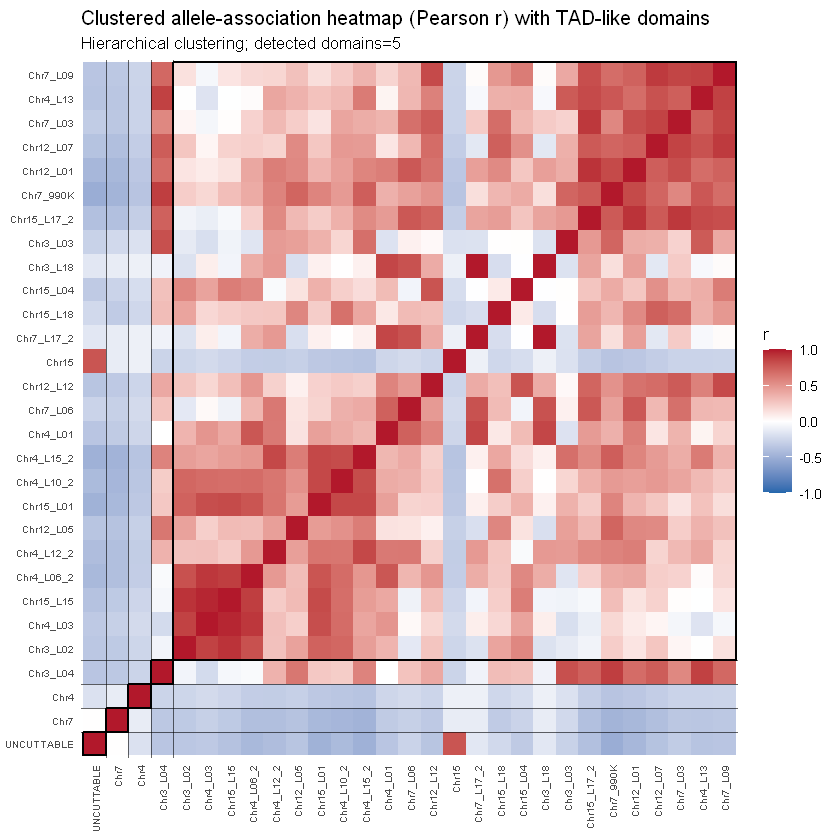

In [56]:
# ---- Advanced export + diagnostics ----
out_dir <- file.path(getwd(), 'Outputs', '3C')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Export t-test result tables if available
if (exists('ttest_trans_t0_t120') && is.data.frame(ttest_trans_t0_t120) && nrow(ttest_trans_t0_t120) > 0) {
  readr::write_csv(ttest_trans_t0_t120, file.path(out_dir, '3C_ttest_trans_t0_vs_t120.csv'))
}
if (exists('ttest_cis_t0_t120') && is.data.frame(ttest_cis_t0_t120) && nrow(ttest_cis_t0_t120) > 0) {
  readr::write_csv(ttest_cis_t0_t120, file.path(out_dir, '3C_ttest_cis_t0_vs_t120.csv'))
}
if (exists('ttest_af_t0_t120') && is.data.frame(ttest_af_t0_t120) && nrow(ttest_af_t0_t120) > 0) {
  readr::write_csv(ttest_af_t0_t120, file.path(out_dir, '3C_ttest_af_t0_vs_t120.csv'))
}
if (exists('ttest_log2fc_cis') && is.data.frame(ttest_log2fc_cis) && nrow(ttest_log2fc_cis) > 0) {
  readr::write_csv(ttest_log2fc_cis, file.path(out_dir, '3C_ttest_log2fc_cis.csv'))
}
if (exists('ttest_log2fc_trans') && is.data.frame(ttest_log2fc_trans) && nrow(ttest_log2fc_trans) > 0) {
  readr::write_csv(ttest_log2fc_trans, file.path(out_dir, '3C_ttest_log2fc_trans.csv'))
}

# --- Added visuals requested: log-axis AF correlation, PCA clustering, and clustered allele heatmap ---
eps_log <- 1e-6
p_overall_af_corr_loglog <- NULL
p_pca_allele_signatures <- NULL
p_allele_association_heatmap <- NULL
tad_like_domains <- tibble::tibble()
pca_cluster_summary <- tibble::tibble()

choose_k_fixed <- function(n, k_default = 4L) {
  n <- as.integer(n)
  if (is.na(n) || n < 3L) return(2L)
  k <- max(2L, min(as.integer(k_default), n - 1L))
  as.integer(k)
}

if (!exists('safe_cor')) {
  safe_cor <- function(x, y) {
    idx <- is.finite(x) & is.finite(y)
    if (sum(idx) < 2) return(NA_real_)
    suppressWarnings(cor(x[idx], y[idx], method = 'pearson'))
  }
}

# 1) Pooled AF correlation on log-log axes
if (exists('dat_wide_overall') && is.data.frame(dat_wide_overall) && nrow(dat_wide_overall) > 0 &&
    all(c('t0', 't120') %in% names(dat_wide_overall))) {
  df_log <- dat_wide_overall %>%
    dplyr::filter(is.finite(t0), is.finite(t120), t0 >= 0, t120 >= 0)

  if (nrow(df_log) >= 3) {
    cor_stats_log <- dat_wide_overall %>%
      dplyr::filter(is.finite(t0), is.finite(t120), t0 >= 0, t120 >= 0) %>%
      dplyr::group_by(DSB, combo) %>%
      dplyr::summarise(
        n_pairs = sum(is.finite(t0) & is.finite(t120)),
        r = safe_cor(t0, t120),
        x = pmax(eps_log, min(t0 + eps_log, na.rm = TRUE)) * 1.2,
        y = pmax(eps_log, max(t120 + eps_log, na.rm = TRUE)) / 1.2,
        .groups = 'drop'
      ) %>%
      dplyr::mutate(
        r2 = if_else(is.na(r), NA_real_, r^2),
        label = if_else(
          is.na(r),
          paste0('n=', n_pairs),
          paste0('R²=', round(r2, 3), '\n', 'r=', round(r, 3), '\n', 'n=', n_pairs)
        )
      )

    p_overall_af_corr_loglog <- ggplot(df_log, aes(x = t0 + eps_log, y = t120 + eps_log)) +
      geom_abline(slope = 1, intercept = 0, linewidth = 0.7, linetype = 'dashed', color = 'grey50') +
      geom_point(alpha = 0.75, size = 1.8) +
      facet_grid(combo ~ DSB) +
      geom_text(
        data = cor_stats_log,
        aes(x = x, y = y, label = label),
        inherit.aes = FALSE,
        hjust = 0,
        vjust = 1,
        size = 3
      ) +
      scale_x_log10(labels = scales::label_number(accuracy = 0.001)) +
      scale_y_log10(labels = scales::label_number(accuracy = 0.001)) +
      annotation_logticks(sides = 'bl') +
      theme_bw(base_size = 11) +
      labs(
        title = 'Pearson correlation of allele-association frequencies (t0 vs t120), pooled [log-log]',
        x = 'Association frequency at t0 (+eps, log10)',
        y = 'Association frequency at t120 (+eps, log10)'
      )
    print(p_overall_af_corr_loglog)
  }
}

# 2) PCA with clustering and 3) Clustered allele-association heatmap with TAD-like domains
if (exists('dat_allele_freq') && is.data.frame(dat_allele_freq) && nrow(dat_allele_freq) > 0) {
  af_sig <- dat_allele_freq %>%
    dplyr::filter(time_point == 120) %>%
    dplyr::mutate(feature = paste(batch, replicate, DSB, sep = ' | ')) %>%
    dplyr::select(allele, feature, Allele_Frequency) %>%
    tidyr::pivot_wider(
      names_from = feature,
      values_from = Allele_Frequency,
      values_fill = list(Allele_Frequency = 0),
      values_fn = list(Allele_Frequency = max)
    )

  if (nrow(af_sig) >= 3 && ncol(af_sig) >= 3) {
    pca_input <- af_sig %>% tibble::column_to_rownames('allele') %>% as.matrix()

    keep_cols <- apply(pca_input, 2, function(x) {
      x2 <- x[is.finite(x)]
      length(x2) > 2 && stats::sd(x2) > 0
    })

    pca_input <- pca_input[, keep_cols, drop = FALSE]

    if (ncol(pca_input) >= 2 && nrow(pca_input) >= 4) {
      pca_fit <- stats::prcomp(pca_input, center = TRUE, scale. = TRUE)
      pca_scores <- as.data.frame(pca_fit$x[, 1:2, drop = FALSE]) %>%
        tibble::rownames_to_column('allele')

      d_pca <- stats::dist(scale(pca_input))
      hc_pca <- stats::hclust(d_pca, method = 'ward.D2')
      k_pca <- choose_k_fixed(nrow(pca_input), k_default = min(6L, max(2L, round(sqrt(nrow(pca_input))))))
      pca_cl <- stats::cutree(hc_pca, k = k_pca)

      pca_scores <- pca_scores %>%
        dplyr::mutate(cluster = factor(pca_cl[allele]))

      pca_cluster_summary <- pca_scores %>%
        dplyr::count(cluster, name = 'n_alleles') %>%
        dplyr::arrange(cluster)

      p_pca_allele_signatures <- ggplot(pca_scores, aes(x = PC1, y = PC2, color = cluster)) +
        geom_point(size = 2.4, alpha = 0.9) +
        theme_bw(base_size = 11) +
        labs(
          title = 'PCA of allele-association signatures (t120) with clustering',
          subtitle = paste0(
            'Explained variance: PC1=', scales::percent(summary(pca_fit)$importance[2, 1], accuracy = 0.1),
            ', PC2=', scales::percent(summary(pca_fit)$importance[2, 2], accuracy = 0.1),
            ' | clusters=', k_pca
          ),
          x = 'PC1', y = 'PC2', color = 'Cluster'
        )
      print(p_pca_allele_signatures)

      top_alleles <- af_sig %>%
        dplyr::mutate(total = rowSums(dplyr::select(., -allele), na.rm = TRUE)) %>%
        dplyr::arrange(desc(total)) %>%
        dplyr::slice_head(n = 40) %>%
        dplyr::pull(allele)

      heat_mat <- pca_input[rownames(pca_input) %in% top_alleles, , drop = FALSE]

      if (nrow(heat_mat) >= 4) {
        assoc_mat <- stats::cor(t(heat_mat), use = 'pairwise.complete.obs', method = 'pearson')
        assoc_mat[!is.finite(assoc_mat)] <- 0
        diag(assoc_mat) <- 1

        d_assoc <- stats::dist(heat_mat)
        hc_assoc <- stats::hclust(d_assoc, method = 'average')
        ord <- hc_assoc$order
        alleles_ord <- rownames(assoc_mat)[ord]
        assoc_ord <- assoc_mat[alleles_ord, alleles_ord, drop = FALSE]

        k_dom <- choose_k_fixed(nrow(assoc_ord), k_default = min(8L, max(2L, round(sqrt(nrow(assoc_ord))))))
        dom_assign <- stats::cutree(hc_assoc, k = k_dom)
        dom_assign <- dom_assign[alleles_ord]
        dom_labels <- paste0('Domain_', dom_assign)

        tad_like_domains <- tibble::tibble(
          allele = alleles_ord,
          tad_like_domain = dom_labels
        )

        # Build contiguous domain rectangles to "wrap" each clustered block on the diagonal
        r_dom <- rle(dom_assign)
        starts <- cumsum(c(1, head(r_dom$lengths, -1)))
        ends <- cumsum(r_dom$lengths)

        domain_boxes <- tibble::tibble(
          domain = paste0('Domain_', r_dom$values),
          xmin = starts - 0.5,
          xmax = ends + 0.5,
          ymin = starts - 0.5,
          ymax = ends + 0.5
        )

        boundary_idx <- which(dom_assign[-1] != dom_assign[-length(dom_assign)])

        assoc_long <- as.data.frame(as.table(assoc_ord))
        names(assoc_long) <- c('Allele1', 'Allele2', 'corr')
        assoc_long <- assoc_long %>%
          dplyr::mutate(
            Allele1 = factor(Allele1, levels = alleles_ord),
            Allele2 = factor(Allele2, levels = alleles_ord),
            x_idx = as.integer(Allele1),
            y_idx = as.integer(Allele2)
          )

        p_allele_association_heatmap <- ggplot(assoc_long, aes(x = Allele1, y = Allele2, fill = corr)) +
          geom_tile() +
          scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0, limits = c(-1, 1)) +
          theme_minimal(base_size = 10) +
          theme(
            axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
            axis.text.y = element_text(size = 6),
            panel.grid = element_blank()
          ) +
          labs(
            title = 'Clustered allele-association heatmap (Pearson r) with TAD-like domains',
            subtitle = paste0('Hierarchical clustering; detected domains=', k_dom),
            x = NULL, y = NULL, fill = 'r'
          ) +
          geom_rect(
            data = domain_boxes,
            aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
            inherit.aes = FALSE,
            fill = NA,
            color = 'black',
            linewidth = 0.6
          )

        if (length(boundary_idx) > 0) {
          boundary_df <- tibble::tibble(pos = boundary_idx + 0.5)
          p_allele_association_heatmap <- p_allele_association_heatmap +
            geom_vline(data = boundary_df, aes(xintercept = pos), inherit.aes = FALSE, color = 'black', linewidth = 0.25, alpha = 0.6) +
            geom_hline(data = boundary_df, aes(yintercept = pos), inherit.aes = FALSE, color = 'black', linewidth = 0.25, alpha = 0.6)
        }

        print(p_allele_association_heatmap)
      }
    }
  }
}

plot_export_list <- list(
  `3C_QC_total_counts` = p_total,
  `3C_QC_cis_trans_percent` = p_cistrans,
  `3C_group4_trans_share` = p_group4_trans_total,
  `3C_group4_cis_share` = p_group4_cis_total,
  `3C_group4_within_cis` = p_cis_comp_2only,
  `3C_group4_within_trans` = p_trans_comp_2only,
  `3C_af_corr_pooled_t0_t120` = if (exists('p_overall_af_corr')) p_overall_af_corr else NULL,
  `3C_af_corr_pooled_t0_t120_loglog` = p_overall_af_corr_loglog,
  `3C_pca_allele_signatures` = p_pca_allele_signatures,
  `3C_allele_association_heatmap` = p_allele_association_heatmap,
  `3C_trans_combo_A_to_D` = if (exists('p_trans_ad')) p_trans_ad else NULL,
  `3C_trans_combo_C_to_B` = if (exists('p_trans_cb')) p_trans_cb else NULL
)

if (exists('p_trans_ad_list') && length(p_trans_ad_list) > 0) {
  for (nm in names(p_trans_ad_list)) {
    plot_export_list[[paste0('3C_trans_combo_A_to_D_', nm)]] <- p_trans_ad_list[[nm]]
  }
}

if (exists('p_trans_cb_list') && length(p_trans_cb_list) > 0) {
  for (nm in names(p_trans_cb_list)) {
    plot_export_list[[paste0('3C_trans_combo_C_to_B_', nm)]] <- p_trans_cb_list[[nm]]
  }
}

if (exists('p_fc_cis_list') && length(p_fc_cis_list) > 0) {
  nms <- names(p_fc_cis_list)
  if (is.null(nms)) nms <- as.character(seq_along(p_fc_cis_list))
  for (i in seq_along(p_fc_cis_list)) {
    plot_export_list[[paste0('3C_fc_cis_', nms[[i]])]] <- p_fc_cis_list[[i]]
  }
}

if (exists('p_fc_trans_list') && length(p_fc_trans_list) > 0) {
  nms <- names(p_fc_trans_list)
  if (is.null(nms)) nms <- as.character(seq_along(p_fc_trans_list))
  for (i in seq_along(p_fc_trans_list)) {
    plot_export_list[[paste0('3C_fc_trans_', nms[[i]])]] <- p_fc_trans_list[[i]]
  }
}

non_null_plot_names <- names(plot_export_list)[vapply(plot_export_list, function(p) !is.null(p), logical(1))]
message('Exporting ', length(non_null_plot_names), ' plots: ', paste(non_null_plot_names, collapse = ', '))

for (nm in names(plot_export_list)) {
  p <- plot_export_list[[nm]]
  if (!is.null(p)) {
    ggsave(
      filename = file.path(out_dir, paste0(nm, '.png')),
      plot = p,
      width = 14,
      height = 8,
      dpi = 200
    )
  }
}

key_counts <- tibble::tibble(
  object = c('dat_raw', 'dat_focus', 'dat_norm_combo', 'dat_group4', 'dat_allele_freq', 'dat_fc_cis', 'dat_fc_trans', 'dat_fc_af', 'cor_summary'),
  n_rows = c(
    nrow(dat_raw), nrow(dat_focus), nrow(dat_norm_combo), nrow(dat_group4),
    nrow(dat_allele_freq), nrow(dat_fc_cis), nrow(dat_fc_trans), nrow(dat_fc_af), nrow(cor_summary)
  )
)

message('Saved advanced plots to: ', out_dir)
key_counts

if (nrow(pca_cluster_summary) > 0) {
  message('PCA cluster sizes:')
  print(pca_cluster_summary)
}

if (nrow(tad_like_domains) > 0) {
  message('Detected TAD-like domains (top 15 rows):')
  print(head(tad_like_domains, 15))
}

na_diag <- tibble::tibble(
  metric = c('Log2FC_Cis_120_vs_0', 'Log2FC_Trans_120_vs_0', 'dat_fc_af$log2FC_CIS', 'dat_fc_af$log2FC_TRANS', 'dat_fc_af$Allele_Frequency'),
  na_fraction = c(
    mean(is.na(dat_fc_cis$Log2FC_Cis_120_vs_0)),
    mean(is.na(dat_fc_trans$Log2FC_Trans_120_vs_0)),
    mean(is.na(dat_fc_af$log2FC_CIS)),
    mean(is.na(dat_fc_af$log2FC_TRANS)),
    mean(is.na(dat_fc_af$Allele_Frequency))
  )
)

na_diag


**Figure set (Section 10). Log-log AF correlation, PCA clustering, and clustered ligation-correlation heatmap with TAD-like domains.**

- **Methods/Computation:** Log-scale AF comparison evaluates multiplicative concordance; PCA solves the variance-maximization problem $$\max_{\|w\|=1}\operatorname{Var}(Xw),$$ and heatmap similarity uses pairwise Pearson correlations $$r_{ij}=\mathrm{corr}(\mathbf{x}_i,\mathbf{x}_j)$$ computed from ligation-supported frequency profiles. Hierarchical clustering plus contiguous block detection defines domain-like modules.
- **Biological relevance (with sources):** Concordant PCA separation and block-structured ligation-correlation matrices are consistent with organized interaction neighborhoods and constrained partner-encounter topology, analogous to domain-like genome organization concepts [5,6,7].

### References (cited sources)

[1] Lieber MR. *The mechanism of double-strand DNA break repair by the nonhomologous DNA end joining pathway.* Annu Rev Biochem. 2010;79:181-211. https://doi.org/10.1146/annurev.biochem.052308.093131

[2] Hauer MH, Gasser SM. *Chromatin and nucleosome dynamics in DNA damage and repair.* Nat Struct Mol Biol. 2017;24:1-9. https://doi.org/10.1038/nsmb.3388

[3] Dekker J, Rippe K, Dekker M, Kleckner N. *Capturing chromosome conformation.* Science. 2002;295(5558):1306-1311. https://doi.org/10.1126/science.1067799

[4] Pearson K. *Notes on regression and inheritance in the case of two parents.* Proc R Soc Lond. 1895;58:240-242. https://doi.org/10.1098/rspl.1895.0041

[5] Jolliffe IT, Cadima J. *Principal component analysis: a review and recent developments.* Philos Trans A Math Phys Eng Sci. 2016;374:20150202. https://doi.org/10.1098/rsta.2015.0202

[6] Rao SSP, Huntley MH, Durand NC, et al. *A 3D map of the human genome at kilobase resolution reveals principles of chromatin looping.* Cell. 2014;159(7):1665-1680. https://doi.org/10.1016/j.cell.2014.11.021

[7] Dion V, Kalck V, Horigome C, Towbin BD, Gasser SM. *Increased mobility of double-strand breaks requires Mec1, Rad9 and the homologous recombination machinery.* Nat Cell Biol. 2012;14:502-509. https://doi.org/10.1038/ncb2465

## Chromosome-level DSB annotation and co-ligation maps

This section uses the primer-location CSV to map DSB loci onto the *S. cerevisiae* genome and visualize ligation structure in three complementary views:

1. **Linear chromosome map** (break coordinates + hub-like ligation score)
2. **Locus-by-locus co-ligation correlation heatmap** (Pearson correlation across assay contexts)
3. **Circos-style network plot** (strongest locus-to-locus links)

### Exactly which data feed these plots?
- The chromosome-level map, clustered heatmap, delta heatmap, and circos network in this section are built from the **combined 4-combo set** (`A_to_B`, `C_to_D`, `A_to_D`, `C_to_B`), i.e., **CIS + TRANS together**.

> Note: read counts come from ligation-dependent PCR products (direct ligation evidence). The heatmap/network values are derived statistics (correlations) computed from those direct ligation counts across batch/replicate/DSB/combo contexts.

In [8]:
# ---- Bootstrap dependencies for chromosome mapping section (safe to re-run) ----

suppressPackageStartupMessages({
  library(tidyverse)
})

normalize_locus_id <- function(x) {
  x <- as.character(x)
  x <- stringr::str_trim(x)
  x <- stringr::str_to_upper(x)
  x <- stringr::str_replace(x, "^CHR", "")
  x <- stringr::str_replace(x, "_1PERCENT_CONTROL$", "")
  x
}

if (!exists("dat_focus")) {
  message("dat_focus not found; attempting to construct it...")

  if (!exists("dat_raw")) {
    threec_folder <- Sys.getenv("WILSONTEW_3C_FOLDER", unset = file.path(getwd(), "ThreeC_Data"))
    threec_folder <- normalizePath(threec_folder, winslash = "/", mustWork = FALSE)

    files <- list.files(threec_folder, pattern = "_summary\\\\.csv$", full.names = TRUE)

    if (length(files) > 0) {
      read_one_bootstrap <- function(f) {
        dat <- readr::read_csv(
          f,
          show_col_types = FALSE,
          col_types = readr::cols(.default = readr::col_character())
        )
        if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
        if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
        if ("count" %in% names(dat)) dat$count <- readr::parse_double(dat$count)
        if ("time_point" %in% names(dat)) dat$time_point <- readr::parse_number(dat$time_point)

        dat %>%
          dplyr::mutate(
            allele = as.character(.data[["allele"]]),
            combo = as.character(.data[["combo"]]),
            cis_trans = as.character(.data[["cis_trans"]]),
            DSB = as.character(.data[["DSB"]]),
            `repeat` = as.character(.data[["repeat"]]),
            replicate = as.character(.data[["replicate"]]),
            batch = as.character(.data[["batch"]])
          )
      }

      dat_raw <- purrr::map_dfr(files, read_one_bootstrap) %>%
        dplyr::filter(time_point %in% c(0, 120, 180))

      message("Loaded dat_raw from *_summary.csv files (n=", nrow(dat_raw), ").")

    } else {
      fallback_csv <- file.path(getwd(), "normalized_cistrans_by_allele.csv")
      if (!file.exists(fallback_csv)) {
        stop(paste0(
          "Cannot build dat_focus: no *_summary.csv files found in ", threec_folder,
          " and fallback file normalized_cistrans_by_allele.csv is missing."
        ))
      }

      message("No *_summary.csv found; using fallback: normalized_cistrans_by_allele.csv")

      dat_raw <- readr::read_csv(fallback_csv, show_col_types = FALSE) %>%
        dplyr::mutate(
          replicate = "Rep ALL",
          `repeat` = "ALL",
          combo = dplyr::case_when(
            DSB == "TRANS" ~ "TRANS",
            TRUE ~ "CIS"
          ),
          count = dplyr::if_else(
            DSB == "TRANS",
            as.numeric(Trans_Location_Counts),
            as.numeric(Cis_Location_Counts)
          ),
          cis_trans = dplyr::case_when(
            DSB == "TRANS" ~ "trans",
            TRUE ~ "cis"
          ),
          batch = as.character(batch),
          DSB = as.character(DSB),
          allele = as.character(allele)
        ) %>%
        dplyr::filter(is.finite(count), count >= 0)
    }
  }

  dat_focus <- dat_raw %>%
    dplyr::mutate(
      time_point = as.numeric(as.character(time_point)),
      batch = as.character(batch),
      replicate = dplyr::if_else(is.na(replicate) | replicate == "", "ALL", as.character(replicate)),
      replicate = dplyr::if_else(stringr::str_detect(replicate, "^Rep\\s"), replicate, paste0("Rep ", replicate)),
      DSB = as.character(DSB),
      allele = normalize_locus_id(allele),
      combo = as.character(combo)
    ) %>%
    dplyr::filter(!is.na(allele), allele != "")

  message("Constructed dat_focus with ", nrow(dat_focus), " rows.")
} else {
  dat_focus <- dat_focus %>% dplyr::mutate(allele = normalize_locus_id(allele))
  message("dat_focus already exists; normalized allele IDs and continuing.")
}


dat_focus already exists; normalized allele IDs and continuing.



Using primer CSV: C:/Users/dunnmk/wilsontew-data-analysis/Insertion_Primers_for_Locations_of_DSBs.csv

New names:
• `Chromosome Coordinate` -> `Chromosome Coordinate...5`
• `Chromosome Coordinate` -> `Chromosome Coordinate...6`


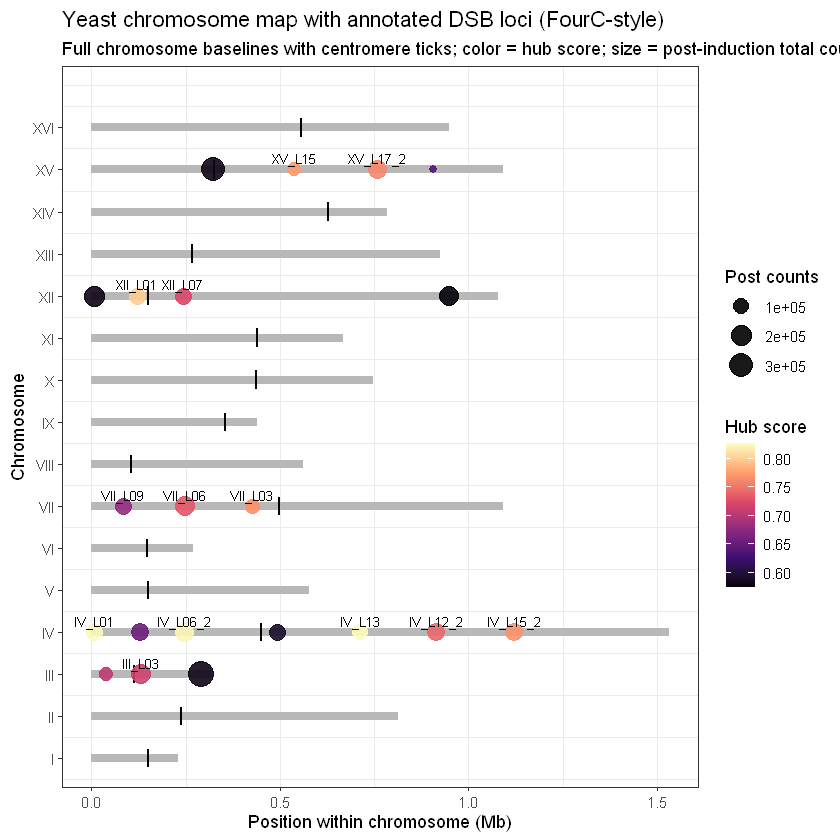

Could not build t0/t120 profile matrices for delta heatmap.



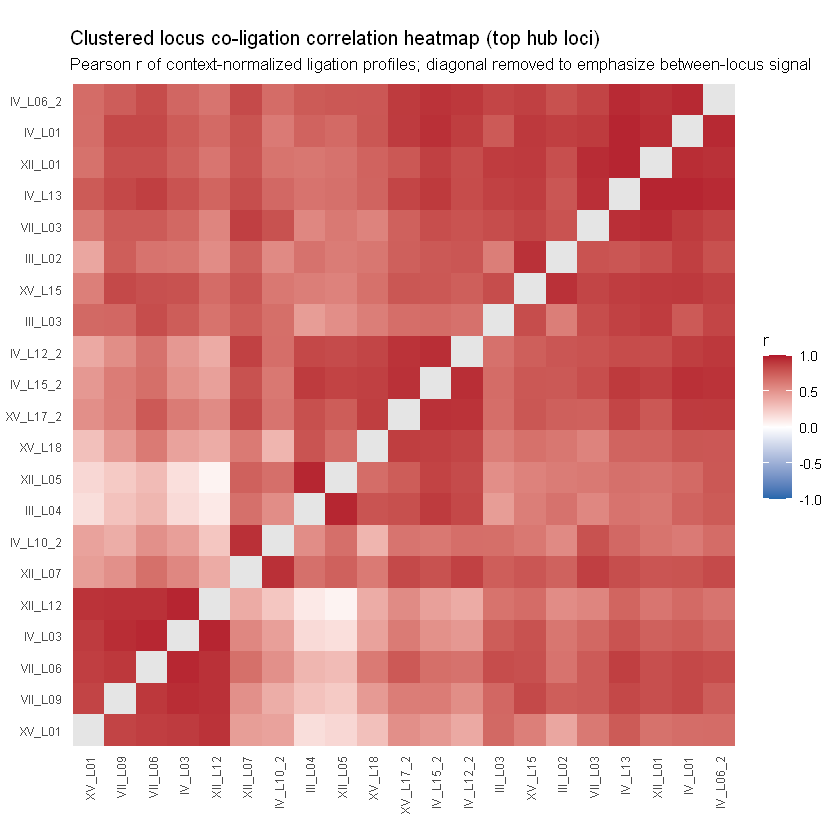

Saved DSB annotation and co-ligation matrices to: c:/Users/dunnmk/wilsontew-data-analysis/Outputs/3C



chrom,locus_id,coord_start,coord_end,midpoint,genes,hub_score,total_count_tpost
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
III,III_L02,37616,37835,37725.5,APA1; LRE1,0.7041196,58684
III,III_L03,130281,130744,130512.5,SAT4; RVS161,0.7152496,170060
III,III_L04,289797,293178,291487.5,Uncharacterized; HMRA2,0.5809314,385045
IV,IV_L01,7814,8682,8248.0,SOR2; MPH2,0.8230625,118288
IV,IV_L03,130002,130406,130204.0,RPL41A; VMA1,0.6526042,124581
IV,IV_L06_2,244981,245132,245056.5,YDL121C; UPB1,0.8209245,147706
IV,IV_L10_2,492324,492555,492439.5,RPS11A; YDR026C,0.5901674,119008
IV,IV_L12_2,913924,914316,914120.0,YDR214W; YDR215C,0.7416804,128726
IV,IV_L13,712994,713339,713166.5,MTC6; SAC6,0.8255224,90628


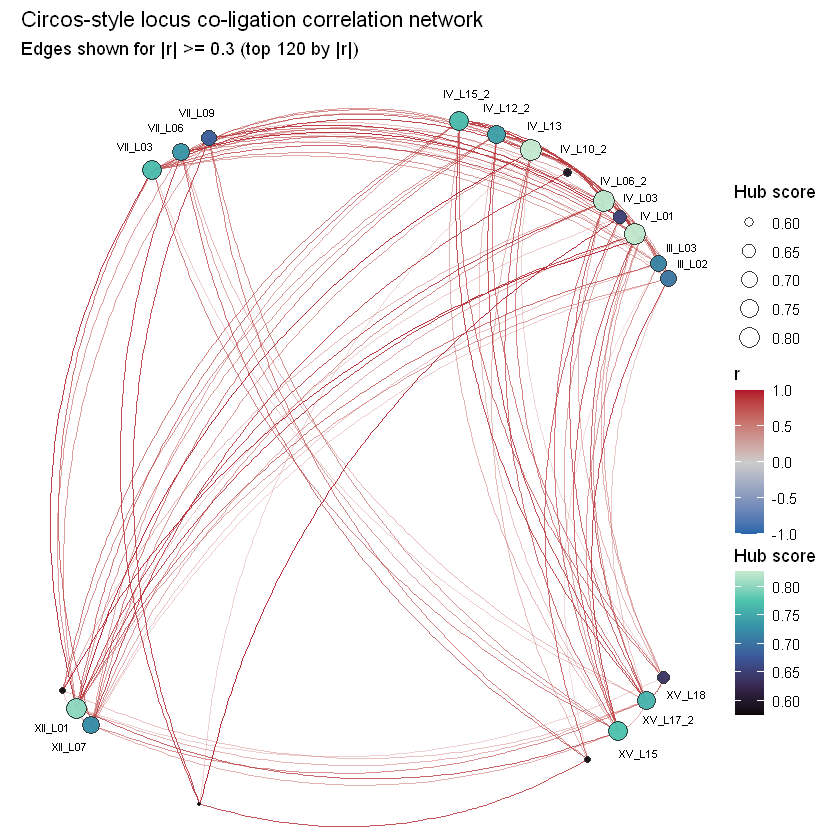

In [11]:
# ---- DSB coordinate annotation + chromosome map + clustered co-ligation heatmaps + circos-style network ----

if (!exists("dat_focus")) {
  stop("dat_focus is not available. Please run the bootstrap cell immediately above this one.")
}

normalize_locus_id <- function(x) {
  x <- as.character(x)
  x <- stringr::str_trim(x)
  x <- stringr::str_to_upper(x)
  x <- stringr::str_replace(x, "^CHR", "")
  x <- stringr::str_replace(x, "_1PERCENT_CONTROL$", "")
  x
}

build_profile_matrix <- function(df_in, include_time = TRUE) {
  if (nrow(df_in) == 0) return(NULL)

  if (include_time) {
    feat_cols <- c("batch", "replicate", "DSB", "combo", "time_point")
  } else {
    feat_cols <- c("batch", "replicate", "DSB", "combo")
  }

  prof <- df_in %>%
    dplyr::mutate(
      locus_id = normalize_locus_id(as.character(allele)),
      feature = do.call(paste, c(dplyr::across(dplyr::all_of(feat_cols)), sep = " | "))
    ) %>%
    dplyr::group_by(feature, locus_id) %>%
    dplyr::summarise(raw_count = sum(count, na.rm = TRUE), .groups = "drop") %>%
    dplyr::group_by(feature) %>%
    dplyr::mutate(
      feature_total = sum(raw_count, na.rm = TRUE),
      freq = dplyr::if_else(feature_total > 0, raw_count / feature_total, 0)
    ) %>%
    dplyr::ungroup()

  prof_wide <- prof %>%
    dplyr::select(locus_id, feature, freq) %>%
    tidyr::pivot_wider(names_from = feature, values_from = freq, values_fill = 0)

  if (nrow(prof_wide) < 2 || ncol(prof_wide) < 2) return(NULL)

  mat <- prof_wide %>% tibble::column_to_rownames("locus_id") %>% as.matrix()
  mat
}

safe_cor_mat <- function(mat) {
  cm <- stats::cor(t(mat), use = "pairwise.complete.obs", method = "pearson")
  cm[!is.finite(cm)] <- NA_real_
  cm
}

cluster_order_from_cor <- function(cor_mat) {
  cm <- cor_mat
  cm[!is.finite(cm)] <- 0
  diag(cm) <- 1
  d <- stats::as.dist(1 - cm)
  hc <- stats::hclust(d, method = "average")
  rownames(cm)[hc$order]
}

primer_csv_candidates <- c(
  file.path(getwd(), "Insertion_Primers_for_Locations_of_DSBs.csv"),
  "h:/My Documents/Insertion Primers for Locations of DSBs.csv"
)

primer_csv <- primer_csv_candidates[file.exists(primer_csv_candidates)][1]
if (is.na(primer_csv) || !nzchar(primer_csv)) {
  stop("Could not find primer CSV. Place it at project root as 'Insertion_Primers_for_Locations_of_DSBs.csv' or update primer_csv_candidates.")
}
message("Using primer CSV: ", normalizePath(primer_csv, winslash = "/", mustWork = FALSE))

break_raw <- readr::read_csv(
  primer_csv,
  show_col_types = FALSE,
  col_types = readr::cols(.default = readr::col_character())
)

# Keep first 10 expected columns and normalize names (the source has duplicate coordinate headers)
break_raw <- break_raw[, seq_len(min(10, ncol(break_raw))), drop = FALSE]
colnames(break_raw) <- c(
  "Location", "Orientation", "Systematic_Gene_Name", "Gene_Name",
  "Coord_Start", "Coord_End", "Pct_Left", "Pct_Right", "Primer_Name", "Primer_Sequence"
)

break_loci <- break_raw %>%
  dplyr::filter(!is.na(Primer_Name), Primer_Name != "") %>%
  dplyr::mutate(
    Coord_Start = readr::parse_number(Coord_Start),
    Coord_End = readr::parse_number(Coord_End),
    chrom = stringr::str_extract(Primer_Name, "^[^_]+"),
    locus_id = normalize_locus_id(stringr::str_remove(Primer_Name, "_(FWD|REV)$"))
  ) %>%
  dplyr::filter(is.finite(Coord_Start), is.finite(Coord_End), !is.na(chrom), !is.na(locus_id)) %>%
  dplyr::group_by(chrom, locus_id) %>%
  dplyr::summarise(
    coord_start = min(Coord_Start, na.rm = TRUE),
    coord_end = max(Coord_End, na.rm = TRUE),
    midpoint = (coord_start + coord_end) / 2,
    genes = paste(unique(na.omit(Gene_Name)), collapse = "; "),
    .groups = "drop"
  )

# Build context-normalized locus profiles from direct ligation-supported counts
excluded_loci <- c("15_L04", "XV_L04")
profile_mat_all <- build_profile_matrix(dat_focus, include_time = TRUE)
if (is.null(profile_mat_all) || nrow(profile_mat_all) < 4) {
  stop("Not enough loci to build co-ligation map (need >= 4 loci in dat_focus).")
}

common_loci <- intersect(rownames(profile_mat_all), break_loci$locus_id)
common_loci <- setdiff(common_loci, excluded_loci)
if (length(common_loci) < 4) {
  stop("Too few loci overlap between dat_focus$allele and primer CSV locus IDs. Check naming conventions.")
}

profile_mat_all <- profile_mat_all[common_loci, , drop = FALSE]
assoc_cor <- safe_cor_mat(profile_mat_all)
diag(assoc_cor) <- NA_real_

hub_score <- rowMeans(abs(assoc_cor), na.rm = TRUE)
hub_tbl <- tibble::tibble(locus_id = names(hub_score), hub_score = as.numeric(hub_score))

count_tbl <- dat_focus %>%
  dplyr::filter(time_point %in% c(120, 180)) %>%
  dplyr::group_by(locus_id = normalize_locus_id(as.character(allele))) %>%
  dplyr::summarise(total_count_tpost = sum(count, na.rm = TRUE), .groups = "drop")

locus_annot <- break_loci %>%
  dplyr::inner_join(hub_tbl, by = "locus_id") %>%
  dplyr::left_join(count_tbl, by = "locus_id")

# sacCer3 chromosome lengths and centromeres (bp)
chr_lengths <- tibble::tribble(
  ~chrom, ~chr_len,
  "I", 230218,
  "II", 813184,
  "III", 316620,
  "IV", 1531933,
  "V", 576874,
  "VI", 270161,
  "VII", 1090940,
  "VIII", 562643,
  "IX", 439888,
  "X", 745751,
  "XI", 666816,
  "XII", 1078177,
  "XIII", 924431,
  "XIV", 784333,
  "XV", 1091291,
  "XVI", 948066
)

centromeres <- tibble::tribble(
  ~chrom, ~cen_bp,
  "I", 151583,
  "II", 238323,
  "III", 114385,
  "IV", 449711,
  "V", 151465,
  "VI", 148510,
  "VII", 497038,
  "VIII", 105703,
  "IX", 355629,
  "X", 436425,
  "XI", 440246,
  "XII", 150947,
  "XIII", 268031,
  "XIV", 628758,
  "XV", 326584,
  "XVI", 556070
)

chr_order <- c("I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI")

chr_layout <- chr_lengths %>%
  dplyr::mutate(chrom = factor(chrom, levels = chr_order)) %>%
  dplyr::arrange(chrom) %>%
  dplyr::mutate(y = dplyr::row_number()) %>%
  dplyr::left_join(centromeres, by = "chrom")

locus_plot <- locus_annot %>%
  dplyr::inner_join(chr_layout %>% dplyr::select(chrom, y, chr_len), by = "chrom") %>%
  dplyr::mutate(pos_mb = midpoint / 1e6)

# 1) FourC-style chromosome map (full chromosomes + centromeres + DSB loci)
label_loci <- locus_plot %>%
  dplyr::arrange(dplyr::desc(hub_score)) %>%
  dplyr::slice_head(n = min(15, nrow(locus_plot)))

p_chrmap_hub <- ggplot() +
  geom_segment(
    data = chr_layout,
    aes(x = 0, xend = chr_len / 1e6, y = y, yend = y),
    linewidth = 2.4,
    color = "grey72"
  ) +
  geom_segment(
    data = chr_layout %>% dplyr::filter(is.finite(cen_bp)),
    aes(x = cen_bp / 1e6, xend = cen_bp / 1e6, y = y - 0.22, yend = y + 0.22),
    linewidth = 0.7,
    color = "black"
  ) +
  geom_point(
    data = locus_plot,
    aes(x = pos_mb, y = y, color = hub_score, size = total_count_tpost),
    alpha = 0.9,
    stroke = 0.25
  ) +
  geom_text(
    data = label_loci,
    aes(x = pos_mb, y = y + 0.28, label = locus_id),
    size = 2.7,
    check_overlap = TRUE
  ) +
  scale_y_continuous(
    breaks = chr_layout$y,
    labels = as.character(chr_layout$chrom),
    expand = expansion(mult = c(0.03, 0.08))
  ) +
  scale_color_viridis_c(option = "magma", na.value = "grey40") +
  scale_size_continuous(range = c(2.1, 7.2)) +
  theme_bw(base_size = 11) +
  theme(panel.grid.major.y = element_blank()) +
  labs(
    title = "Yeast chromosome map with annotated DSB loci (FourC-style)",
    subtitle = "Full chromosome baselines with centromere ticks; color = hub score; size = post-induction total counts",
    x = "Position within chromosome (Mb)",
    y = "Chromosome",
    color = "Hub score",
    size = "Post counts"
  )
print(p_chrmap_hub)

# 2) Clustered heatmap of strongest co-ligation-correlated loci
ord <- names(sort(hub_score, decreasing = TRUE))
keep_n <- min(24, length(ord))
heat_loci <- ord[seq_len(keep_n)]
heat_mat <- assoc_cor[heat_loci, heat_loci, drop = FALSE]

cluster_ord <- cluster_order_from_cor(heat_mat)
heat_mat_ord <- heat_mat[cluster_ord, cluster_ord, drop = FALSE]
diag(heat_mat_ord) <- NA_real_

heat_df <- as.data.frame(as.table(heat_mat_ord))
colnames(heat_df) <- c("Locus1", "Locus2", "Correlation")

p_locus_heatmap <- ggplot(heat_df, aes(x = Locus1, y = Locus2, fill = Correlation)) +
  geom_tile() +
  scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b", midpoint = 0, limits = c(-1, 1), na.value = "grey90") +
  coord_equal() +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    panel.grid = element_blank()
  ) +
  labs(
    title = "Clustered locus co-ligation correlation heatmap (top hub loci)",
    subtitle = "Pearson r of context-normalized ligation profiles; diagonal removed to emphasize between-locus signal",
    x = NULL,
    y = NULL,
    fill = "r"
  )
print(p_locus_heatmap)

# 2b) Delta heatmap: t120 minus t0 co-ligation correlation
profile_mat_t0 <- build_profile_matrix(dat_focus %>% dplyr::filter(time_point == 0), include_time = FALSE)
profile_mat_t120 <- build_profile_matrix(dat_focus %>% dplyr::filter(time_point == 120), include_time = FALSE)
if (!is.null(profile_mat_t0)) profile_mat_t0 <- profile_mat_t0[setdiff(rownames(profile_mat_t0), excluded_loci), , drop = FALSE]
if (!is.null(profile_mat_t120)) profile_mat_t120 <- profile_mat_t120[setdiff(rownames(profile_mat_t120), excluded_loci), , drop = FALSE]

delta_cor <- NULL
if (!is.null(profile_mat_t0) && !is.null(profile_mat_t120)) {
  common_delta <- Reduce(intersect, list(
    rownames(profile_mat_t0),
    rownames(profile_mat_t120),
    break_loci$locus_id,
    heat_loci
  ))

  if (length(common_delta) >= 4) {
    cor_t0 <- safe_cor_mat(profile_mat_t0[common_delta, , drop = FALSE])
    cor_t120 <- safe_cor_mat(profile_mat_t120[common_delta, , drop = FALSE])
    delta_cor <- cor_t120 - cor_t0
    diag(delta_cor) <- NA_real_

    delta_ord <- cluster_ord[cluster_ord %in% common_delta]
    if (length(delta_ord) < 4) delta_ord <- common_delta

    delta_mat_ord <- delta_cor[delta_ord, delta_ord, drop = FALSE]
    max_abs_delta <- max(abs(delta_mat_ord), na.rm = TRUE)
    if (!is.finite(max_abs_delta) || max_abs_delta <= 0) max_abs_delta <- 0.1

    delta_df <- as.data.frame(as.table(delta_mat_ord))
    colnames(delta_df) <- c("Locus1", "Locus2", "Delta_r")

    p_delta_heatmap <- ggplot(delta_df, aes(x = Locus1, y = Locus2, fill = Delta_r)) +
      geom_tile() +
      scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b", midpoint = 0, limits = c(-max_abs_delta, max_abs_delta), na.value = "grey90") +
      coord_equal() +
      theme_minimal(base_size = 10) +
      theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7),
        axis.text.y = element_text(size = 7),
        panel.grid = element_blank()
      ) +
      labs(
        title = "Delta co-ligation correlation heatmap (t120 - t0)",
        subtitle = "Positive values indicate strengthened co-ligation correlation at t120; diagonal removed",
        x = NULL,
        y = NULL,
        fill = "Δr"
      )
    print(p_delta_heatmap)
  } else {
    message("Not enough overlapping loci across t0/t120 to build delta heatmap.")
  }
} else {
  message("Could not build t0/t120 profile matrices for delta heatmap.")
}

# 3) Circos-style plot for strongest edges by |r| threshold
edge_abs_r_min <- 0.30

chr_offsets <- chr_layout %>%
  dplyr::mutate(
    offset = dplyr::lag(cumsum(chr_len), default = 0),
    chrom = as.character(chrom)
  ) %>%
  dplyr::select(chrom, offset)

genome_len <- sum(chr_layout$chr_len, na.rm = TRUE)

nodes <- locus_plot %>%
  dplyr::left_join(chr_offsets, by = "chrom") %>%
  dplyr::mutate(
    genome_x = offset + midpoint,
    theta = 2 * pi * (genome_x / genome_len),
    x = cos(theta),
    y_circ = sin(theta)
  )

upper_idx <- which(upper.tri(assoc_cor), arr.ind = TRUE)
edge_tbl <- tibble::tibble(
  from = rownames(assoc_cor)[upper_idx[, 1]],
  to = colnames(assoc_cor)[upper_idx[, 2]],
  weight = assoc_cor[upper_idx]
 ) %>%
  dplyr::filter(is.finite(weight)) %>%
  dplyr::mutate(abs_weight = abs(weight)) %>%
  dplyr::filter(abs_weight >= edge_abs_r_min) %>%
  dplyr::arrange(dplyr::desc(abs_weight))

if (nrow(edge_tbl) > 0) {
  edge_top <- edge_tbl %>% dplyr::slice_head(n = 120)

  edge_plot <- edge_top %>%
    dplyr::left_join(nodes %>% dplyr::select(locus_id, x_from = x, y_from = y_circ), by = c("from" = "locus_id")) %>%
    dplyr::left_join(nodes %>% dplyr::select(locus_id, x_to = x, y_to = y_circ), by = c("to" = "locus_id")) %>%
    dplyr::filter(dplyr::if_all(c(x_from, y_from, x_to, y_to), is.finite))

  top_labels <- nodes %>%
    dplyr::arrange(dplyr::desc(hub_score)) %>%
    dplyr::slice_head(n = min(18, nrow(nodes)))

  p_circos_assoc <- ggplot() +
    geom_curve(
      data = edge_plot,
      aes(x = x_from, y = y_from, xend = x_to, yend = y_to, alpha = abs_weight, color = weight),
      curvature = 0.22,
      linewidth = 0.55
    ) +
    geom_point(data = nodes, aes(x = x, y = y_circ, size = hub_score, fill = hub_score), alpha = 0.96, shape = 21, color = "grey20", stroke = 0.2) +
    geom_text(data = top_labels, aes(x = 1.08 * x, y = 1.08 * y_circ, label = locus_id), size = 2.4, check_overlap = TRUE) +
    coord_equal() +
    scale_fill_viridis_c(option = "mako", end = 0.95, na.value = "grey45") +
    scale_color_gradient2(low = "#2166ac", mid = "grey80", high = "#b2182b", midpoint = 0, limits = c(-1, 1)) +
    scale_alpha_continuous(range = c(0.2, 0.95), guide = "none") +
    theme_void(base_size = 11) +
    labs(
      title = "Circos-style locus co-ligation correlation network",
      subtitle = paste0("Edges shown for |r| >= ", edge_abs_r_min, " (top 120 by |r|)"),
      color = "r",
      fill = "Hub score",
      size = "Hub score"
    )

  print(p_circos_assoc)
} else {
  message("No finite edges passed the |r| threshold for circos-style plot.")
}

# Export annotation and matrices for downstream review
out_dir <- file.path(getwd(), "Outputs", "3C")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
readr::write_csv(locus_annot, file.path(out_dir, "3C_dsb_locus_coordinate_annotation.csv"))
readr::write_csv(tibble::rownames_to_column(as.data.frame(assoc_cor), "locus_id"), file.path(out_dir, "3C_locus_coligation_correlation_matrix.csv"))
if (!is.null(delta_cor)) {
  readr::write_csv(tibble::rownames_to_column(as.data.frame(delta_cor), "locus_id"), file.path(out_dir, "3C_locus_coligation_delta_t120_minus_t0.csv"))
}

message("Saved DSB annotation and co-ligation matrices to: ", out_dir)
head(locus_annot, 12)

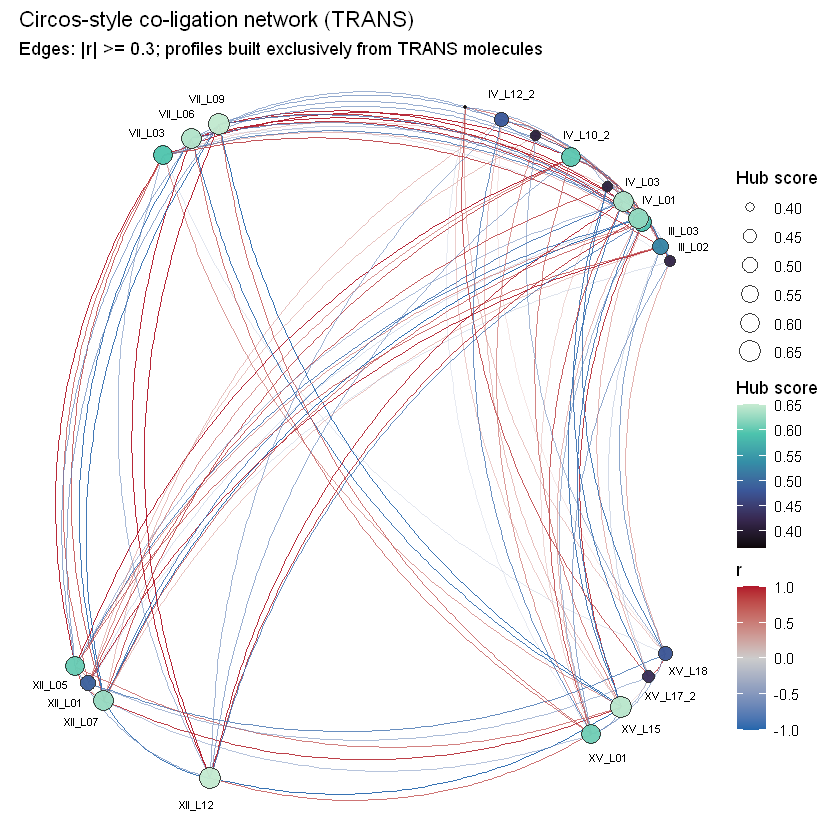

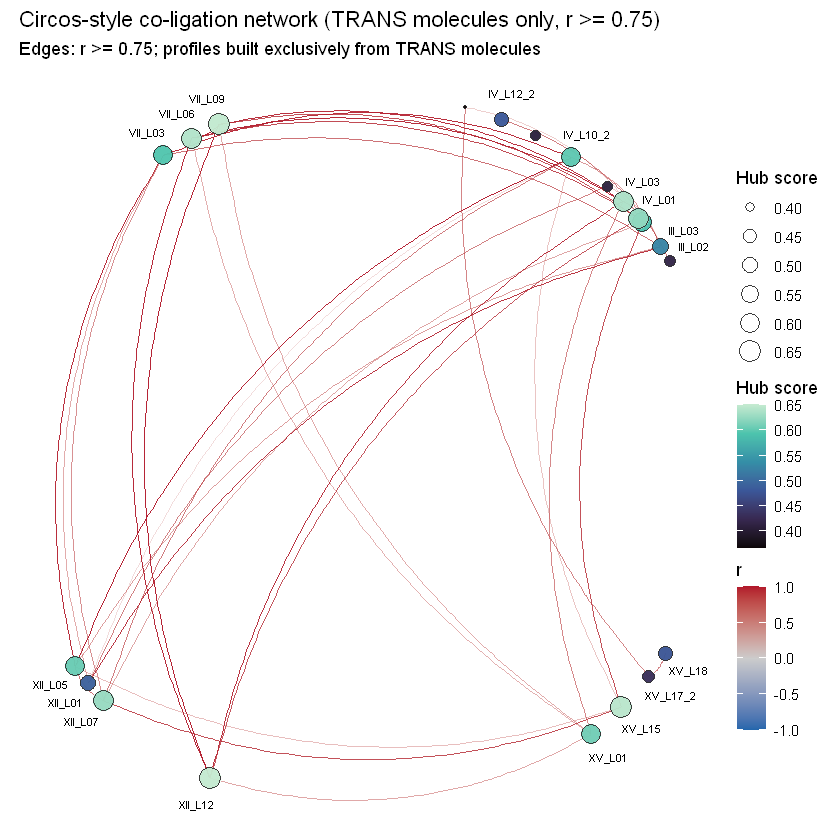

In [27]:
# ---- TRANS-only circos plots ----

if (!exists("dat_focus") || !exists("build_profile_matrix") || !exists("safe_cor_mat") || !exists("nodes") || !exists("break_loci") || !exists("excluded_loci")) {
  stop("Run the chromosome-level circos cell immediately above before running this TRANS split cell.")
}

combo_levels <- sort(unique(as.character(dat_focus$combo)))
if (all(c("CIS", "TRANS") %in% combo_levels)) {
  trans_combo_labels <- "TRANS"
} else {
  trans_combo_labels <- c("A_to_D", "C_to_B")
}

make_circos <- function(
  prof_mat_in,
  label,
  nodes_df,
  break_loci_df,
  excluded,
  edge_abs_r_min = 0.30,
  title_label = label,
  use_absolute_threshold = TRUE
) {
  loci <- setdiff(intersect(rownames(prof_mat_in), break_loci_df$locus_id), excluded)
  if (length(loci) < 4) {
    message("Not enough loci for ", label, " circos.")
    return(invisible(NULL))
  }

  mat <- prof_mat_in[loci, , drop = FALSE]
  cor_mat <- safe_cor_mat(mat)
  diag(cor_mat) <- NA_real_

  upper_idx <- which(upper.tri(cor_mat), arr.ind = TRUE)
  edges <- tibble::tibble(
    from   = rownames(cor_mat)[upper_idx[, 1]],
    to     = colnames(cor_mat)[upper_idx[, 2]],
    weight = cor_mat[upper_idx]
  )

  if (use_absolute_threshold) {
    edges <- edges %>%
      dplyr::filter(is.finite(weight), abs(weight) >= edge_abs_r_min) %>%
      dplyr::arrange(dplyr::desc(abs(weight)))
    subtitle_threshold <- paste0("|r| >= ", edge_abs_r_min)
  } else {
    edges <- edges %>%
      dplyr::filter(is.finite(weight), weight >= edge_abs_r_min) %>%
      dplyr::arrange(dplyr::desc(weight))
    subtitle_threshold <- paste0("r >= ", edge_abs_r_min)
  }

  edges <- edges %>% dplyr::slice_head(n = 120)

  if (nrow(edges) == 0) {
    message("No edges passed threshold for ", label, " circos.")
    return(invisible(NULL))
  }

  edge_plot <- edges %>%
    dplyr::left_join(nodes_df %>% dplyr::select(locus_id, x_from = x, y_from = y_circ), by = c("from" = "locus_id")) %>%
    dplyr::left_join(nodes_df %>% dplyr::select(locus_id, x_to = x, y_to = y_circ), by = c("to" = "locus_id")) %>%
    dplyr::filter(stats::complete.cases(x_from, y_from, x_to, y_to))

  if (nrow(edge_plot) == 0) {
    message("No drawable edges remained for ", label, " circos after joining node coordinates.")
    return(invisible(NULL))
  }

  hub_sc <- rowMeans(abs(cor_mat), na.rm = TRUE)
  nodes_sub <- nodes_df %>%
    dplyr::filter(locus_id %in% loci) %>%
    dplyr::mutate(hub_score_sub = unname(hub_sc[locus_id]))

  top_labels <- nodes_sub %>%
    dplyr::arrange(dplyr::desc(hub_score_sub)) %>%
    dplyr::slice_head(n = min(18, nrow(nodes_sub)))

  p <- ggplot() +
    geom_curve(
      data = edge_plot,
      aes(x = x_from, y = y_from, xend = x_to, yend = y_to, alpha = abs(weight), color = weight),
      curvature = 0.22,
      linewidth = 0.55
    ) +
    geom_point(
      data = nodes_sub,
      aes(x = x, y = y_circ, size = hub_score_sub, fill = hub_score_sub),
      alpha = 0.96,
      shape = 21,
      color = "grey20",
      stroke = 0.2
    ) +
    geom_text(
      data = top_labels,
      aes(x = 1.08 * x, y = 1.08 * y_circ, label = locus_id),
      size = 2.4,
      check_overlap = TRUE
    ) +
    coord_equal() +
    scale_fill_viridis_c(option = "mako", end = 0.95, na.value = "grey45") +
    scale_color_gradient2(low = "#2166ac", mid = "grey80", high = "#b2182b", midpoint = 0, limits = c(-1, 1)) +
    scale_alpha_continuous(range = c(0.2, 0.95), guide = "none") +
    theme_void(base_size = 11) +
    labs(
      title = paste0("Circos-style co-ligation network (", title_label, ")"),
      subtitle = paste0("Edges: ", subtitle_threshold, "; profiles built exclusively from ", label, " molecules"),
      color = "r",
      fill = "Hub score",
      size = "Hub score"
    )

  print(p)
  invisible(p)
}

profile_mat_trans_c <- build_profile_matrix(
  dat_focus %>% dplyr::filter(combo %in% trans_combo_labels),
  include_time = TRUE
)

if (!is.null(profile_mat_trans_c)) {
  make_circos(profile_mat_trans_c, "TRANS", nodes, break_loci, excluded_loci)
  make_circos(
    profile_mat_trans_c,
    "TRANS",
    nodes,
    break_loci,
    excluded_loci,
    edge_abs_r_min = 0.75,
    title_label = "TRANS molecules only, r >= 0.75",
    use_absolute_threshold = FALSE
  )
} else {
  message("TRANS profile matrix could not be built.")
}


## kNN-based block map (why this is shown)

This panel emphasizes **local neighborhood structure** rather than only global dendrogram ordering.

- In the kNN adjacency map, each locus is connected to its $k$ most similar late-time co-ligation profiles. This highlights *who each locus most strongly co-associates with*.
- We then compute shared-neighbor similarity and assign coarse blocks, which is useful for detecting chromosome groups/modules with dense within-group associations.
- The companion correlation heatmap is ordered by these kNN-derived blocks (with hierarchical ordering only **within** each block), so the block pattern remains explicit.

Why this often helps: hierarchical clustering is excellent for global structure, but it can blur compact local modules when one branch dominates the tree. kNN graphs are local by construction, so they frequently reveal sharper block boundaries in chromosome-association data.

---

### Reading the co-ligation correlation heatmap

The color at each cell $(i, j)$ is the **Pearson correlation** ($r$) between the full co-ligation frequency profiles of locus $i$ and locus $j$ — i.e., how similarly the two loci distribute their contacts across all other loci in the dataset.

**Zero diagonal**
The diagonal (each locus vs. itself) is set to zero rather than the mathematically expected $r = 1$. Self-ligation events are uninformative noise in 3C-seq (they reflect intramolecular proximity constraints, not chromatin architecture), so the diagonal is masked out to prevent the $r = 1$ anchor from compressing the color scale and obscuring off-diagonal signal.

**High $r$ close to the diagonal (nearby loci, similar profiles)**
Pairs close to the diagonal are loci that are adjacent or near each other on the same chromosome arm. They tend to share a local chromatin environment — overlapping neighborhoods of contacts — so their co-ligation profiles are naturally correlated. A band of high $r$ running along the diagonal is the expected baseline signature of genomic proximity and local chromatin continuity.

**High $r$ far from the diagonal (distant loci, shared interactome)**
Bright cells far from the diagonal are the most interpretively interesting: two loci that are far apart in the linear genome nevertheless capture similar sets of co-ligation partners. This typically reflects **long-range spatial co-localization** — both loci occupy the same 3D compartment, interact with the same transcriptional hubs, or are co-recruited to the same nuclear body. In the yeast context here, these off-diagonal high-$r$ blocks often mark loci co-tethered near the spindle pole body, the nuclear periphery, or shared replication origins.

**Low $r$ (uncorrelated or opposing profiles)**
Low (near zero or negative) $r$ values indicate that the two loci partition into distinct spatial compartments. Their contact partners are largely non-overlapping, consistent with them residing in different nuclear sub-domains that do not share interaction space. These pairs form the "background" separating the high-$r$ blocks and give meaning to the block boundaries revealed by the kNN ordering.

---

### Literature context (3C/Hi-C family)

This exact implementation is a report-level visualization, but it follows common ideas used in 3C-derived analyses:

1. **Contact maps as graph-like structures** and block/domain interpretation: Lieberman-Aiden et al., *Science* (2009).
2. **High-resolution chromatin contact matrices** and compartment/domain block organization: Rao et al., *Cell* (2014).
3. **Matrix normalization and downstream structural inference pipelines** used before clustering/module discovery: Imakaev et al., *Nat Methods* (2012, ICE).
4. **Single-cell Hi-C analyses** that rely on neighborhood/manifold-style relationships between sparse contact profiles: Nagano et al., *Nature* (2013); Ramani et al., *Nat Methods* (2017).

So while many papers use hierarchical or eigenvector/domain frameworks, graph-neighborhood views (like kNN) are fully aligned with the broader 3C/Hi-C practice of identifying contact modules and structural neighborhoods.

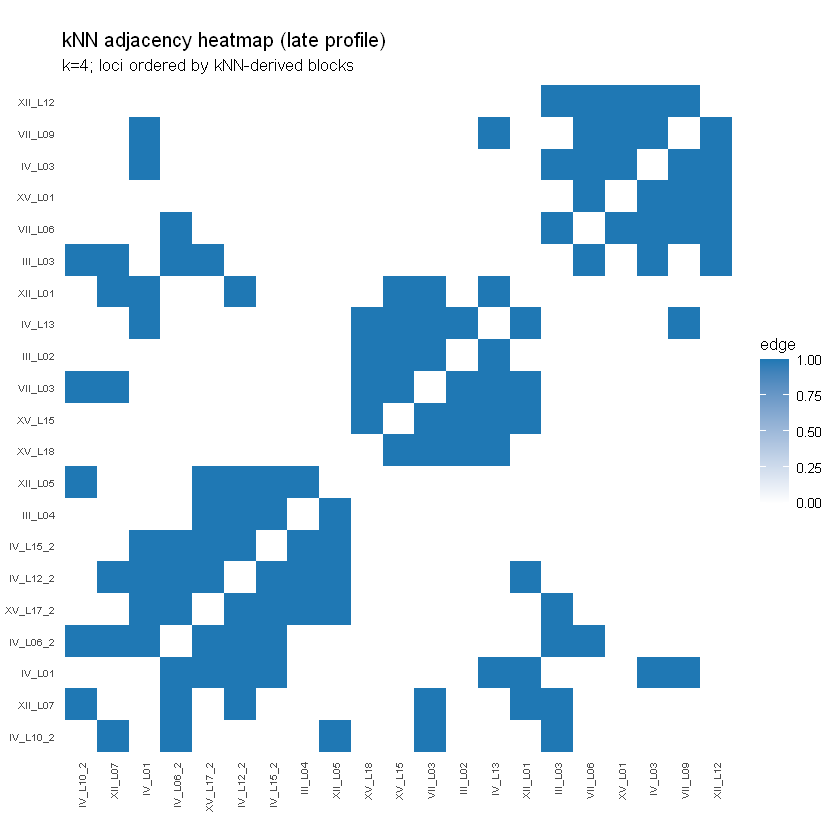

kNN block plots generated with 21 loci, k=4, blocks=3.



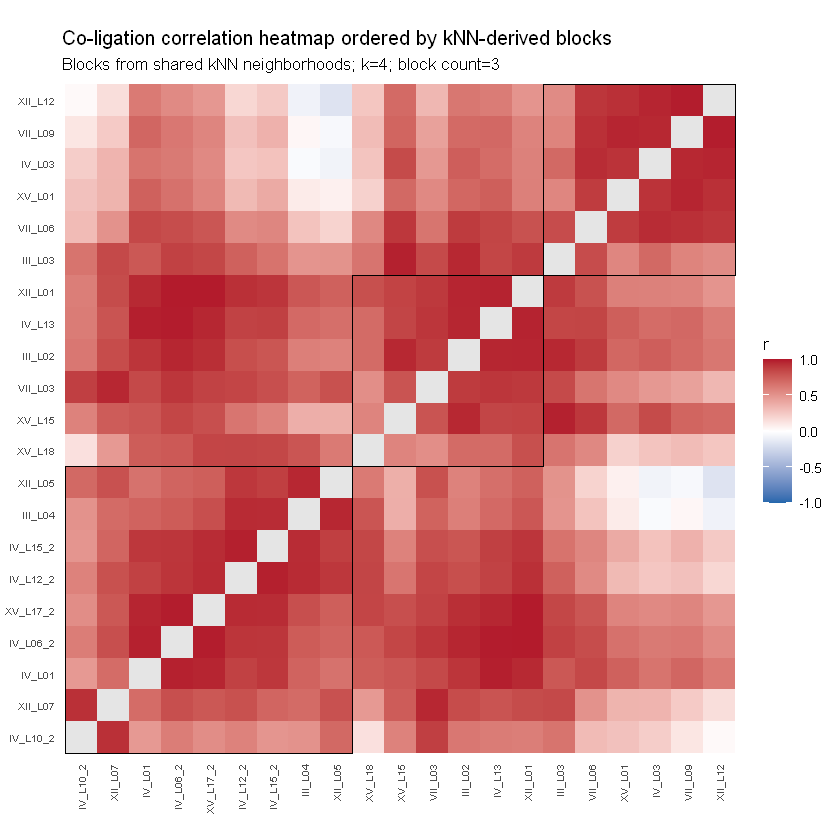

In [19]:
# ---- kNN-based block detection (complement to hierarchical heatmaps) ----

if (!exists("dat_focus") || !exists("break_loci") || !exists("build_profile_matrix")) {
  stop("Run chromosome-level cells above before running this kNN block cell.")
}

safe_cor_mat_quiet <- function(mat) {
  cm <- suppressWarnings(stats::cor(t(mat), use = "pairwise.complete.obs", method = "pearson"))
  cm[!is.finite(cm)] <- NA_real_
  cm
}

excluded_loci_knn <- c("15_L04", "XV_L04")
eps_knn <- 1e-6

available_tps <- dat_focus %>%
  dplyr::mutate(time_point = as.numeric(as.character(time_point))) %>%
  dplyr::filter(is.finite(time_point)) %>%
  dplyr::pull(time_point) %>%
  unique() %>%
  sort()

if (length(available_tps) < 2) {
  message("Skipping kNN block plots: need at least 2 timepoints.")
} else {
  tp_early <- if (0 %in% available_tps) 0 else available_tps[1]
  tp_late <- if (120 %in% available_tps) 120 else available_tps[length(available_tps)]
  if (tp_early == tp_late) tp_late <- available_tps[length(available_tps)]

  profile_mat_early <- build_profile_matrix(dat_focus %>% dplyr::filter(time_point == tp_early), include_time = FALSE)
  profile_mat_late <- build_profile_matrix(dat_focus %>% dplyr::filter(time_point == tp_late), include_time = FALSE)

  if (!is.null(profile_mat_early)) profile_mat_early <- profile_mat_early[setdiff(rownames(profile_mat_early), excluded_loci_knn), , drop = FALSE]
  if (!is.null(profile_mat_late)) profile_mat_late <- profile_mat_late[setdiff(rownames(profile_mat_late), excluded_loci_knn), , drop = FALSE]

  if (is.null(profile_mat_early) || is.null(profile_mat_late)) {
    message("Skipping kNN block plots: missing profile matrix at selected timepoints.")
  } else {
    common_loci <- Reduce(intersect, list(
      rownames(profile_mat_early),
      rownames(profile_mat_late),
      break_loci$locus_id
    ))

    if (length(common_loci) < 6) {
      message("Skipping kNN block plots: need at least 6 overlapping loci.")
    } else {
      X_late <- profile_mat_late[common_loci, , drop = FALSE]
      X_early <- profile_mat_early[common_loci, , drop = FALSE]

      # kNN graph on late profiles (Euclidean in feature space)
      dmat <- as.matrix(stats::dist(X_late, method = "euclidean"))
      diag(dmat) <- Inf

      n_loci <- nrow(dmat)
      k_neighbors <- max(2, min(8, floor(sqrt(n_loci))))

      knn_adj <- matrix(0, nrow = n_loci, ncol = n_loci, dimnames = list(rownames(X_late), rownames(X_late)))
      for (i in seq_len(n_loci)) {
        nn_idx <- order(dmat[i, ], decreasing = FALSE)[seq_len(k_neighbors)]
        knn_adj[i, nn_idx] <- 1
      }

      # Mutual/symmetric kNN graph
      knn_sym <- ((knn_adj + t(knn_adj)) > 0) * 1
      diag(knn_sym) <- 0

      # Build block labels from shared-neighbor structure
      shared_nn <- knn_sym %*% knn_sym
      shared_nn <- shared_nn + knn_sym

      k_blocks <- max(2, min(6, round(sqrt(n_loci / 2))))
      km <- stats::kmeans(shared_nn, centers = k_blocks, nstart = 30)
      block_label <- km$cluster
      names(block_label) <- rownames(X_late)

      # Within each block, order by hierarchical clustering on late correlation
      cor_late <- safe_cor_mat_quiet(X_late)
      cor_late[!is.finite(cor_late)] <- 0
      diag(cor_late) <- 1

      block_levels <- sort(unique(block_label))
      ord <- character(0)
      for (b in block_levels) {
        members <- names(block_label)[block_label == b]
        if (length(members) == 1) {
          ord <- c(ord, members)
        } else {
          cm <- cor_late[members, members, drop = FALSE]
          d <- stats::as.dist(1 - cm)
          hc <- stats::hclust(d, method = "average")
          ord <- c(ord, rownames(cm)[hc$order])
        }
      }

      # Plot 1: kNN adjacency heatmap
      knn_df <- as.data.frame(as.table(knn_sym[ord, ord, drop = FALSE]))
      colnames(knn_df) <- c("Locus1", "Locus2", "Edge")

      p_knn_adj <- ggplot(knn_df, aes(x = Locus1, y = Locus2, fill = Edge)) +
        geom_tile() +
        scale_fill_gradient(low = "white", high = "#1f78b4", limits = c(0, 1)) +
        coord_equal() +
        theme_minimal(base_size = 10) +
        theme(
          axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
          axis.text.y = element_text(size = 6),
          panel.grid = element_blank()
        ) +
        labs(
          title = "kNN adjacency heatmap (late profile)",
          subtitle = paste0("k=", k_neighbors, "; loci ordered by kNN-derived blocks"),
          x = NULL, y = NULL, fill = "edge"
        )

      # Plot 2: correlation heatmap reordered by kNN-derived blocks
      cor_ord <- cor_late[ord, ord, drop = FALSE]
      diag(cor_ord) <- NA_real_

      cor_df <- as.data.frame(as.table(cor_ord))
      colnames(cor_df) <- c("Locus1", "Locus2", "Correlation")

      # Block rectangles
      block_ord <- block_label[ord]
      r <- rle(block_ord)
      starts <- cumsum(c(1, head(r$lengths, -1)))
      ends <- cumsum(r$lengths)
      block_boxes <- tibble::tibble(
        xmin = starts - 0.5,
        xmax = ends + 0.5,
        ymin = starts - 0.5,
        ymax = ends + 0.5
      )

      p_knn_corr <- ggplot(cor_df, aes(x = Locus1, y = Locus2, fill = Correlation)) +
        geom_tile() +
        scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b", midpoint = 0, limits = c(-1, 1), na.value = "grey90") +
        coord_equal() +
        theme_minimal(base_size = 10) +
        theme(
          axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
          axis.text.y = element_text(size = 6),
          panel.grid = element_blank()
        ) +
        labs(
          title = "Co-ligation correlation heatmap ordered by kNN-derived blocks",
          subtitle = paste0("Blocks from shared kNN neighborhoods; k=", k_neighbors, "; block count=", length(block_levels)),
          x = NULL, y = NULL, fill = "r"
        ) +
        geom_rect(
          data = block_boxes,
          aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
          inherit.aes = FALSE,
          fill = NA,
          color = "black",
          linewidth = 0.5
        )

      if (requireNamespace("patchwork", quietly = TRUE)) {
        print(p_knn_adj + p_knn_corr + patchwork::plot_layout(ncol = 2))
      } else if (requireNamespace("gridExtra", quietly = TRUE)) {
        gridExtra::grid.arrange(p_knn_adj, p_knn_corr, ncol = 2)
      } else {
        print(p_knn_adj)
        print(p_knn_corr)
      }

      message("kNN block plots generated with ", n_loci, " loci, k=", k_neighbors, ", blocks=", length(block_levels), ".")
    }
  }
}

AF correlation stats by batch/replicate/DSB/combo (printed):



# A tibble: 16 × 7
   batch replicate DSB   combo  n_pairs       r      r2
   <chr> <chr>     <chr> <chr>    <int>   <dbl>   <dbl>
 1 4     Rep 1     DSB1  A_to_B      24  0.645  0.416  
 2 4     Rep 1     DSB2  C_to_D       2  1      1      
 3 4     Rep 1     TRANS A_to_D      24  0.0974 0.00948
 4 4     Rep 1     TRANS C_to_B      26  0.462  0.213  
 5 4     Rep 2     DSB1  A_to_B      24  0.999  0.998  
 6 4     Rep 2     DSB2  C_to_D       2  1      1      
 7 4     Rep 2     TRANS A_to_D      24  0.989  0.979  
 8 4     Rep 2     TRANS C_to_B      24  0.862  0.744  
 9 6     Rep 1     DSB1  A_to_B      24  0.965  0.931  
10 6     Rep 1     DSB2  C_to_D       2  1      1      
11 6     Rep 1     TRANS A_to_D      24  0.788  0.621  
12 6     Rep 1     TRANS C_to_B      24  0.236  0.0557 
13 8     Rep 1     DSB1  A_to_B      24  0.365  0.133  
14 8     Rep 1     DSB2  C_to_D       2 -1      1      
15 8     Rep 1     TRANS A_to_D      24  0.0795 0.00632
16 8     Rep 1     TRANS C_to

AF pooled correlation stats by DSB/combo (printed):



# A tibble: 4 × 5
  DSB   combo  n_pairs     r    r2
  <chr> <chr>    <int> <dbl> <dbl>
1 DSB1  A_to_B      24 0.887 0.786
2 DSB2  C_to_D       4 0.799 0.639
3 TRANS A_to_D      24 0.776 0.603
4 TRANS C_to_B      26 0.624 0.389


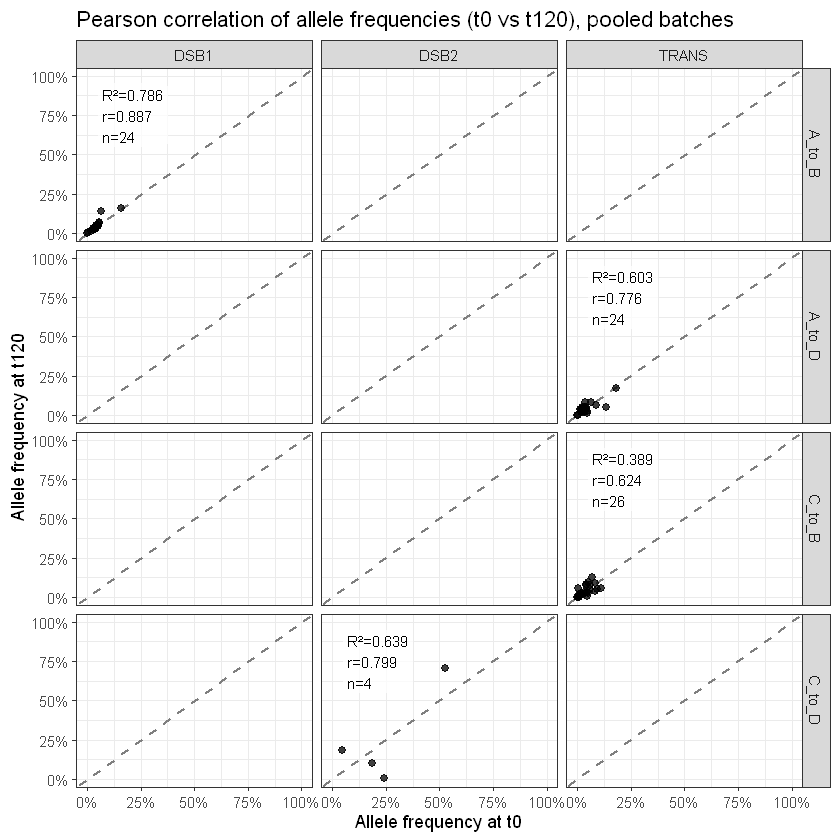

CIS correlation stats (printed): r=0.733 | R²=0.537 | n=24 | Batch=4 | Rep 1 | DSB=DSB1



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 4     Rep 1     DSB1  CIS        24 0.733 0.537


`geom_smooth()` using formula = 'y ~ x'


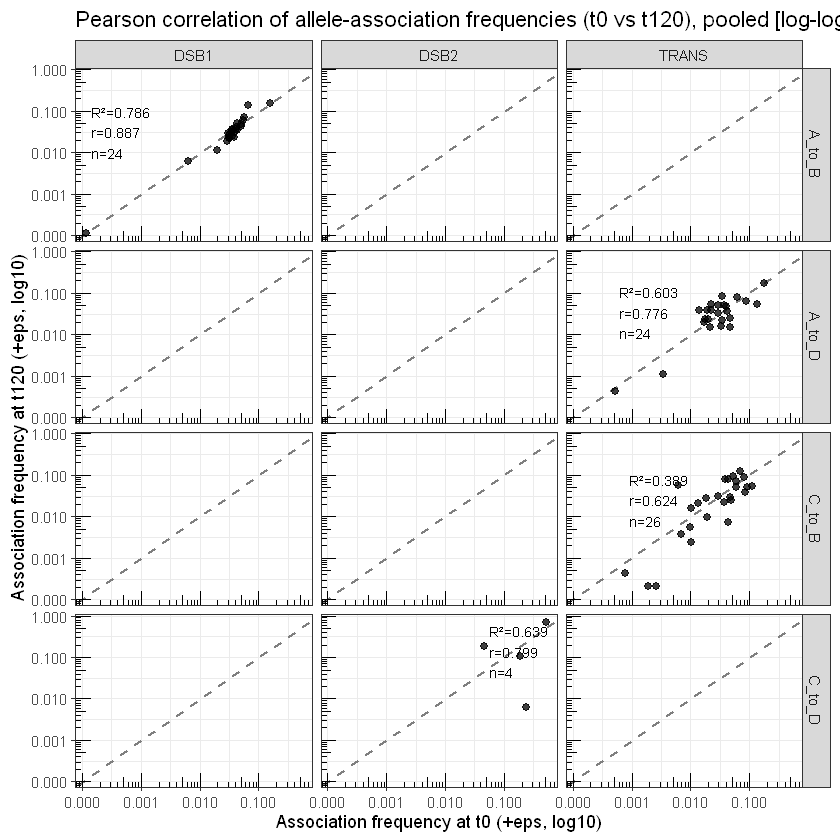

CIS correlation stats (printed): r=-1 | R²=1 | n=2 | Batch=4 | Rep 1 | DSB=DSB2



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 4     Rep 1     DSB2  CIS         2    -1     1


`geom_smooth()` using formula = 'y ~ x'


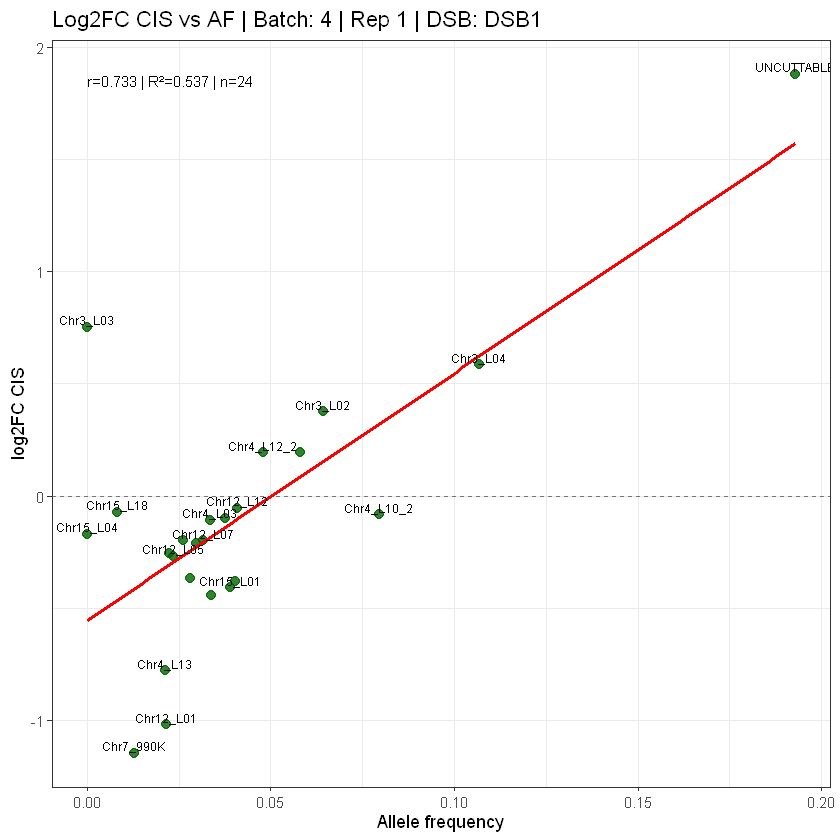

TRANS correlation stats (printed): r=0.559 | R²=0.313 | n=26 | Batch=4 | Rep 1 | DSB=TRANS



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 4     Rep 1     TRANS TRANS      26 0.559 0.313


`geom_smooth()` using formula = 'y ~ x'


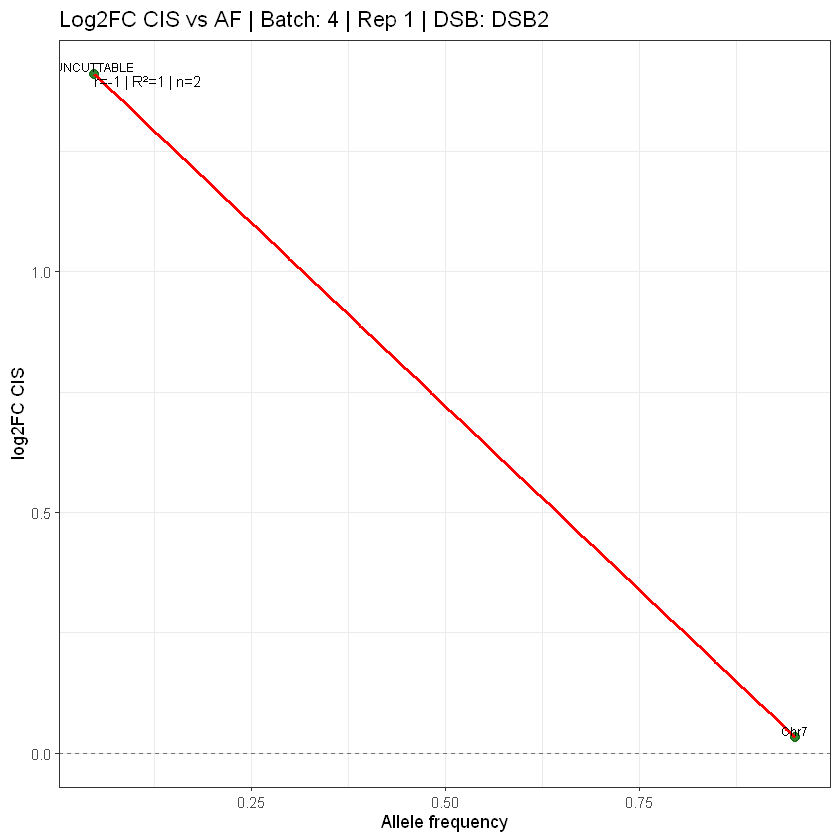

CIS correlation stats (printed): r=0.21 | R²=0.044 | n=24 | Batch=4 | Rep 2 | DSB=DSB1



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r     r2
  <chr> <chr>     <chr> <chr>   <int> <dbl>  <dbl>
1 4     Rep 2     DSB1  CIS        24 0.210 0.0440


`geom_smooth()` using formula = 'y ~ x'


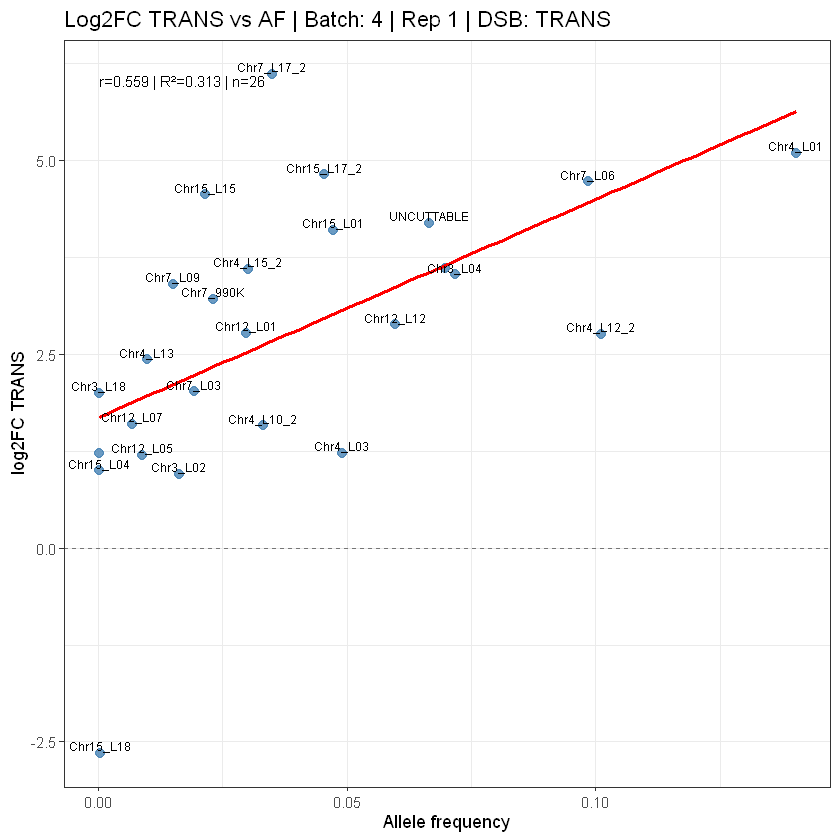

CIS correlation stats (printed): r=1 | R²=1 | n=2 | Batch=4 | Rep 2 | DSB=DSB2



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 4     Rep 2     DSB2  CIS         2     1     1


`geom_smooth()` using formula = 'y ~ x'


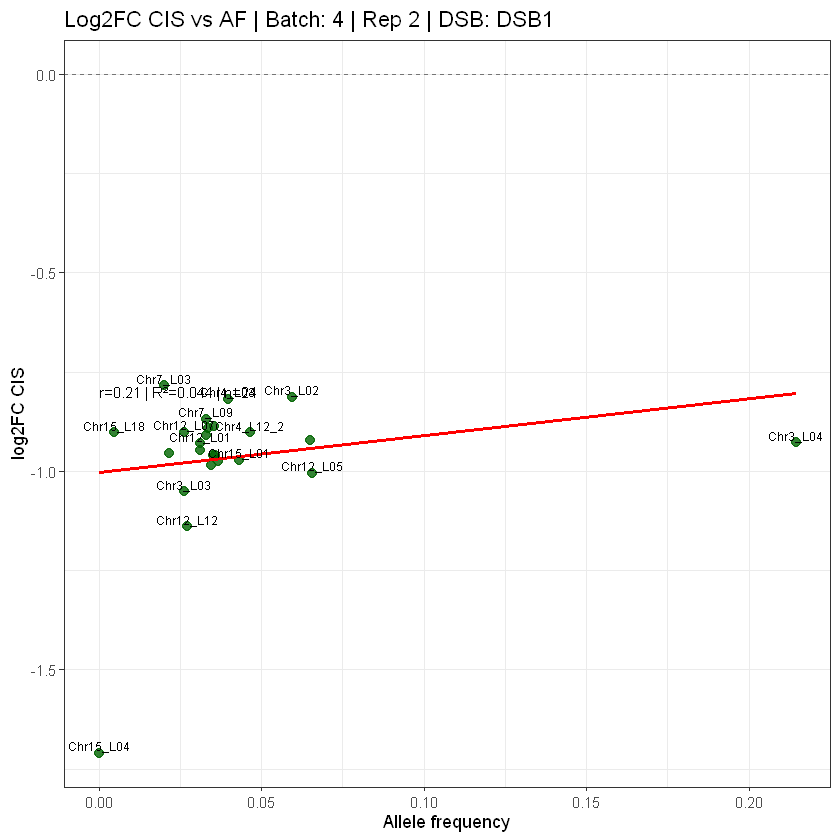

TRANS correlation stats (printed): r=0.366 | R²=0.134 | n=24 | Batch=4 | Rep 2 | DSB=TRANS



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 4     Rep 2     TRANS TRANS      24 0.366 0.134


`geom_smooth()` using formula = 'y ~ x'


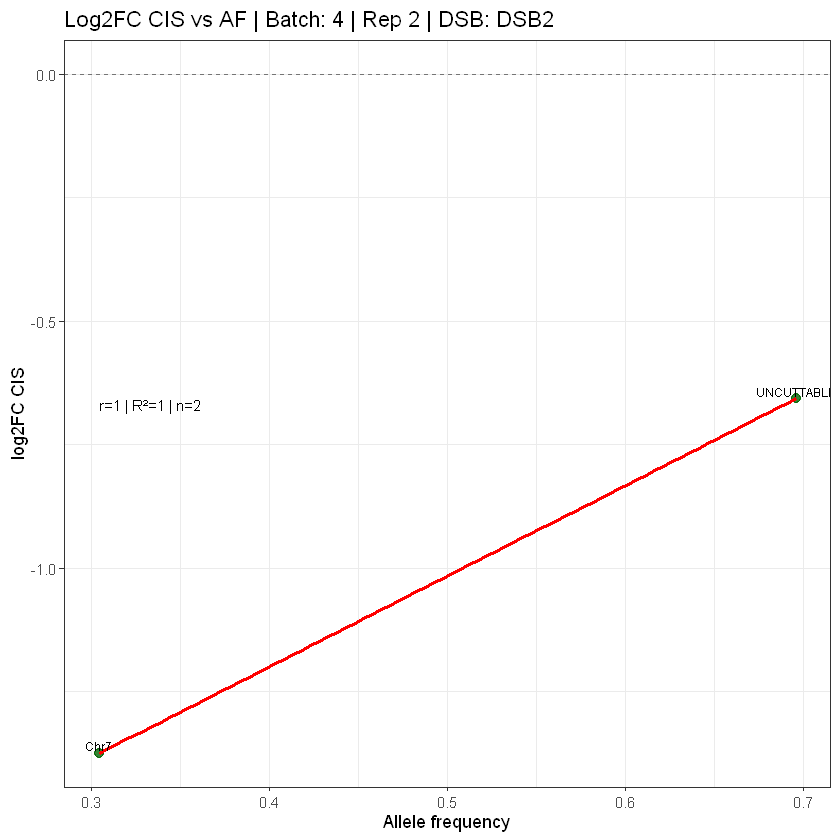

CIS correlation stats (printed): r=0.409 | R²=0.167 | n=24 | Batch=6 | Rep 1 | DSB=DSB1



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 6     Rep 1     DSB1  CIS        24 0.409 0.167


`geom_smooth()` using formula = 'y ~ x'


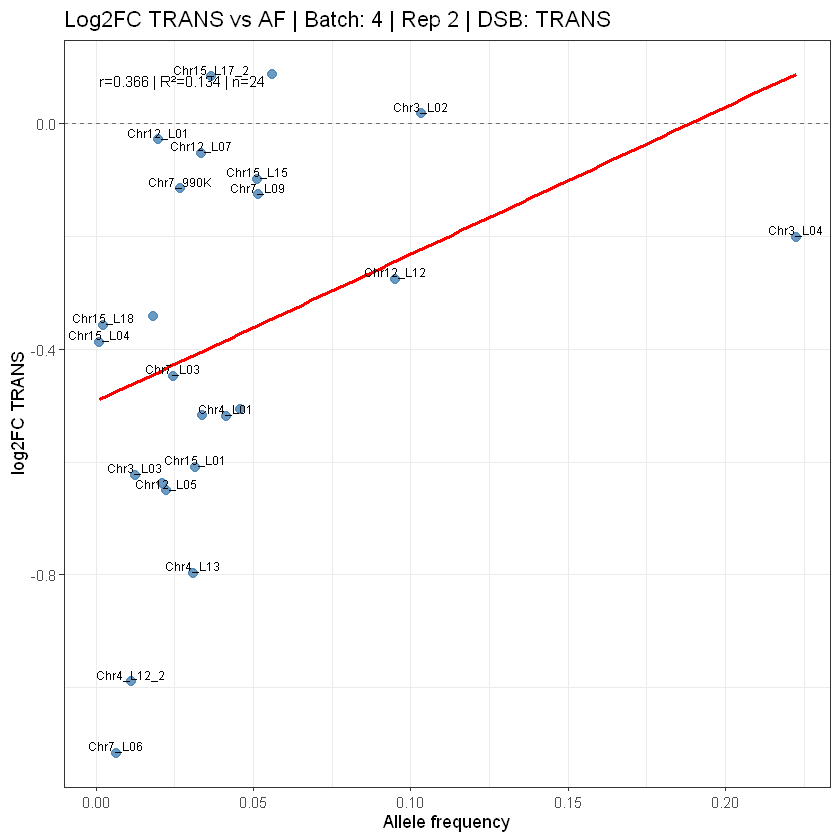

CIS correlation stats (printed): r=-1 | R²=1 | n=2 | Batch=6 | Rep 1 | DSB=DSB2



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 6     Rep 1     DSB2  CIS         2    -1     1


`geom_smooth()` using formula = 'y ~ x'


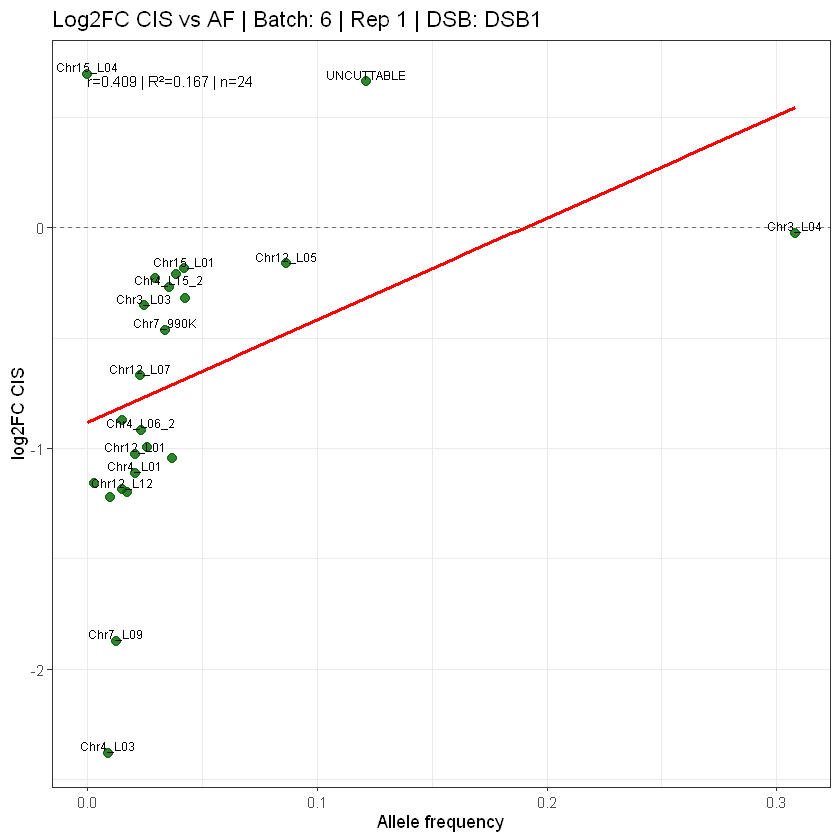

TRANS correlation stats (printed): r=0.485 | R²=0.235 | n=24 | Batch=6 | Rep 1 | DSB=TRANS



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 6     Rep 1     TRANS TRANS      24 0.485 0.235


`geom_smooth()` using formula = 'y ~ x'


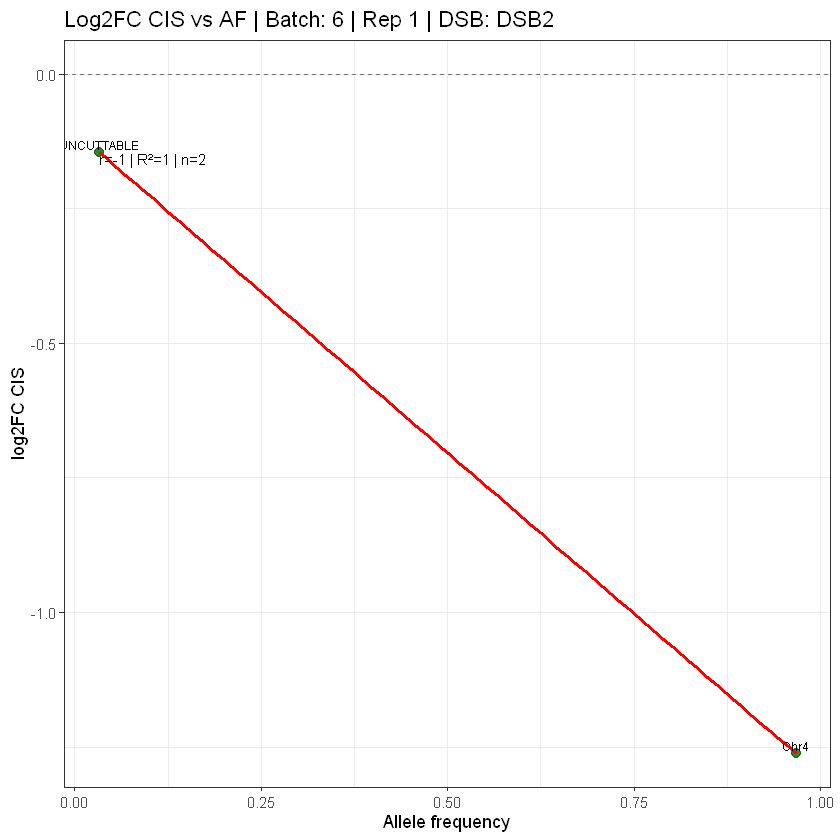

CIS correlation stats (printed): r=0.691 | R²=0.478 | n=24 | Batch=8 | Rep 1 | DSB=DSB1



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 8     Rep 1     DSB1  CIS        24 0.691 0.478


`geom_smooth()` using formula = 'y ~ x'


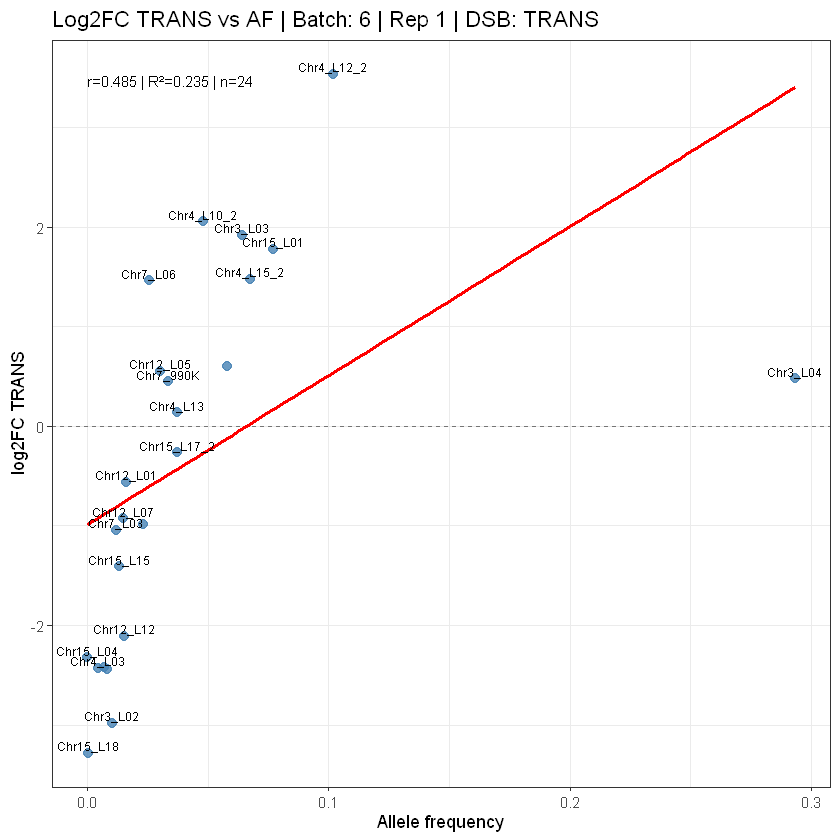

CIS correlation stats (printed): r=1 | R²=1 | n=2 | Batch=8 | Rep 1 | DSB=DSB2



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 8     Rep 1     DSB2  CIS         2     1     1


`geom_smooth()` using formula = 'y ~ x'


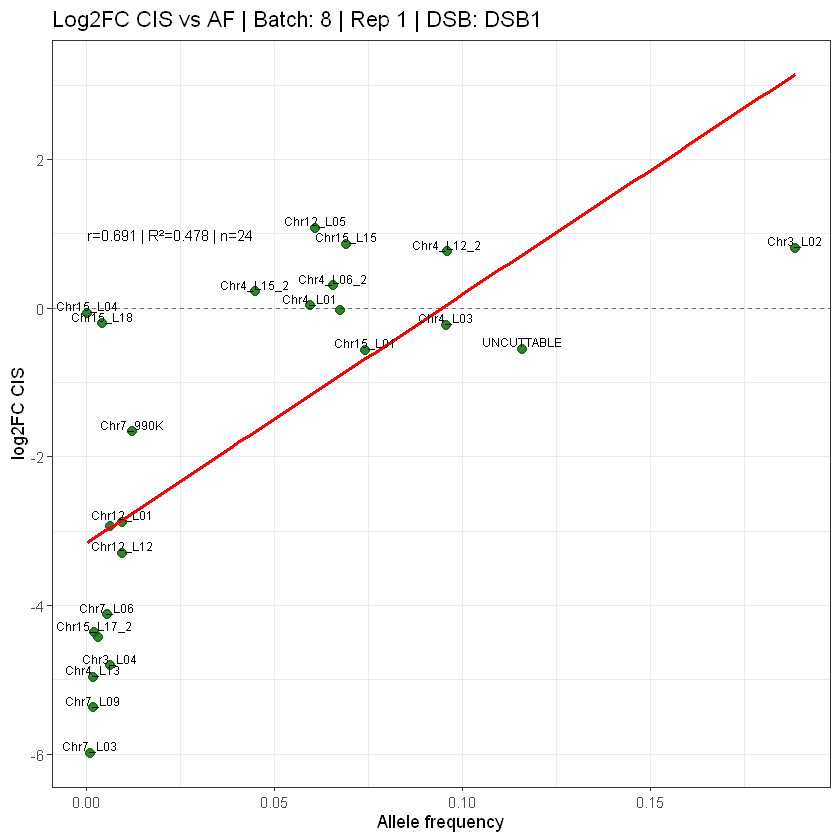

TRANS correlation stats (printed): r=0.612 | R²=0.374 | n=24 | Batch=8 | Rep 1 | DSB=TRANS



# A tibble: 1 × 7
  batch replicate DSB   panel n_pairs     r    r2
  <chr> <chr>     <chr> <chr>   <int> <dbl> <dbl>
1 8     Rep 1     TRANS TRANS      24 0.612 0.374


`geom_smooth()` using formula = 'y ~ x'


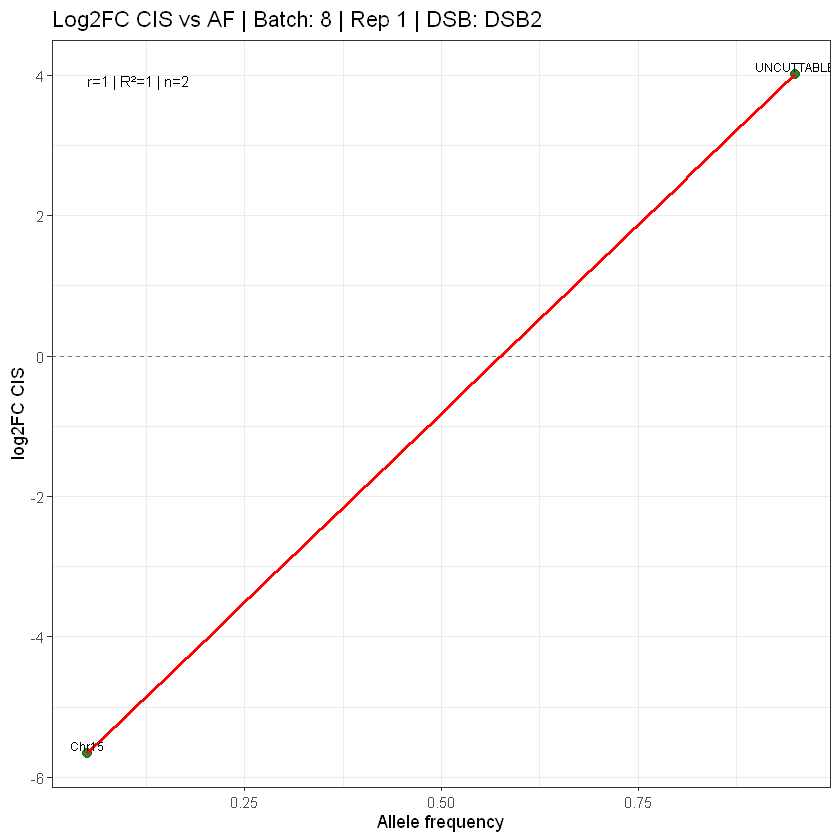

Locus heatmap correlation summary (printed): r=0.706 | R²=0.534 | n=420



# A tibble: 1 × 3
  n_pairs     r    r2
    <int> <dbl> <dbl>
1     420 0.706 0.534


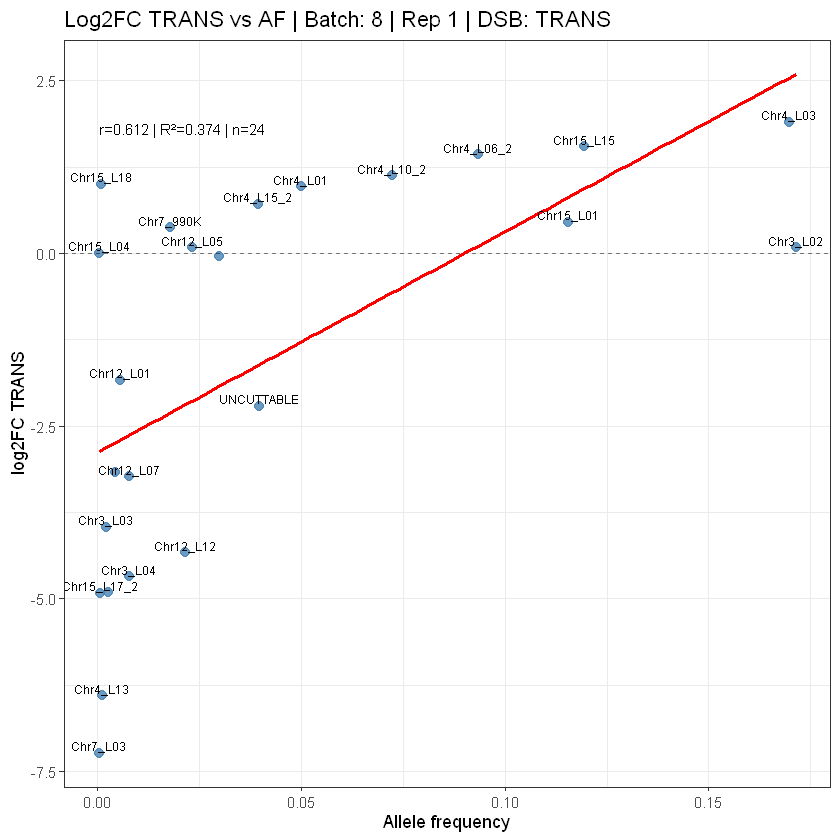

kNN correlation heatmap summary (printed): r=0.674 | R²=0.521 | n=420



# A tibble: 1 × 3
  n_pairs     r    r2
    <int> <dbl> <dbl>
1     420 0.674 0.521


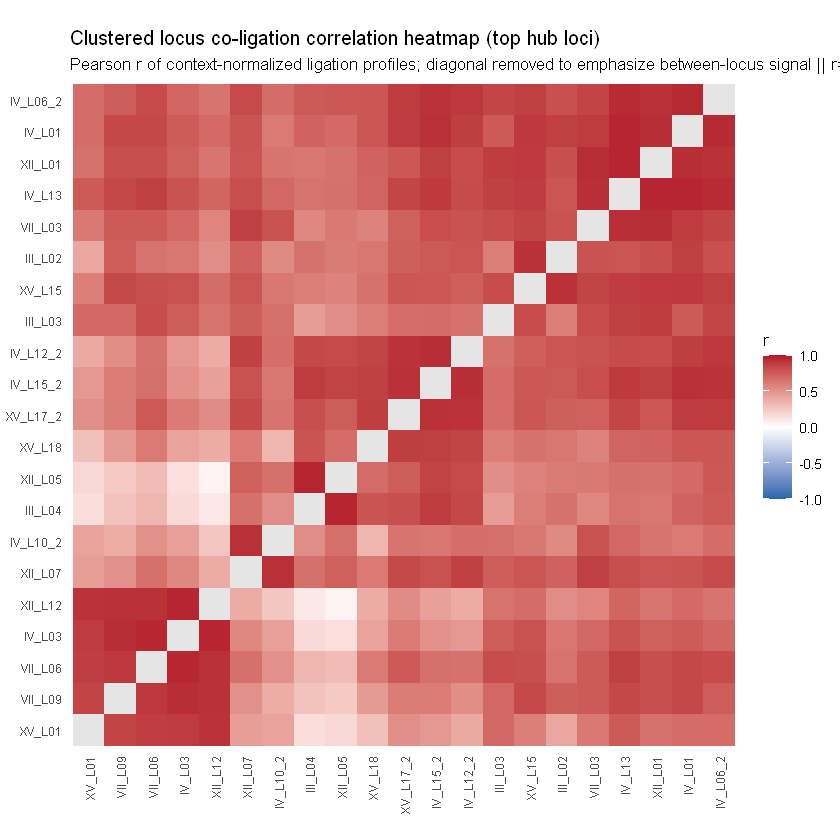

Allele-association heatmap summary (printed): r=0.23 | R²=0.226 | n=841



# A tibble: 1 × 3
  n_pairs     r    r2
    <int> <dbl> <dbl>
1     841 0.230 0.226


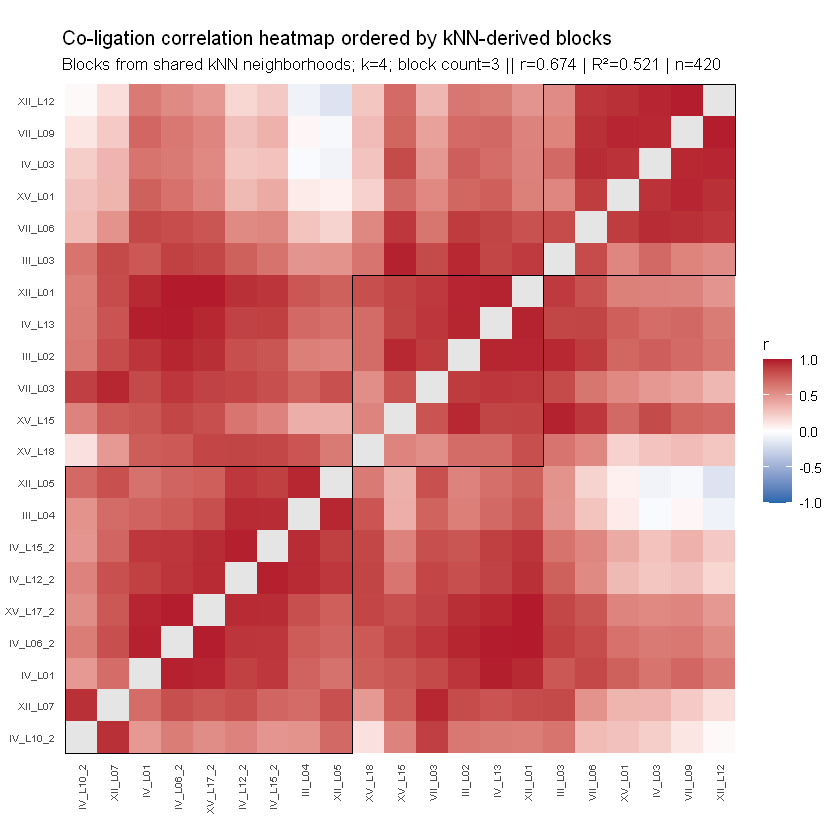

Correlation compliance pass complete: each available correlation plot now has r and R² shown and printed.



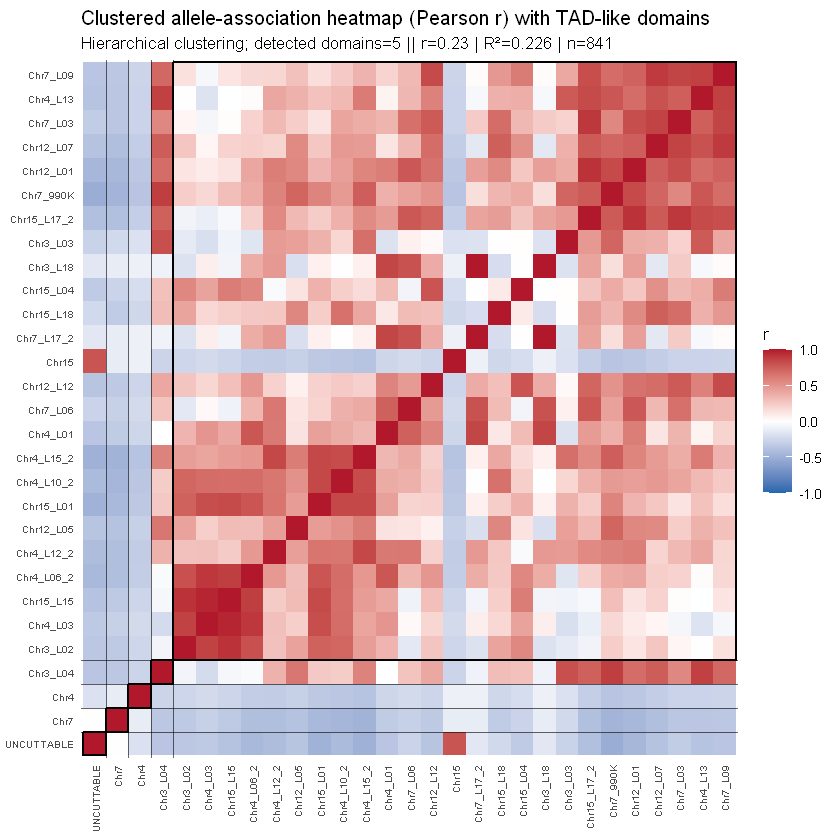

In [69]:
# ---- Correlation compliance enforcement: ensure EACH correlation plot shows r and R² and prints ----

offdiag_r_stats <- function(mat) {
  vals <- as.numeric(mat)
  vals <- vals[is.finite(vals)]
  tibble::tibble(
    n_pairs = length(vals),
    r = if (length(vals) > 0) mean(vals, na.rm = TRUE) else NA_real_,
    r2 = if (length(vals) > 0) mean(vals^2, na.rm = TRUE) else NA_real_
  )
}

fmt_r_pair <- function(r, r2, n_pairs) {
  paste0('r=', round(r, 3), ' | R²=', round(r2, 3), ' | n=', n_pairs)
}

append_subtitle_with_r <- function(p, txt) {
  old_sub <- p$labels$subtitle
  if (is.null(old_sub) || !nzchar(old_sub)) {
    p + labs(subtitle = txt)
  } else {
    p + labs(subtitle = paste0(old_sub, ' || ', txt))
  }
}

# 1) AF scatter correlations (batch-level and pooled): print tables and re-print plots
if (exists('cor_stats') && is.data.frame(cor_stats) && nrow(cor_stats) > 0) {
  message('AF correlation stats by batch/replicate/DSB/combo (printed):')
  print(cor_stats %>% dplyr::select(batch, replicate, DSB, combo, n_pairs, r, r2))
}

if (exists('cor_stats_overall') && is.data.frame(cor_stats_overall) && nrow(cor_stats_overall) > 0) {
  message('AF pooled correlation stats by DSB/combo (printed):')
  print(cor_stats_overall %>% dplyr::select(DSB, combo, n_pairs, r, r2))
}

if (exists('p_overall_af_corr') && !is.null(p_overall_af_corr)) print(p_overall_af_corr)
if (exists('p_overall_af_corr_loglog') && !is.null(p_overall_af_corr_loglog)) print(p_overall_af_corr_loglog)

# 2) Log2FC vs AF scatter correlations: enforce labels with BOTH r and R² + print stats per plot
if (exists('dat_fc_af') && is.data.frame(dat_fc_af) && nrow(dat_fc_af) > 0) {
  plot_keys_enforce <- dat_fc_af %>% dplyr::distinct(batch, replicate, DSB) %>% dplyr::arrange(batch, replicate, DSB)

  for (i in seq_len(nrow(plot_keys_enforce))) {
    b <- plot_keys_enforce$batch[[i]]
    rrep <- plot_keys_enforce$replicate[[i]]
    d <- plot_keys_enforce$DSB[[i]]

    dsub <- dat_fc_af %>%
      dplyr::filter(batch == b, replicate == rrep, DSB == d, is.finite(Allele_Frequency))

    # CIS scatter
    d_cis <- dsub %>% dplyr::filter(is.finite(log2FC_CIS))
    if (nrow(d_cis) >= 2) {
      r_cis <- suppressWarnings(stats::cor(d_cis$Allele_Frequency, d_cis$log2FC_CIS, method = 'pearson'))
      r2_cis <- r_cis^2
      ann_cis <- fmt_r_pair(r_cis, r2_cis, nrow(d_cis))

      p_cis <- ggplot(d_cis, aes(x = Allele_Frequency, y = log2FC_CIS)) +
        geom_point(size = 2.4, alpha = 0.8, color = 'darkgreen') +
        geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
        geom_smooth(method = 'lm', se = FALSE, color = 'red') +
        annotate(
          'text',
          x = min(d_cis$Allele_Frequency, na.rm = TRUE),
          y = max(d_cis$log2FC_CIS, na.rm = TRUE),
          label = ann_cis,
          hjust = 0,
          vjust = 1,
          size = 3.1
        ) +
        theme_bw(base_size = 11) +
        labs(
          title = paste0('Log2FC CIS vs AF | Batch: ', b, ' | ', rrep, ' | DSB: ', d),
          x = 'Allele frequency',
          y = 'log2FC CIS'
        )

      if (exists('has_ggrepel') && isTRUE(has_ggrepel)) {
        p_cis <- p_cis + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
      } else {
        p_cis <- p_cis + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
      }

      message('CIS correlation stats (printed): ', ann_cis, ' | Batch=', b, ' | ', rrep, ' | DSB=', d)
      print(tibble::tibble(batch = b, replicate = rrep, DSB = d, panel = 'CIS', n_pairs = nrow(d_cis), r = r_cis, r2 = r2_cis))
      print(p_cis)
    }

    # TRANS scatter
    d_trans <- dsub %>% dplyr::filter(is.finite(log2FC_TRANS))
    if (nrow(d_trans) >= 2) {
      r_trans <- suppressWarnings(stats::cor(d_trans$Allele_Frequency, d_trans$log2FC_TRANS, method = 'pearson'))
      r2_trans <- r_trans^2
      ann_trans <- fmt_r_pair(r_trans, r2_trans, nrow(d_trans))

      p_trans <- ggplot(d_trans, aes(x = Allele_Frequency, y = log2FC_TRANS)) +
        geom_point(size = 2.4, alpha = 0.8, color = 'steelblue') +
        geom_hline(yintercept = 0, linetype = 'dashed', alpha = 0.5) +
        geom_smooth(method = 'lm', se = FALSE, color = 'red') +
        annotate(
          'text',
          x = min(d_trans$Allele_Frequency, na.rm = TRUE),
          y = max(d_trans$log2FC_TRANS, na.rm = TRUE),
          label = ann_trans,
          hjust = 0,
          vjust = 1,
          size = 3.1
        ) +
        theme_bw(base_size = 11) +
        labs(
          title = paste0('Log2FC TRANS vs AF | Batch: ', b, ' | ', rrep, ' | DSB: ', d),
          x = 'Allele frequency',
          y = 'log2FC TRANS'
        )

      if (exists('has_ggrepel') && isTRUE(has_ggrepel)) {
        p_trans <- p_trans + ggrepel::geom_text_repel(aes(label = allele), size = 2.7, max.overlaps = 20)
      } else {
        p_trans <- p_trans + geom_text(aes(label = allele), size = 2.6, check_overlap = TRUE, vjust = -0.25)
      }

      message('TRANS correlation stats (printed): ', ann_trans, ' | Batch=', b, ' | ', rrep, ' | DSB=', d)
      print(tibble::tibble(batch = b, replicate = rrep, DSB = d, panel = 'TRANS', n_pairs = nrow(d_trans), r = r_trans, r2 = r2_trans))
      print(p_trans)
    }
  }
}

# 3) Heatmap/correlation-matrix plots: add printed r/R² summaries + reprint with subtitle append
if (exists('heat_mat_ord') && is.matrix(heat_mat_ord) && exists('p_locus_heatmap') && !is.null(p_locus_heatmap)) {
  st <- offdiag_r_stats(heat_mat_ord)
  txt <- fmt_r_pair(st$r, st$r2, st$n_pairs)
  message('Locus heatmap correlation summary (printed): ', txt)
  print(st)
  p_locus_heatmap <- append_subtitle_with_r(p_locus_heatmap, txt)
  print(p_locus_heatmap)
}

if (exists('delta_mat_ord') && is.matrix(delta_mat_ord) && exists('p_delta_heatmap') && !is.null(p_delta_heatmap)) {
  st <- offdiag_r_stats(delta_mat_ord)
  txt <- fmt_r_pair(st$r, st$r2, st$n_pairs)
  message('Delta heatmap correlation summary (printed): ', txt)
  print(st)
  p_delta_heatmap <- append_subtitle_with_r(p_delta_heatmap, txt)
  print(p_delta_heatmap)
}

if (exists('cor_ord') && is.matrix(cor_ord) && exists('p_knn_corr') && !is.null(p_knn_corr)) {
  st <- offdiag_r_stats(cor_ord)
  txt <- fmt_r_pair(st$r, st$r2, st$n_pairs)
  message('kNN correlation heatmap summary (printed): ', txt)
  print(st)
  p_knn_corr <- append_subtitle_with_r(p_knn_corr, txt)
  print(p_knn_corr)
}

if (exists('assoc_ord') && is.matrix(assoc_ord) && exists('p_allele_association_heatmap') && !is.null(p_allele_association_heatmap)) {
  st <- offdiag_r_stats(assoc_ord)
  txt <- fmt_r_pair(st$r, st$r2, st$n_pairs)
  message('Allele-association heatmap summary (printed): ', txt)
  print(st)
  p_allele_association_heatmap <- append_subtitle_with_r(p_allele_association_heatmap, txt)
  print(p_allele_association_heatmap)
}

message('Correlation compliance pass complete: each available correlation plot now has r and R² shown and printed.')